# Academic Stress Analysis — From Exploratory Analysis to Machine Learning

**Dataset:** Student Academic Stress (real-world survey) — 140 responses, 9 columns
**Target:** `Rate your academic stress index` (self-reported, 1–5)
**Source:** https://www.kaggle.com/datasets/poushal02/student-academic-stress-real-world-dataset

---

This notebook is organised in two parts.

**Part I — Exploratory Data Analysis (Sections 1–6)**
Control structures, functions and modules, data handling with pandas, visualisation, a Tkinter dashboard, and a critical appraisal. This establishes what the data contains and how the factors around academic stress relate to one another.

**Part II — Machine Learning Extension (Sections ML.1–ML.25)**
An end-to-end predictive modelling pipeline built on top of Part I: leakage-safe preprocessing, feature engineering, a regression problem and a classification problem, baselines, model comparison, hyperparameter tuning, explainability (permutation importance and SHAP), formal statistical testing, robustness checks, example predictions, and saved model artefacts.

| Part II section | Contents |
| --- | --- |
| ML.1 – ML.4 | Configuration, data loading, data-quality assessment, cleaning |
| ML.5 – ML.9 | EDA for modelling, feature engineering, leakage-safe split, preprocessing pipeline |
| ML.10 – ML.13 | Regression: baselines, model comparison, tuning, diagnostics |
| ML.14 – ML.17 | Classification: band definition, baselines, comparison, tuning, diagnostics |
| ML.18 – ML.20 | Explainability, statistical relationship analysis, robustness checks |
| ML.21 – ML.25 | Final evaluation, example predictions, model saving, key findings, limitations |

**How to run:** install the dependencies with `pip install -r requirements.txt`, then execute every cell from top to bottom on a fresh kernel. `xgboost` and `shap` are optional and are detected automatically, so the notebook still completes without them. Every path is resolved from the repository root, so the notebook runs correctly after a clone on any machine.

| Path | Role |
| --- | --- |
| `data/Academic Stress Dataset.csv` | Source data - read only, never modified |
| `models/` | Trained pipelines and metadata written by section ML.23 |
| `reports/figures/` | Key charts saved as PNG for reuse outside the notebook |

**Scope:** this is a predictive modelling and data analysis project. It models a self-reported stress rating and identifies statistical *associations*; it is not a clinical, diagnostic or screening instrument, and no causal claim is made anywhere in it.

## Introduction
****
**Student Academic Stress Real World Dataset:**

Students are worried about the academic stress due to variety of issues, such as peer pressure, academic pressure, competition and personal habits. Most of the elements are crucial for spotting trends that can lead to increase in stress levels and for suggesting practical solutions.

As a result, the main objective of the project is to understand and examine the dataset on academic stress that includes student answers regarding academic stage, peer pressure, home pressure, competition, copying mechanisms, and stress index. Using data analysis and visualization techniques, the goal is to investigate the connections between these features and pinpoint the main reason for academic stress.

Multiple sections inside this notebook focuses on a specific phase of the data analysis pipeline, from control structures to Data visualisation. Lastly, GUI development is also included. Link : https://www.kaggle.com/datasets/poushal02/student-academic-stress-real-world-dataset

# Section 1: Control Structures


## Importing the Dataset

### Implementation
The first step is to import the dataset which is achived using the pandas library in python. Pandas library is used in order to give the efficient tools for data reading and manipulation. So, the CSV dataset used to import contains various features related to academic stress. 

By reading the first 5 rows from the dataset, it helps in understanding the data stored in each column and also gives an overview of the student responses.

In [1]:
# Importing pandas Library
import pandas as pd
from pathlib import Path


def find_project_root():
    """Return the repository root, whatever directory the notebook is run from.

    The root is identified by the folders it contains rather than by a hard-coded
    path, so the notebook works after a clone on any machine or operating system.
    """
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root - run this notebook from inside the repository."
    )


PROJECT_ROOT = find_project_root()
DATA_FILE = PROJECT_ROOT / "data" / "Academic Stress Dataset.csv"

# Reading the CSV dataset
df = pd.read_csv(DATA_FILE)

# Understanding the dataset by printing the first 5 rows
df.head()


,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05,undergraduate,4.0,5.0,Noisy,Analyze the situation and handle it with intel...,No,3.0,5.0
1,24/07/2025 22:05,undergraduate,3.0,4.0,Peaceful,Analyze the situation and handle it with intel...,No,3.0,3.0
2,24/07/2025 22:06,undergraduate,1.0,1.0,Peaceful,"Social support (friends, family)",No,2.0,4.0
3,24/07/2025 22:06,undergraduate,3.0,2.0,Peaceful,Analyze the situation and handle it with intel...,No,4.0,3.0
4,24/07/2025 22:08,undergraduate,3.0,3.0,Peaceful,Analyze the situation and handle it with intel...,No,4.0,5.0


First 5 records in the dataset are displayed, which gives an idea regarding the type of data stored in each column. It is clear that there are multiple features in this dataset with the presence of both numerical and categorical data. As a result, dataset can be used for analysis and visualisation.

It is important to make sure the column names do not have any extra space because it can be a problem while calling them during further analysis. So, the 'str.strip()' method is applied to remove the unwanted extra spave from the column names. By doing this, it will keep the column names clean and we can proceed to the next step.

In [2]:
# Understanding the column names
print(df.columns)

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index '],
      dtype='object')


In [3]:
# Removing extra space in column names
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index'],
      dtype='object')


### Findings and Conclusion
Extra space in column names are eliminated. Example: 'Rate your academic stress index ' has some extra space at the end, so it is removed now.

Also, it is easy to understand the total number of rows and columns in the dataset using 'df.shape'.

In [4]:
# Printing the total number of rows and columns
print("Number of rows and columns:", df.shape)

Number of rows and columns: (140, 9)


So, the total number of rows are 140 and columns are 9.

## Renaming the Columns

### Implementation
Real dataset has column names which are very lengthy and very hard to use for analysing. So, renaming them is the best solution.

In [5]:
# Renaming the column names
df = df.rename(columns={
    "Your Academic Stage": "Academic Stage",
    "Academic pressure from your home": "Home Academic Pressure",
    "What coping strategy you use as a student?": "Coping Strategy",
    "Do you have any bad habits like smoking, drinking on a daily basis?": "Bad Habits",
    "What would you rate the academic  competition in your student life": "Academic Competition",
    "Rate your academic stress index": "Academic Stress Index"
})

By renaming the column names to just 2 or 3 words, it is easier to read and simplify for further data processing and analysis. 

Key benefits of renaming the columns are:

1. Improves **readibility** of the code
2. Improves code **maintainability**
3. **Best practice** for data analysis.

Finally, using the 'info()' function because it helps in understanding the data type for each feature.

In [6]:
# Getting an overview of dataset using info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               140 non-null    object 
 1   Academic Stage          140 non-null    object 
 2   Peer pressure           130 non-null    float64
 3   Home Academic Pressure  130 non-null    float64
 4   Study Environment       132 non-null    object 
 5   Coping Strategy         133 non-null    object 
 6   Bad Habits              140 non-null    object 
 7   Academic Competition    131 non-null    float64
 8   Academic Stress Index   129 non-null    float64
dtypes: float64(4), object(5)
memory usage: 10.0+ KB


### Findings and Conclusion
It is clear that there are 4 numerical columns becuase the data type for them is 'float64'. Also, the 'RangeIndex' represents that the total number of records are 140. 

Finally, the column names are cleaned and it is good to begin with the control structures for analysis. Further cleaning of the data inside the columns is handled in section 3 using pandas.

## High-Stress Analysis

### Implementation
The goal is to analyse the total number if students experience high stress. 'Academic Stress Index' includes numerically rated stress levels that students experience. 

Out of 5 rating, if any student has rated 4 or more, then it is considered as high. Each student's stress level is checked using an 'for' loop and the count of students with high stress is analysed. 

In [7]:
# Identifying students with high stress levels (stress index >= 4)
stress_level = df["Academic Stress Index"]

# Initialise high stress variable
high_stress = 0

# Checking stress value using for loop
for stress in stress_level:

    # Adding count only if stress is 4 or more
    if stress >= 4:
        high_stress += 1

# Printing the total number of students with high stress levels
print("Number of students with high stress levels:", high_stress)

Number of students with high stress levels: 80


### Findings and Conclusion
Output shows that the total number of students that have high stress levels is 80. This is a very high number and it is important to understand that most of the students need academic or psychological support.

## Peer Pressure Analysis

### Implementation
Peer pressure is analysed using the feature 'Peer pressure' in the dataset. Students are categorised into 2 major groups: High peer pressure and Low/moderate peer pressure. 

1. If any student has rated 4 or more, he/she is experiencing high peer pressure.
2. If any student has rated below 4, it means he/she is experiencing low/ Moderate peer pressure.

In [8]:
# Analysing impact of peer pressure among students
peer_pressure = df["Peer pressure"]

# Initialise the high and low peer pressure variables
high_peer_pressure = 0
low_peer_pressure = 0

# Checking the peer pressure using for loop
for each_student_pressure in peer_pressure:

    # Adding count only if high peer pressure is 4 or more
    if each_student_pressure >= 4:
        high_peer_pressure += 1
    else:
        low_peer_pressure += 1

# Printing the total count of peer pressure analysis
print("Students experiencing high peer pressure:", high_peer_pressure)
print("Students experiencing low/moderate peer pressure:", low_peer_pressure)

Students experiencing high peer pressure: 43
Students experiencing low/moderate peer pressure: 97


### Findings and Conclusion
Results show that the total number of students who experience high peer pressure is just 43, while 97 students are experiencing low or moderate peer pressure.

As a result, peer pressure may not be a contributing factor to academic stress. So, it is very important to further analyse stress levels in realtion to academic competition.

## Academic Competition vs Stress Analysis

### Implementation
Relationship between academic competition and stress is analysed in this section. 

Both the features 'Academic Competition' and 'Academic Stress Index' are measured on a numerical scale from 0 to 5.

1. If the value is 4 or above, it indicated high academic competition or high stress.
2. If the value is below 4, then it indicates low or moderate levels.

In [9]:
# Analyse academic competition vs stress
# Initialise both the variables 
high_competition_high_stress = 0
low_competition_low_stress = 0

# Uisng for loop to check the conditions for competition and stress
for index, row in df.iterrows():

    # Adding count only if academic competition and stress is 4 or more 
    if row["Academic Competition"] >= 4:
        if row["Academic Stress Index"] >= 4:
            high_competition_high_stress += 1
    else:
        if row["Academic Stress Index"] < 4:
            low_competition_low_stress += 1

# Printing the total number of students from the analysis made
print("High competition and High stress:", high_competition_high_stress)
print("Low competition and Low stress:", low_competition_low_stress)

High competition and High stress: 48
Low competition and Low stress: 32


### Findings and Conclusion
Output shows that total number of students with high competition and high stress are 48, while the number of students with low competition and low stress are 32.

In conclusion, the findings highlight academic competition as a a significant factor influencing student stress and justify further exploration in later sections of the analysis.

# Section 2: Functions and Modules


### Implementation
Importing the below libraries that will be used in this section. 

1. **Numpy** is used for performing numerical operations.
2. **Statistics** and **requests** are external python modules used for statistical analysis and potential integration.

In [10]:
import numpy as np                 # Numerical operations
import statistics                  # Statistical analysis
import requests                    # External API access

The required libraries are imported and ready to use.

Next most important step is to define the **global variables** from the dataset. The numerical features are stored in seperate variables in the form of lists.

1. '**peer_pressure_list**' is used to store the values of feature 'Peer pressure'
2. '**stress_list**' is used to store the values of feature 'Academic Stress Index'
3. '**competition_list**' is used to store the values of feature 'Academic Competition'
4. '**home_academic_pressure_list**' is used to store the values of feature 'Home Academic Pressure'

In [11]:
# Storing the values of numerical columns in seperate variables (Global variables)

peer_pressure_list = list(df["Peer pressure"])
stress_list = list(df["Academic Stress Index"])
competition_list = list(df["Academic Competition"])
home_academic_pressure_list = list(df["Home Academic Pressure"])

### Findings and Conclusion
The required libraries are imported and the numerical features are defined in the form of global variables, so that they can be used in all the functions. It avoids redefining the variables in each funtion.

## Categorizing Numerical Features into Low, Medium and High

### Implementation
In order to improve the interpretability of the numerical features, this funtion categorises them into low, Medium and High.

It is done to simplify the analysis, helps in comparision of groups, which makes patterns easier to understand when performing aggregation and visualisation in later section.

In [12]:
# Funtion to catergorize numerical features into Low, medium and High
def categorize_index(values, label):

    values_array = np.array(values)

    # Initialize the variables low, medium and high
    Low = 0
    Medium = 0
    High = 0

    # Initialize an empty array
    categories = []

    for value in values_array:

        # Missing ratings are left uncategorised rather than being forced into a
        # band: NaN fails every comparison below, so without this check it would
        # fall through to the final else and be counted as 'High'.
        if value != value:
            categories.append(None)

        # Appending 'Low', if value is less than 2
        elif value <= 2:
            categories.append("Low")
            Low += 1

        # Appending t'Medium', if values is equal to 3
        elif value == 3:
            categories.append("Medium")
            Medium += 1

        # Else, appending 'High'
        else:
            categories.append("High")
            High += 1

    return categories

In [13]:
# Home Academic Pressure Category
df["Home Academic Pressure Category"] = categorize_index(home_academic_pressure_list, "Home Academic Pressure")

# Peer Pressure Category
df["Peer Pressure Category"] = categorize_index(peer_pressure_list, "Peer pressure")

# Academic Stress Category
df["Academic Stress Category"] = categorize_index(stress_list, "Academic Stress Index")

# Academic Competition Category
df["Academic Competition Category"] = categorize_index(competition_list, "Academic Competition")

### Findings and Conclusion
The funtion successfully converted all 4 numerical features into 3 categories.

1. **Low**: values less than or equal to 2
2. **Medium**: value equal to 3
3. **High**: values greater than 3
4. **Missing**: left uncategorised (`None`) so that unanswered ratings are
   excluded from the grouped summaries below rather than silently inflating
   the 'High' group.

New categorical columns were created by applying this funtion. By using this approach, it demonstrates the effecctive use of funtions, arrays, and conditional logic to transform raw numerical data into categories.

In [14]:
df.head()

,Timestamp,Academic Stage,Peer pressure,Home Academic Pressure,Study Environment,Coping Strategy,Bad Habits,Academic Competition,Academic Stress Index,Home Academic Pressure Category,Peer Pressure Category,Academic Stress Category,Academic Competition Category
0,24/07/2025 22:05,undergraduate,4.0,5.0,Noisy,Analyze the situation and handle it with intel...,No,3.0,5.0,High,High,High,Medium
1,24/07/2025 22:05,undergraduate,3.0,4.0,Peaceful,Analyze the situation and handle it with intel...,No,3.0,3.0,High,Medium,Medium,Medium
2,24/07/2025 22:06,undergraduate,1.0,1.0,Peaceful,"Social support (friends, family)",No,2.0,4.0,Low,Low,High,Low
3,24/07/2025 22:06,undergraduate,3.0,2.0,Peaceful,Analyze the situation and handle it with intel...,No,4.0,3.0,Low,Medium,Medium,High
4,24/07/2025 22:08,undergraduate,3.0,3.0,Peaceful,Analyze the situation and handle it with intel...,No,4.0,5.0,Medium,Medium,High,High


## Statistics Summary of Numerical Features

### Implementation
Statistical summary of numerical features gives a basic descriptive calculation, such as mean, median and mode.The function also filters out the missing values and performs the statistical operation only on the non-mising values. By doing so, it ensures that the statistical results are accurate and not affected by missing values.

As a result, statistical summaries help in understanding the central tendency and distribution of stress-realted variables among students.The funtion computes 3 key statistical measures:

1. **Mean**: It gives the average of the feature.
2. **Median**: Indicates the central value and prevents the impact of any outliers.
3. **Mode**: Most commonly occuring value.

By filtering the data before performing the statistical operations, it ensures that missing values do not distort the results. Same funtion is being used for all the numerical features to get the values for mean, median and mode.

In [15]:
# Funtuon to calculate the statistical summary of numerical features
def statistics_of_numerical_features(values, label):

    # Initialize an empty array to store cleaned values
    cleaned_values = []

    # Keeping only non-NaN values
    for val in values:
        if val != '' and val == val:
            cleaned_values.append(val)

    # Calculating the statistical summary        
    mean = round(statistics.mean(cleaned_values), 2)
    median = round(statistics.median(cleaned_values), 2)
    mode = statistics.mode(cleaned_values)

    # Printing the mean, median and mode values
    print(label, "Statstical Summary\n")
    print("Mean :", mean)
    print("Median :", median)
    print("Mode :", mode)
    print()


In [16]:
# Reusing the same funtion for all numerical columns
statistics_of_numerical_features(home_academic_pressure_list, "Home Academic Pressure")
statistics_of_numerical_features(peer_pressure_list, "Peer pressure")
statistics_of_numerical_features(stress_list, "Academic Stress Index")
statistics_of_numerical_features(competition_list, "Academic Competition")

Home Academic Pressure Statstical Summary

Mean : 3.17
Median : 3.0
Mode : 3.0

Peer pressure Statstical Summary

Mean : 3.09
Median : 3.0
Mode : 3.0

Academic Stress Index Statstical Summary

Mean : 3.71
Median : 4.0
Mode : 4.0

Academic Competition Statstical Summary

Mean : 3.46
Median : 4.0
Mode : 4.0



### Findings and Conclusion
The below predictions from the statistical summary for the numerical features:

1. Home Academic Pressure : Moderate level of mean and median but mode of 3 suggests that most students experience a medium level of pressure rather than extreme pressure.
2. Peer Pressure : Moderate overall, with the majority of students experience peer pressure on average. It is not overwhelmingly high for most students.
3. Academic stress Index : It shows higher stress level compared to other factors. Both median and mode being 4 indicate that many students experience high academic stress, which is a significant concern.
4. Academic Competition : It is perceived as high by most of the students, as reflected by the median and mode values. So, it is clear that strong competitive academic environment, may contribute to elevated stress levels.

## Analysis of Study Environment

### Implementation

In [17]:
df["Study Environment"].unique()

array(['Noisy', 'Peaceful', 'disrupted', nan], dtype=object)

Understanding the student environment to know how different learning surroundings may influence academic stress. The funtion processes categorical data related to students study environment and gives the total number of students that fall into each of the below category:
1. Disrupted
2. Noisy
3. Peaceful

In [18]:
# Funtion to analyse the Study Environment
def analyze_study_environment(study_environment):
    
    # Initialize counters
    disrupted = 0
    noisy = 0
    peaceful = 0

    # Count each category
    for value in study_environment:

        # Study Environment is disrupted
        if value == "disrupted":
            disrupted += 1

        # Study Environment is Noisy
        elif value == "Noisy":
            noisy += 1

        # Study Environment is Peaceful
        elif value == "Peaceful":
            peaceful += 1

    # Display results for study environment 
    print("Study Environment Summary\n")
    print("Disrupted:", disrupted)
    print("Noisy:", noisy)
    print("Peaceful:", peaceful)


In [19]:
# Funtion call for study environment summary
study_environment = list(df["Study Environment"])
analyze_study_environment(study_environment)

Study Environment Summary

Disrupted: 34
Noisy: 32
Peaceful: 66


### Findings and Conclusion
Most of the students experience peaceful environment with an highest number of 66, while students having disrupted and noisy environment of 34 and 32 respectively.

Distribution of these environment helps identify whether external factors beyound academics may be leading to stress among students. Higher number of disrupted environemnt indicate the need for institutional support, such as access to libraries for quite study environment.

## Analysis of Coping Strategy

### Implementation
This section analyses the copying strategies used by students to manage academic stress. Copying mechanisms play a vital role in determining how students respons pressure and challenging academic situations.

Function **'analyze_coping_strategy()'** defines a list of copying strategies and counts the total number of students using each major approach:

1. Intellectual handling
2. Emotional breakdown
3. Social support

Basic counting approach is used to keep the code clean and easy to read.

In [20]:
# Funtion for Copying Strategy analysis
def analyze_coping_strategy(coping_strategy_list):

    # Initialize the variables
    intellect = 0
    emotional = 0
    social = 0
    blank = 0

    for value in coping_strategy_list:

        # Adding count based on the value in copying strategy
        if value == "Analyze the situation and handle it with intellect":
            intellect += 1
        elif value == "Emotional breakdown (crying a lot)":
            emotional += 1
        elif value == "Social support (friends, family)":
            social += 1

    # Printing the copying strategy summary
    print("Coping Strategy Summary\n")
    print("Intellectual Handling:", intellect)
    print("Emotional Breakdown:", emotional)
    print("Social Support:", social)

In [21]:
# Funtion call for Copying strategy
coping_strategy_list = list(df["Coping Strategy"])
analyze_coping_strategy(coping_strategy_list)

Coping Strategy Summary

Intellectual Handling: 80
Emotional Breakdown: 32
Social Support: 21


### Findings and Conclusion
A majority of students prefer analysing the situation logically and handling stress using intellect. Many students adopt a problem-solving mindset when facing academic challenges. Around 32 students experience crying and emotional breakdown, while 21 students rely on friends or family for support. 

Overall, the results show that most students attempt to manage stress intellectually, a considerable amount of students still require emotional or social support.

## External API Connectivity Check

### Implementation
The purpose of thus funtion us to demonstrate of the use of an external module ('requests') to interact with web-based API. An HTTP GET request is sent to a public test API endpoint, which is used for testing. The result is HTTP status code of the response.

In [22]:
# Funtion for API External API connectivity check
def check_http_resource():

    # JSON place holder URL
    url = "https://jsonplaceholder.typicode.com/posts/1"

    # A network failure is reported rather than raised, so that the notebook
    # still runs from top to bottom on a machine without internet access.
    try:
        response = requests.get(url, timeout=10)

        # Returning the status code
        return response.status_code
    except requests.exceptions.RequestException as error:
        return f"unavailable ({type(error).__name__})"

external_api = check_http_resource()

# Printing the HTTP status code
print("External resource status code:", external_api)


External resource status code: 200


### Findings and Conclusion
The function successfully returend the HTTP status code of the external API request. Status code of '200' indicates the external resource is accessible and the request was processed successfully.

# Section 3: Data Handling with Pandas


## Understanding Empty values in the dataset

### Implementation
Understanding the total number of Nan values in dataset using 'isna().sum()'. 

In [23]:
# Understanding the total number of missing values
df.isna().sum()

Timestamp                           0
Academic Stage                      0
Peer pressure                      10
Home Academic Pressure             10
Study Environment                   8
Coping Strategy                     7
Bad Habits                          0
Academic Competition                9
Academic Stress Index              11
Home Academic Pressure Category    10
Peer Pressure Category             10
Academic Stress Category           11
Academic Competition Category       9
dtype: int64

### Findings and Conclusion
It can be seen that there are few empty values in the dataset which need to be dealt using appropriate approach.

## Handling Empty values in Numerical columns (Median Imputation)

### Implementation
Real-world datasets usually contain missing values, which can negatively impact statistical analysis and performance of the model. So, median imputation is performed for numerical columns.

**Median is chosen because it is more robust to outliers and provides more appropriate measure  for ordinal variables**. It is done to ensure data consistency and to avoid errors during further analysis.

The following numerical columns are cleaned:

1. Home Academic Pressure
2. Peer pressure
3. Academic Stress Index
4. Academic Competition




In [24]:
# Median Imputation for 'Home Academic Pressure' feature
df["Home Academic Pressure"] = df["Home Academic Pressure"].fillna(df["Home Academic Pressure"].median())

# Median Imputation for 'Peer pressure' feature
df["Peer pressure"] = df["Peer pressure"].fillna(df["Peer pressure"].median())

# Median Imputation for 'Academic Stress Index' feature
df["Academic Stress Index"] = df["Academic Stress Index"].fillna(df["Academic Stress Index"].median())

# Median Imputation for 'Academic Competition' feature
df["Academic Competition"] = df["Academic Competition"].fillna(df["Academic Competition"].median())

### Findings and Conclusion
All missing values in the numerical features are successfully replaced with their median values. As a result, the dataset no longer contains empty (Nan) values in these columns. It will help in performing the statistical computations and comparisions more reliably.

## Handling Empty values in Categorical columns (Mode Imputation)

### Implementation
Categorical columns also have missing values, since it is not possible to calculate median for texts, mode imputation is performed to handle missing entries in the dataset.

The following categorical columns had missing values so they were cleaned:
1. Study Environment
2. Copying Strategy

Finally, the dataset is checked to confirm that no missing values are left using 'isna().sum()'

In [25]:
# Mode Imputation for 'Study Environment' feature
df["Study Environment"] = df["Study Environment"].fillna(df["Study Environment"].mode()[0])

# Mode Imputation for 'Copying Strategy' feature
df["Coping Strategy"] = df["Coping Strategy"].fillna(df["Coping Strategy"].mode()[0])

In [26]:
# Making sure there are no Nan values
print("The List off Nan values in the dataset are as follows: \n\n", df.isna().sum())

The List off Nan values in the dataset are as follows: 

 Timestamp                           0
Academic Stage                      0
Peer pressure                       0
Home Academic Pressure              0
Study Environment                   0
Coping Strategy                     0
Bad Habits                          0
Academic Competition                0
Academic Stress Index               0
Home Academic Pressure Category    10
Peer Pressure Category             10
Academic Stress Category           11
Academic Competition Category       9
dtype: int64


### Findings and Conclusion
In conclusion, all missing values in the original survey columns have been handled.

The derived `... Category` columns created in Section 2 still show a small number of empty values. That is deliberate: those categories were built from the raw ratings *before* imputation, and an unanswered rating is left uncategorised rather than being assigned to a band it was never given. Those rows are simply excluded from the grouped summaries that follow, which is the correct behaviour - assigning them a band would invent a response.

In order to check weather duplicated records are present, using 'duplicated.sum()' to check.

In [27]:
# Checking for duplicated records, if any.
print("The total number of duplicated records in the dataset are : ", df.duplicated().sum())

The total number of duplicated records in the dataset are :  0


Since, there are no duplicated records in the dataset, it is good to proceed with further analysis.

## Filtering the Data and Driving Insights

### Analysis of Academic Stress Based on Study Environment
#### Implementation

Grouping by 'Student Environment' and calculating the mean of stress values.

In [28]:
# Group by 'Study Environment'
groupedStudentEnv = df.groupby("Study Environment")

# Calculate mean of stress
stressEnv = groupedStudentEnv["Academic Stress Index"].mean()

# Printing the stress mean
print("Student stress levels based on Environment: \n\n", stressEnv.round(2))

Student stress levels based on Environment: 

 Study Environment
Noisy        3.84
Peaceful     3.54
disrupted    4.03
Name: Academic Stress Index, dtype: float64


#### Findings and Conclusion
Students studying in a disrupted environment experience the highest average stress levels, indicating that frequent interruptions and lack of focus significantly increase academic stress.

Results show that the quality of a student's study environment plays a very important role in impacting stress levels of students. Creating a distraction-free study space is an effective strategy for reduing stress and improving academic well-being.

### Academic Stage vs Academic Stress
#### Implementation
Grouping by 'Academic Stage' and calcualting the mean of academic stress.

In [29]:
# Group by 'Academic Stage'
groupedAcademic = df.groupby("Academic Stage")

# Calculate mean of stress
stressAcademic = groupedAcademic["Academic Stress Index"].mean()

# Printing the stress mean
print("Student stress levels based on Academic Stage: \n\n", stressAcademic.round(2))

Student stress levels based on Academic Stage: 

 Academic Stage
high school      3.86
post-graduate    3.73
undergraduate    3.69
Name: Academic Stress Index, dtype: float64


#### Findings and Conclusion
The analysis examines how average academic stress levels vary across various other academuc stages such as high school, post-graduation and undergraduation. High school students experience the highest average stress level (3.86) among all academic stages. Post-graduation students show moderately high stress levels (3.73), while Undergraduation students report the lowest average stress of about 3.69.

Results suggest that academic stress tends to be higher during earlier academic stages, particularly in high school. So, it is important to provide early academic and emotional support to students before they move to higher studies.

### Academic Stage vs Study Environment (Combined Stress Analysis)
#### Implementation
This combined stress analysis shows how academic stress varies when both 'Academic Stage' and 'Study Environment' are considered together.

In [30]:
# Group by 'Academic Stage' and 'Study Environment'
groupedData = df.groupby(["Academic Stage","Study Environment"])

# Calculate mean of stress
average_stress = groupedData["Academic Stress Index"].mean()

# Printing the stress mean
print("Average Stress level for each Academic Stage within different Study Environment:\n")
print(average_stress.round(2))

Average Stress level for each Academic Stage within different Study Environment:

Academic Stage  Study Environment
high school     Noisy                4.00
                Peaceful             3.57
                disrupted            4.67
post-graduate   Noisy                3.50
                Peaceful             3.50
                disrupted            4.33
undergraduate   Noisy                3.78
                Peaceful             3.54
                disrupted            3.93
Name: Academic Stress Index, dtype: float64


#### Findings and Conclusion
**Disrupted study environments** consistently show the highest stress levels compared to all the stages. Highest overall stress is seen for high school students (4.67), while the lowest is seen for undergraduate students (3.93). Post-graduate students experience relatively low compared to undergraduate students (4.33).

**Noisy environments** shows moderate stress levels. High school students depicts relatively higher stress (4.00) compared to other stages. In Noisy settings, undergraduate students experience slightly higher stress than post-graduate students.

**Peaceful environment** are associated with the lowest stress levels across all academic stages. Stress levels remain consistently lower for high school (3.57), undergraduate (3.54), and post-graduate students (3.50).

Finally, from this analysis we can conclude that study environment have an impact on academic stress. Across all the academic stages, disrupted environment often leads to higher stress, on the other hand, peaceful environment helps in reducing stress.

### Bad Habits vs Academic Stage
#### Implementation
This combined stress analysis shows how academic stress varies when both 'Bad Habits' and 'Academic Stage' are considered together.

In [31]:
# Group by 'Bad Habits' and 'Academic Stage' 
groupedHabits = df.groupby(["Bad Habits","Academic Stage"])

# Calculate mean of stress
avg_stress = groupedHabits["Academic Stress Index"].mean()

# Printing the stress mean
print("Average Stress level among students with bad habits across academic stages.:\n")
print(avg_stress.round(2))

Average Stress level among students with bad habits across academic stages.:

Bad Habits         Academic Stage
No                 high school       3.86
                   post-graduate     3.67
                   undergraduate     3.65
Yes                post-graduate     4.00
                   undergraduate     4.33
prefer not to say  post-graduate     4.00
                   undergraduate     3.33
Name: Academic Stress Index, dtype: float64


#### Findings and Conclusion
**Students who do not have bad habits report lower stress levels** in all the academic stages. High school students without bad habits show avergare stress level of about 3.86, while post-graduate and undergraduate students without bad habits report lower stress levels of 3.67 and 3.65 respectively.

**Students who have bad habits experience higher stress levels**. Post-graduate students eith bad habits report average stress level of 4.00, while undergraduate students show highest stress level overall.

**Students who prefer not to disclose their habits also display elevated stress**. Post-graduate students in this category show stress level of 4.00, while undergraduate students report a lower stress level of 3.33.

In conclusion, relationship between bad habits and increased academic stress is clearly analysed, particularly among undergraduate and post-graduate students. Promoting healthier lifestyle choices and stress-coping mechanisms could play an important role in reducing academic stress levels across higher education stages.

### Academic Stage vs Academic Competition Category
#### Implementation
This combined stress analysis shows how academic stress varies when both 'Academic Stage' and 'Academic Competition Category' are considered together.

In [32]:
# Group by 'Academic Stage' and 'Academic Competition Category'
stageComp = df.groupby(["Academic Stage", "Academic Competition Category"])

# Calculate mean of stress
stress_lvl = stageComp["Academic Stress Index"].mean()

# Printing the stress mean
print("The stress level among students at different academic stage and competition category: \n\n", stress_lvl.round(2))

The stress level among students at different academic stage and competition category: 

 Academic Stage  Academic Competition Category
high school     High                             4.08
                Low                              2.67
                Medium                           3.92
post-graduate   High                             4.00
                Low                              4.00
                Medium                           3.00
undergraduate   High                             3.96
                Low                              2.50
                Medium                           3.72
Name: Academic Stress Index, dtype: float64


#### Findings and Conclusion
**High academic competition** is strongly associated with **higher stress levels** across all academic stages. High school students under high competition report an average stress level of 4.08. Undergraduate students under high competition show similarly high stress levels at 3.96. Post-graduate students also experience elevated stress under high competition, with a value of 4.00.

**Low competition environments** generally correspond to **lower stress levels**, particularly for high school and undergraduate students. High school students under low competition report a significantly lower stress level of 2.67. Undergraduate students under low competition show the **lowest stress level overall** at 2.50.

An exception is observed among **post-graduate students**, where students in the low competition category still report a relatively high stress level of 4.00. This suggests that factors beyond competition—such as research pressure, career uncertainty, or workload—may influence stress at the post-graduate level.

**Medium competition** consistently results in **moderate stress levels** across all stages. Stress values remain between 3.00 and 3.92, indicating manageable but noticeable pressure.

In conclusion, this analysis highlights a strong relationship between **academic competition and student stress**, especially at the high school and undergraduate levels. While reducing competitive pressure may help lower stress for early-stage students, additional support mechanisms may be required for post-graduate students to address stress arising from non-competitive academic challenges.

# Section 4: Data Visualization


## Importing required Libraries

In [33]:
# Importing matplotlib and seaborn libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Academic Stress Distribution
### Implementation

The histogram below illustrates the **distribution of the Academic Stress Index** among students, with stress levels ranging from **1 (very low)** to **5 (very high)**.

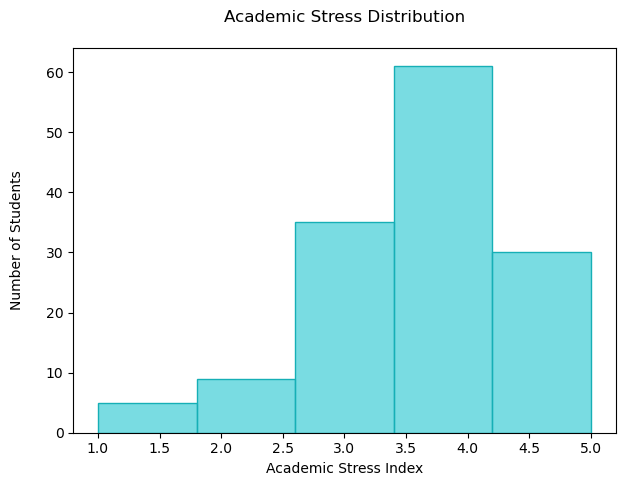

In [34]:
# Histogram Plot for academic stress distribution
plt.figure(figsize=(7,5))

sns.histplot(df["Academic Stress Index"], bins = 5, color = "#4cd1d9", edgecolor = "#16afb6")
plt.title("Academic Stress Distribution\n")
plt.xlabel("Academic Stress Index")
plt.ylabel("Number of Students\n")
plt.show()

### Findings and Conclusion
The majority of students fall within the **moderate to high stress range (3–4)**. It indicates that most students experience noticeable academic pressure rather than extreme calm or extreme stress.
  
A **peak is observed around stress levels 3.5–4**, suggesting that high stress is common across the student population. It aligns with earlier findings related to academic competition, peer pressure, and study environment.

**Very low stress levels (1–2)** are relatively rare. It suggests that few students experience minimal academic pressure, possibly due to workload, competition, or performance expectations.

**High stress values (4–5)** are also significantly present. It highlights a potential concern for student well-being and the need for stress management or institutional support mechanisms.

In conclusion, the histogram provides a clear visual confirmation that **academic stress is not evenly distributed**, with most students experiencing moderate to high stress. So, the insights justify further exploratory and statistical analysis carried out in later sections of this project.

## Stress Levels based on multiple features (bar graphs)
### Implementation
1. Bad Habits Across Academic Stages 
2. Academic Stage and Competition Category
   
The bar chart on the left illustrates the **average Academic Stress Index** among students with different responses to bad habits (Yes, No, Prefer not to say) across academic stages. The bar chart on the right presents the **average Academic Stress Index** across different academic stages under varying levels of academic competition (Low, Medium, High).

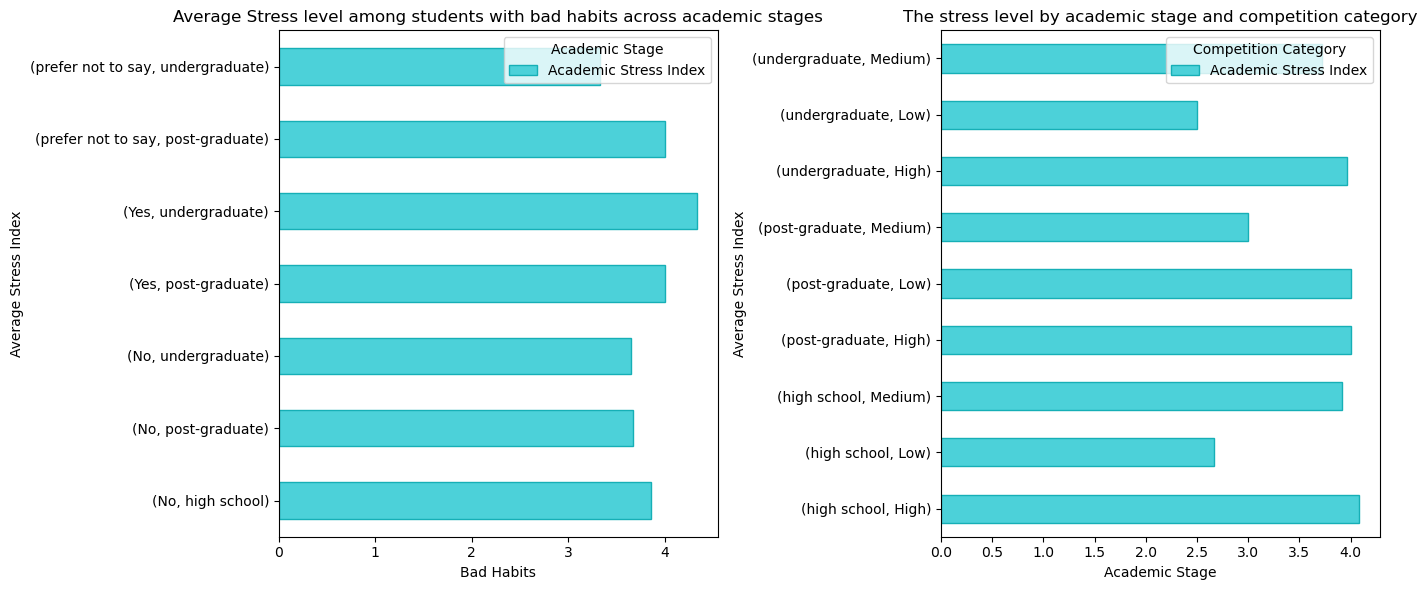

In [35]:
# Create subplots for bar graphs charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
# Bar Graph for Average Stress level among students with bad habits across academic stages
avg_stress.plot(kind = "barh", stacked = True, color = "#4cd1d9", edgecolor = "#16afb6", ax = axes[0])
axes[0].set_title("Average Stress level among students with bad habits across academic stages")
axes[0].set_xlabel("Bad Habits")
axes[0].set_ylabel("Average Stress Index")
axes[0].legend(title="Academic Stage")

# Bar Graph for The stress level by academic stage and competition category
stress_lvl.plot(kind = "barh", stacked = True,color = "#4cd1d9", edgecolor = "#16afb6", ax = axes[1])
axes[1].set_title("The stress level by academic stage and competition category")
axes[1].set_xlabel("Academic Stage")
axes[1].set_ylabel("Average Stress Index")
axes[1].legend(title="Competition Category")

# Setting tight Layout to fit both the pie charts in the frame
plt.tight_layout()
plt.show()

### Findings and Conclusion
Below are observations from the graph for Bad Habits Across Academic Stages:

1. Students who **reported having bad habits** consistently show **higher stress levels** compared to those who reported not having bad habits. Undergraduate students with bad habits exhibit the **highest stress level**, indicating greater vulnerability at this academic stage.
2. Students who **do not have bad habits** demonstrate relatively **lower and more stable stress levels**, particularly at the undergraduate and post-graduate levels.
3. Students who chose **“prefer not to say”** display mixed stress levels. it's variability may indicate underlying behavioural or lifestyle factors that were not explicitly disclosed but still influence academic stress.

Below are observations from the graph for Academic Stage and Competition Category:

1. Across all academic stages, students experiencing **high academic competition** report the **highest stress levels**. High school and undergraduate students under high competition show particularly elevated stress scores.
2. Students in **low competition environments** consistently experience **lower stress levels**, regardless of academic stage. It suggests that reduced competitive pressure plays a significant role in stress mitigation.
3. Medium competition levels result in **moderate stress values**, positioning competition intensity as a key stress determinant.

In conclusion, both visualisations collectively indicate that **academic stress is influenced by behavioural factors (bad habits) and environmental pressures (academic competition)**. Students exposed to high competition or engaging in unhealthy habits tend to experience significantly higher stress levels, emphasising the importance of supportive academic structures and healthy coping mechanisms.

## Relationship Between Peer Pressure and Academic Stress
### Implementation
The scatter plot illustrates the relationship between **Peer Pressure Level** and the **Academic Stress Index** among students.

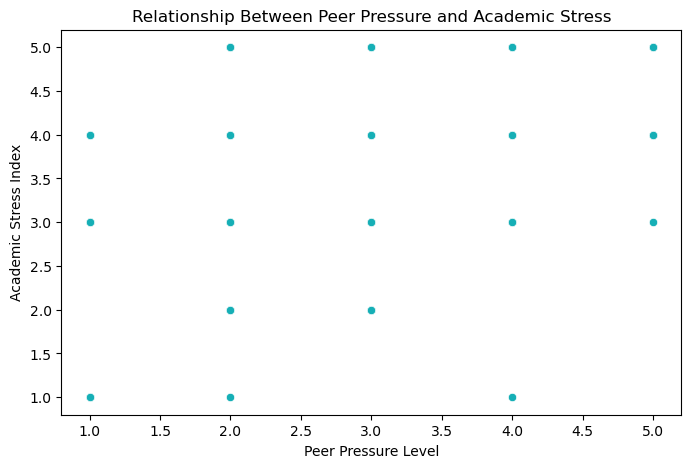

In [36]:
# Scatter plot to visualize the relationship between peer pressure and academic stress
plt.figure(figsize=(8,5))
sns.scatterplot(x = "Peer pressure", y = "Academic Stress Index", data = df, color = "#16afb6")
plt.title("Relationship Between Peer Pressure and Academic Stress")
plt.xlabel("Peer Pressure Level")
plt.ylabel("Academic Stress Index")
plt.show()

### Findings and Conclusion
A **general upward trend** can be observed in the distribution of points, indicating that **higher peer pressure levels are associated with higher academic stress**.

At **lower peer pressure levels (1–2)**, academic stress values are more widely distributed, ranging from low to moderate stress levels. It suggests that students experiencing minimal peer pressure may still encounter stress due to other factors.

At **higher peer pressure levels (4–5)**, the majority of students report **moderate to high academic stress (values between 3 and 5)**. Very few low-stress observations appear at these higher pressure levels.

The clustering of data points at higher stress values as peer pressure increases indicates a **positive correlation** between the two variables.

In conclusion, the observed relationship highlights peer pressure as an important psychosocial factor affecting student well-being. Interventions aimed at reducing unhealthy peer comparison and promoting supportive peer networks may help in alleviating academic stress among students.

## Stress Levels based on multiple features (Pie Charts)
### Implementation

The first pie chart illustrates the proportion of average academic stress levels across different study environments: **Disrupted**, **Noisy**, and **Peaceful**, while the second pie chart presents the distribution of average academic stress across different academic stages: **High School**, **Undergraduate**, and **Post-graduate**.

1. Average Academic Stress by Study Environment
2. Average Academic Stress by Academic Stage

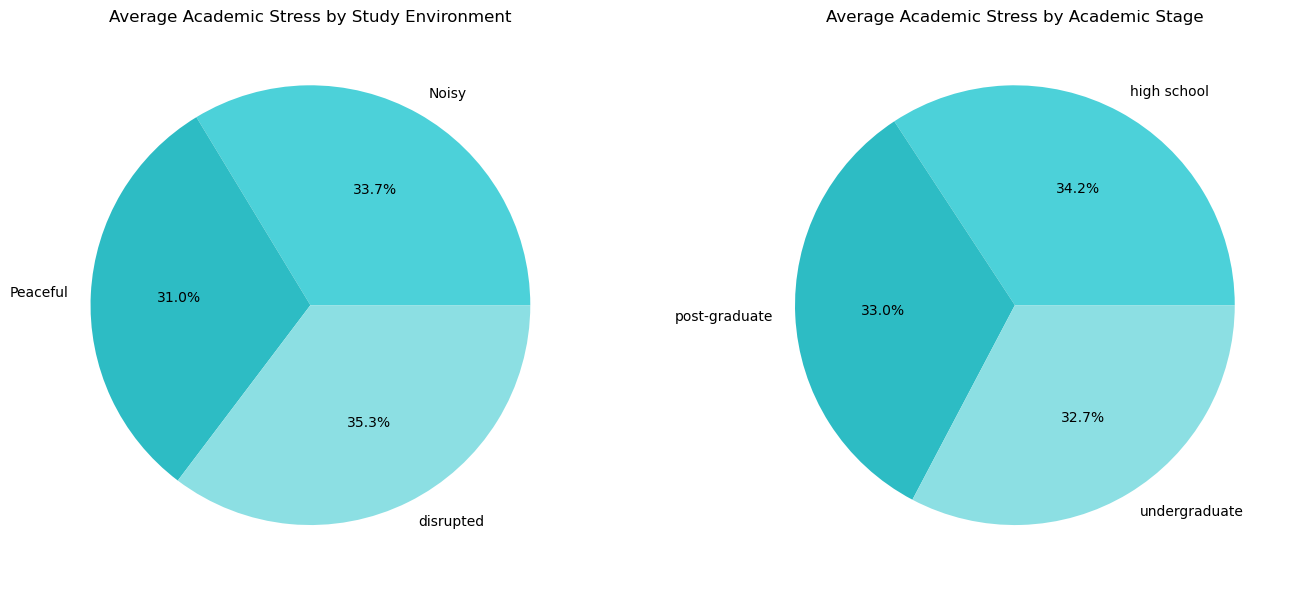

In [37]:
# Create subplots for pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Assigning the colors
colorsPieCharts = ["#4cd1d9", "#2dbcc4", "#8cdfe3"]

# Pie Chart for Average Academic Stress by Study Environment
stressEnv.plot(kind = "pie", autopct = "%1.1f%%", ax = axes[0], colors = colorsPieCharts)
axes[0].set_title("Average Academic Stress by Study Environment")
axes[0].set_ylabel("")

# Pie Chart for Average Academic Stress by Academic Stage
stressAcademic.plot(kind = "pie", autopct = "%1.1f%%", ax = axes[1], colors = colorsPieCharts)
axes[1].set_title("Average Academic Stress by Academic Stage")
axes[1].set_ylabel("")

# Setting tight Layout to fit both the pie charts in the frame
plt.tight_layout()
plt.show()

### Findings and Conclusion
Students in a **disrupted study environment** account for the **largest proportion of average academic stress (35.3%)**, indicating the highest stress levels among the three categories.
**Noisy environments** contribute **33.7%** of the overall average stress, suggesting that background disturbances and lack of concentration significantly impact student stress. **Peaceful environments** show the **lowest proportion of stress (31.0%)**, highlighting the positive role of a calm and stable study setting in reducing academic stress.

**High school students** represent the **largest share of academic stress (34.2%)**, possibly due to academic pressure, examinations, and career-related uncertainty. **Post-graduate students** account for **33.0%** of the total stress, reflecting challenges such as advanced coursework, research responsibilities, and future career planning. **Undergraduate students** show a slightly lower proportion at **32.7%**, indicating relatively moderate stress levels compared to other stages.

In conclusion, both pie charts collectively demonstrate that **environmental factors and academic stage influence academic stress levels**. Creating peaceful study environments and offering targeted academic support especially for high school students because it can help in reducing stress and improving overall student well-being.

# Section 5: GUI Development


## Implementation
To enhance the interpretability and usability of the statistical analysis, a **Graphical User Interface (GUI)** was developed using the **Tkinter** library in Python. It allows users to interactively explore statistical summaries of key numerical variables related to academic stress.

The GUI integrates:
1. Automated computation of **mean, median, and mode** using a predefined statistical function.
2. Dynamic display of results within the application window.
3. **Contextual interpretations** for each academic stress factor to aid non-technical understanding.

By providing an interactive dashboard, the GUI bridges the gap between raw statistical outputs and meaningful insights, making the analysis more accessible and intuitive for users.

In [38]:
# Importing required libraries for GUI Development
import tkinter as tk
import sys
import io

# The dashboard is opened on demand rather than automatically: Tkinter's
# mainloop() blocks until the window is closed, which would stall an
# automated top-to-bottom run of the notebook. Set LAUNCH_GUI = True and
# re-run this cell to open the Academic Stress Dashboard.
LAUNCH_GUI = False

# Function to capture printed output
def display_output(func, *args):
    textBox.delete("1.0", tk.END)

    buffer = io.StringIO()
    sys.stdout = buffer

    func(*args)

    sys.stdout = sys.__stdout__
    textBox.insert(tk.END, buffer.getvalue())

# Wrapper for individual statistics and interpretation
def outputGUI(values, label):
    display_output(statistics_of_numerical_features, values, label)

    if label == "Home Academic Pressure":
        textBox.insert(tk.END,
            "\nInterpretation:\n"
            "1. Moderate level of pressure overall.\n"
            "2. Most students experience a medium level rather than extreme pressure.\n"
        )

    elif label == "Peer Pressure":
        textBox.insert(tk.END,
            "\nInterpretation:\n"
            "1. Peer pressure exists at a moderate level.\n"
            "2. It is not overwhelming for the majority of students.\n"
        )

    elif label == "Academic Stress Index":
        textBox.insert(tk.END,
            "\nInterpretation:\n"
            "1. Higher stress levels compared to other factors.\n"
            "2. Many students experience high academic stress, which is concerning.\n"
        )

    elif label == "Academic Competition":
        textBox.insert(tk.END,
            "\nInterpretation:\n"
            "1. Strong academic competition perceived by students.\n"
            "2. Competitive environment may contribute to elevated stress levels.\n"
        )


def launch_dashboard():
    """Build and display the statistics dashboard. Blocks until it is closed."""
    global textBox

    # ---------------- GUI DESIGN ---------------- #


    # Main Window
    root = tk.Tk()
    root.title("Academic Stress Dashboard")
    root.geometry("780x360")
    root.configure(bg="#e8ecf1")   # Light grey-blue background

    # Title Bar
    tk.Label(
        root,
        text="Academic Stress Analysis",
        font=("Times New Roman", 16, "bold"),
        bg="#1f3c88",   # Deep navy
        fg="white"
    ).pack(pady=8)

    # Main Frame
    main_frame = tk.Frame(root, bg="#e8ecf1")
    main_frame.pack(fill="both", expand=True, padx=8)

    # Left Frame (Buttons)
    left_frame = tk.Frame(main_frame, bg="#e8ecf1")
    left_frame.pack(side="left", fill="y", padx=6)

    tk.Label(
        left_frame,
        text="Statistical Analysis",
        font=("Arial", 11, "bold"),
        bg="#1f3c88",
        fg="white",
        padx=6,
        pady=3
    ).pack(pady=6)

    button_style = {
        "width": 30,
        "font": ("Arial", 10),
        "bg": "#2e59a7",   # Medium blue
        "fg": "white",
        "bd": 0,
        "pady": 5
    }

    tk.Button(
        left_frame,
        text="Home Academic Pressure",
        command=lambda: outputGUI(home_academic_pressure_list, "Home Academic Pressure"),
        **button_style
    ).pack(pady=3)

    tk.Button(
        left_frame,
        text="Peer Pressure",
        command=lambda: outputGUI(peer_pressure_list, "Peer Pressure"),
        **button_style
    ).pack(pady=3)

    tk.Button(
        left_frame,
        text="Academic Competition",
        command=lambda: outputGUI(competition_list, "Academic Competition"),
        **button_style
    ).pack(pady=3)

    tk.Button(
        left_frame,
        text="Academic Stress Index",
        command=lambda: outputGUI(stress_list, "Academic Stress Index"),
        **button_style
    ).pack(pady=3)

    # Right Frame (Output)
    right_frame = tk.Frame(main_frame, bg="#e8ecf1")
    right_frame.pack(side="right", fill="both", expand=True, padx=6)

    tk.Label(
        right_frame,
        text="Statistical Summary",
        font=("Arial", 11, "bold"),
        bg="#1f3c88",
        fg="white",
        padx=6,
        pady=3
    ).pack(pady=6)

    textBox = tk.Text(
        right_frame,
        height=16,
        width=60,
        font=("Consolas", 10),
        wrap="word",
        bd=1,
        relief="solid",
        bg="white",
        fg="#222222"
    )
    textBox.pack(fill="both", expand=True)

    # Exit Button
    tk.Button(
        root,
        text="Exit",
        command=root.destroy,
        width=22,
        font=("Arial", 10, "bold"),
        bg="#2e59a7",
        fg="white"
    ).pack(pady=6)

    root.mainloop()


if LAUNCH_GUI:
    launch_dashboard()
else:
    print("Academic Stress Dashboard is ready but not opened.")
    print("Set LAUNCH_GUI = True at the top of this cell and re-run it to launch the window.")


Academic Stress Dashboard is ready but not opened.
Set LAUNCH_GUI = True at the top of this cell and re-run it to launch the window.


## Findings and Conclusion
The developed GUI presents four key dimensions of academic stress:
1. Home Academic Pressure  
2. Peer Pressure  
3. Academic Competition  
4. Academic Stress Index  

Upon clicking any of the analysis buttons, the application displays:
1. A statistical summary (mean, median, and mode).
2. A concise interpretation explaining what the statistics imply about student stress levels.

The window design ensures that users not only view numerical results but also understand their real-world implications. Overall, the GUI improves clarity, reduces analytical complexity, and supports informed interpretation of academic stress patterns among students.

# Section 6: Conclusion: Version Control, Critical Appraisal, Documentation


## Version Control Implementation

Impementation is done using version control by using GitHub. A repository was used for the entire project and it was updated incrementally as new code or markdown cell was added. Each commit was made with a clear and descriptive message that explained what was changed or added at that stage, such as implementing statistical summary functions or improving the layout and interaction of the GUI.

The notebook followed a clear structure:
1. The introduction outlined the dataset and framed the real‑world issue of academic stress.
2. Sections 1 to 5 walked through the full workflow, including data cleaning, preprocessing, statistical analysis, and interpretation.
3. A dedicated GUI section showed how the results could be explored interactively using Tkinter.

By keeping everything in one place, the analysis remains fully reproducible and easy to follow, whether the reader has a technical background or not.

## Maintaing Coding Standards

1. **Data Quality and Structure**: The results depend heavily on the accuracy and completeness of the dataset. While the grouping and averaging methods offer clear trends, they do not account for potential biases such as uneven sample sizes across categories or missing values that may influence the mean stress scores. A more robust approach could include additional statistical tests or confidence intervals to validate the observed differences.
2. **Use of Mean Values**: Relying solely on mean stress levels simplifies interpretation but may overlook important variability within groups. For example, two academic stages may share similar averages but differ significantly in distribution or outliers. Incorporating measures such as standard deviation or visualisations (e.g., boxplots) would provide a more nuanced understanding of stress patterns.
3. **Categorical Grouping Limitations**: The analysis treats categories such as “Bad Habits,” “Study Environment,” and “Competition Level” as fixed and independent. In reality, these factors may interact in more complex ways. For instance, students with unhealthy habits may also be more likely to study in disrupted environments, creating overlapping influences that simple group means cannot fully capture.
4. **Interpretation of Combined Analyses**: The combined analyses (e.g., Academic Stage × Study Environment) offer richer insights, but they also introduce the risk of over‑interpreting small subgroup sizes. Some categories may contain very few students, making the resulting averages less reliable. Future work could benefit from checking sample counts or applying weighted analysis.
5. **Causation vs Correlation**: The findings highlight strong associations, but they do not establish causation. For example, disrupted environments correlate with higher stress, but it is unclear whether the environment causes stress or whether stressed students are more likely to choose—or end up in—disrupted spaces. A more rigorous study design or additional variables would be needed to explore causal relationships.
6. **Scope of Variables**: Academic stress is influenced by many factors not captured in the dataset, such as mental health history, family expectations, financial pressure, or personal coping strategies. The current analysis provides valuable insights but represents only part of a much broader picture.


## Critical Appraisal of the Code

A range of technical evaluation methods were used throughout development to ensure the code was reliable, readable, and efficient.

1. **Code Review**: The code went through several rounds of review to improve clarity and remove unnecessary repetition. Variable names, function structures, and overall formatting were refined so the logic was easier to understand and maintain.
2. **Static Code Analysis**: Although no automated tools were used, key static analysis principles were applied manually. It included checking whether conditions and loops behaved as intended, how missing or invalid values were handled, consistency in indentation and coding style. Also, it checks helped reduce the risk of runtime errors and strengthened the overall robustness of the code.
3. **Functional Testing**: Each function was tested using different slices of the dataset to verify that the statistical outputs were accurate. The GUI was also tested to ensure that each button triggered the correct calculations and displayed the right results.
4. **Performance Considerations**: Efforst were made to avoid repeated or unnecessary computations and keep the GUI responsive during interactions. Reuse previously computed values whenever possible.
   
As a result, these steps helped maintain smooth performance, even when users triggered multiple analyses through the interface.



## Conclusion

The analysis shows that academic stress is strongly influenced by a combination of study environment, academic stage, lifestyle habits, and competition levels. Disrupted or noisy environments consistently lead to higher stress, while peaceful spaces help reduce it across all student groups. High school students experience the greatest stress overall, highlighting the need for early academic and emotional support.

Unhealthy habits and high academic competition further increase stress, especially for undergraduate and post‑graduate students. Although low competition reduces stress for most groups, post‑graduate students remain affected by additional pressures beyond competition alone.

Overall, the findings emphasise that improving study conditions, promoting healthy routines, and managing competitive pressure can significantly help reduce academic stress, particularly for younger and higher‑education students.


# Part II — Machine Learning Extension

Part I of this notebook established the analytical foundation: the dataset was imported, column names were cleaned, missing values were handled, and the relationships between academic stress and its surrounding factors were explored through grouped summaries, statistical summaries and visualisations.

Part II builds a complete, reproducible **predictive modelling pipeline** on top of that foundation. The academic stress index is modelled from two complementary perspectives:

| Perspective | Target | Question answered |
| --- | --- | --- |
| **Regression** | `Academic Stress Index` (1–5, continuous) | *How intense is a student's reported stress likely to be?* |
| **Classification** | Stress band (`Low` / `Moderate` / `High`) | *Which stress band is a student most likely to fall into?* |

### Why Part II re-loads the raw CSV instead of reusing `df`

The `df` object built in Part I is well suited to exploratory analysis but **must not be used directly for supervised learning**. Two reasons:

1. **Preprocessing leakage.** Part I imputed missing values with the median/mode of the *entire* dataset (Section 3). If those imputed values were carried into a train/test split, statistics derived from the test rows would already be baked into the training data. Every imputation, scaling and encoding step in Part II is therefore fitted **inside a scikit-learn `Pipeline`, on training folds only**.
2. **Target leakage.** Part I derived helper columns such as `Academic Stress Category` *from the target itself*. Using them as predictors would let a model read the answer off its own input. They are deliberately excluded from the feature set.

Part II therefore starts again from `Academic Stress Dataset.csv` and rebuilds a clean modelling frame under strict pipeline discipline. **The original CSV is never modified or overwritten** — all cleaning happens on in-memory copies, and the Part I objects are left untouched.

### Roadmap

`Raw data → quality assessment → cleaning → feature engineering → leakage-safe split → baselines → regression → classification → tuning → explainability → statistical analysis → robustness checks → example predictions → saved models → key findings`

## ML.1 Imports and Configuration

All third-party dependencies for the machine learning work are imported in one place, and every source of randomness is pinned to a single constant, `RANDOM_STATE = 42`, so that the notebook produces identical results on every fresh run.

Two dependencies are **optional**: `xgboost` (gradient boosting) and `shap` (explainability). Their availability is detected at import time and stored in boolean flags, so the notebook still runs end-to-end on a machine where they are not installed — the affected sections degrade gracefully instead of raising.

All values that would otherwise become magic numbers later on (test-set size, cross-validation scheme, Likert scale bounds, stress band cut-points, output directory) are defined here as named constants and reused throughout.

In [39]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import json
import random
import warnings
from datetime import datetime, timezone
from pathlib import Path

# ---------------------------------------------------------------------------
# Scientific stack
# ---------------------------------------------------------------------------
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy import stats

# ---------------------------------------------------------------------------
# scikit-learn: preprocessing, model selection, models, metrics
# ---------------------------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    explained_variance_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# ---------------------------------------------------------------------------
# Optional dependencies - detected, never assumed
# ---------------------------------------------------------------------------
try:
    from xgboost import XGBClassifier, XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    # shap pulls in tqdm, which warns about ipywidgets in a plain kernel;
    # that notice is unrelated to the analysis, so it is suppressed here.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# ---------------------------------------------------------------------------
# Reproducibility: one seed, applied everywhere
# ---------------------------------------------------------------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ---------------------------------------------------------------------------
# Project configuration - no unexplained constants later in the notebook
# ---------------------------------------------------------------------------
# Paths are resolved from the repository root (located in Section 1) rather than from
# a hard-coded location, so every path below survives a clone onto another machine.
DATA_PATH = PROJECT_ROOT / "data" / "Academic Stress Dataset.csv"  # read-only; never overwritten
MODEL_DIR = PROJECT_ROOT / "models"                                # created on demand when saving
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"                  # PNG copies of the key charts

TARGET = "Academic Stress Index"                  # regression target (1-5 Likert)
LIKERT_MIN, LIKERT_MAX = 1, 5                     # valid range of every rating item
TIMESTAMP_FORMAT = "%d/%m/%Y %H:%M"               # format used by the survey export

TEST_SIZE = 0.25                                  # hold-out share of the labelled rows
CV_SPLITS, CV_REPEATS = 5, 3                      # repeated CV -> stabler estimates on a small sample

# Stress bands used for the classification problem (justified in section ML.14)
STRESS_BAND_EDGES = [LIKERT_MIN - 1, 2, 3, LIKERT_MAX]     # (0, 2] -> Low, (2, 3] -> Moderate, (3, 5] -> High
STRESS_BAND_LABELS = ["Low", "Moderate", "High"]

# ---------------------------------------------------------------------------
# Visual style - extends the teal/navy palette already used in Part I
# ---------------------------------------------------------------------------
PALETTE = ["#16afb6", "#4cd1d9", "#1f3c88", "#f4a259", "#b5546b"]
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#556677",
    "savefig.bbox": "tight",
})

# Keep the output readable: the small-sample solvers emit convergence chatter that is
# expected behaviour here rather than an error.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def save_figure(filename):
    """Write the current figure to reports/figures/ so it can be reused outside the notebook."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(FIGURE_DIR / filename, dpi=150, bbox_inches="tight")


def relative_to_root(path):
    """Render a path relative to the project root, so no machine-specific path is printed."""
    return Path(path).relative_to(PROJECT_ROOT).as_posix()

print(f"Project root : {PROJECT_ROOT.name}/")
print("Environment")
print(f"  pandas       {pd.__version__}")
print(f"  numpy        {np.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  xgboost      {'available' if XGBOOST_AVAILABLE else 'not installed - section will be skipped'}")
print(f"  shap         {'available' if SHAP_AVAILABLE else 'not installed - section will be skipped'}")
print(f"\nRANDOM_STATE = {RANDOM_STATE} (applied to splits, models, CV and tuning)")

Project root : Academic Stress Analysis/
Environment
  pandas       2.2.3
  numpy        2.1.3
  scikit-learn 1.6.1
  xgboost      available
  shap         available

RANDOM_STATE = 42 (applied to splits, models, CV and tuning)


### Findings and Conclusion

The environment report records the exact library versions behind every number in Part II, which is what makes the results auditable by a reader running the notebook later. A single `RANDOM_STATE` is threaded through the train/test split, the cross-validation folds, every stochastic model and both hyperparameter searches, so repeated executions from a fresh kernel reproduce the same tables and figures.

## ML.2 Data Loading

The raw survey export is re-read from disk into a **separate object** (`ml_raw`) so that the Part I analysis above remains untouched. The only transformation applied at load time is stripping stray whitespace from the column headers and applying the same short column names used in Part I — this keeps a single vocabulary across the whole notebook.

In [40]:
# Canonical short names, identical to the ones adopted in Part I.
COLUMN_RENAME = {
    "Your Academic Stage": "Academic Stage",
    "Academic pressure from your home": "Home Academic Pressure",
    "What coping strategy you use as a student?": "Coping Strategy",
    "Do you have any bad habits like smoking, drinking on a daily basis?": "Bad Habits",
    "What would you rate the academic  competition in your student life": "Academic Competition",
    "Rate your academic stress index": "Academic Stress Index",
}


def load_raw_dataset(path=DATA_PATH):
    """Read the survey export and apply header-level tidying only.

    No row-level cleaning happens here, so the data-quality assessment in section
    ML.3 describes the data exactly as it arrives from the source file.
    """
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip()
    return frame.rename(columns=COLUMN_RENAME)


ml_raw = load_raw_dataset()

print(f"Loaded {ml_raw.shape[0]} responses x {ml_raw.shape[1]} columns "
      f"from '{relative_to_root(DATA_PATH)}'")
ml_raw.head()

Loaded 140 responses x 9 columns from 'data/Academic Stress Dataset.csv'


,Timestamp,Academic Stage,Peer pressure,Home Academic Pressure,Study Environment,Coping Strategy,Bad Habits,Academic Competition,Academic Stress Index
0,24/07/2025 22:05,undergraduate,4.0,5.0,Noisy,Analyze the situation and handle it with intel...,No,3.0,5.0
1,24/07/2025 22:05,undergraduate,3.0,4.0,Peaceful,Analyze the situation and handle it with intel...,No,3.0,3.0
2,24/07/2025 22:06,undergraduate,1.0,1.0,Peaceful,"Social support (friends, family)",No,2.0,4.0
3,24/07/2025 22:06,undergraduate,3.0,2.0,Peaceful,Analyze the situation and handle it with intel...,No,4.0,3.0
4,24/07/2025 22:08,undergraduate,3.0,3.0,Peaceful,Analyze the situation and handle it with intel...,No,4.0,5.0


### Findings and Conclusion

The modelling copy of the dataset contains **140 survey responses across 9 columns**: one timestamp, four ordinal Likert ratings (peer pressure, home academic pressure, academic competition and the stress index itself) and four categorical items (academic stage, study environment, coping strategy and bad habits). This is a small dataset by machine learning standards, and that fact shapes every methodological decision that follows — model complexity, cross-validation scheme, and the strength of the conclusions that can fairly be drawn.

## ML.3 Data Quality Assessment

Before any cleaning decision is taken, the dataset is profiled systematically. A reusable `data_quality_report()` function summarises, for every column: data type, missing count and percentage, number of distinct values, and a sample of the values actually present. Running the same function *before* and *after* cleaning produces the concise before/after comparison an auditable pipeline needs.

The profile is run on the raw frame, so problems are discovered rather than assumed.

In [41]:
def data_quality_report(frame, name="dataset"):
    """Return a per-column data-quality profile for `frame`."""
    report = pd.DataFrame({
        "Data type": frame.dtypes.astype(str),
        "Missing": frame.isna().sum(),
        "Missing %": (frame.isna().mean() * 100).round(1),
        "Unique values": frame.nunique(dropna=True),
    })
    report["Example values"] = [
        ", ".join(map(str, pd.Series(frame[col].dropna().unique()).head(3)))[:60]
        for col in frame.columns
    ]
    report.index.name = f"Column ({name})"
    return report


quality_before = data_quality_report(ml_raw, "raw")
display(quality_before)

exact_duplicates = int(ml_raw.duplicated().sum())
answer_duplicates = int(ml_raw.drop(columns=["Timestamp"]).duplicated().sum())

print(f"Exact duplicate rows (including Timestamp)   : {exact_duplicates}")
print(f"Duplicate answer patterns (ignoring Timestamp): {answer_duplicates}")
print(f"Total missing cells                          : {int(ml_raw.isna().sum().sum())} "
      f"({ml_raw.isna().mean().mean() * 100:.1f}% of all cells)")

,Data type,Missing,Missing %,Unique values,Example values
Column (raw),,,,,
Timestamp,object,0,0.0,111,"24/07/2025 22:05, 24/07/2025 22:06, 24/07/2025..."
Academic Stage,object,0,0.0,3,"undergraduate, high school, post-graduate"
Peer pressure,float64,10,7.1,5,"4.0, 3.0, 1.0"
Home Academic Pressure,float64,10,7.1,5,"5.0, 4.0, 1.0"
Study Environment,object,8,5.7,3,"Noisy, Peaceful, disrupted"
Coping Strategy,object,7,5.0,3,Analyze the situation and handle it with intel...
Bad Habits,object,0,0.0,3,"No, prefer not to say, Yes"
Academic Competition,float64,9,6.4,5,"3.0, 2.0, 4.0"
Academic Stress Index,float64,11,7.9,5,"5.0, 3.0, 4.0"


Exact duplicate rows (including Timestamp)   : 0
Duplicate answer patterns (ignoring Timestamp): 5
Total missing cells                          : 55 (4.4% of all cells)


In [42]:
# Inspect the raw category labels and the numeric ranges for inconsistencies.
categorical_raw = ["Academic Stage", "Study Environment", "Coping Strategy", "Bad Habits"]
numeric_raw = ["Peer pressure", "Home Academic Pressure", "Academic Competition", TARGET]

for column in categorical_raw:
    print(f"\n{column}")
    for value, count in ml_raw[column].value_counts(dropna=False).items():
        print(f"   {str(value):<55} {count:>4}")

print("\nNumeric rating items - observed range and out-of-scale values")
numeric_profile = pd.DataFrame({
    "min": ml_raw[numeric_raw].min(),
    "max": ml_raw[numeric_raw].max(),
    "mean": ml_raw[numeric_raw].mean().round(2),
    f"outside {LIKERT_MIN}-{LIKERT_MAX}": [
        int((~ml_raw[c].between(LIKERT_MIN, LIKERT_MAX) & ml_raw[c].notna()).sum())
        for c in numeric_raw
    ],
})
display(numeric_profile)

print("Timestamp column parses cleanly as a datetime:",
      bool(pd.to_datetime(ml_raw["Timestamp"], format=TIMESTAMP_FORMAT, errors="coerce").notna().all()))


Academic Stage
   undergraduate                                            100
   high school                                               29
   post-graduate                                             11

Study Environment
   Peaceful                                                  66
   disrupted                                                 34
   Noisy                                                     32
   nan                                                        8

Coping Strategy
   Analyze the situation and handle it with intellect        80
   Emotional breakdown (crying a lot)                        32
   Social support (friends, family)                          21
   nan                                                        7

Bad Habits
   No                                                       123
   Yes                                                       10
   prefer not to say                                          7

Numeric rating items - observed range a

,min,max,mean,outside 1-5
Column (raw),,,,
Peer pressure,1.0,5.0,3.09,0
Home Academic Pressure,1.0,5.0,3.17,0
Academic Competition,1.0,5.0,3.46,0
Academic Stress Index,1.0,5.0,3.71,0


Timestamp column parses cleanly as a datetime: True


### Findings and Conclusion

The profile surfaces five concrete issues, each addressed explicitly in the cleaning section:

1. **Missing values are spread across six columns** (55 missing cells, ~4.4% of the grid). Crucially, **11 responses have no stress index at all** — these rows carry no ground truth and cannot be used for supervised learning.
2. **Inconsistent capitalisation in `Study Environment`**: the labels are `Peaceful`, `Noisy` and `disrupted`. Left unfixed, `disrupted` and `Disrupted` would encode as two separate categories.
3. **`Timestamp` is stored as text**, not as a datetime, so no temporal feature can be derived from it until it is parsed.
4. **Verbose survey labels** (for example `Analyze the situation and handle it with intellect`) are accurate but unwieldy; they are mapped to short canonical labels for readable plots and feature names.
5. **Five duplicate answer patterns** exist once the timestamp is ignored, while there are **zero exact duplicates**.

The numeric profile confirms that all four rating items lie strictly within the valid 1–5 Likert range, so there are no impossible or out-of-scale ratings to correct. The timestamp column parses cleanly with a single known format, so no malformed dates need special handling.

## ML.4 Data Cleaning

Cleaning is implemented as a single idempotent function, `clean_dataset()`, so that exactly the same transformation can be applied to the training data, to the hold-out data, and later to brand-new records at prediction time. The function only touches columns that are actually present, which is what allows the prediction demonstration in section ML.22 to push a hypothetical student through the identical code path.

**What the function does, and why:**

| Step | Action | Reasoning |
| --- | --- | --- |
| Timestamp | Parse with an explicit format | Enables temporal feature extraction; an explicit format prevents silent day/month misreads |
| Categorical text | Strip whitespace, lower-case, map to canonical labels | Removes the `disrupted`/`Disrupted` split and shortens verbose wording without changing meaning |
| Rating items | Coerce to numeric | Guarantees a numeric dtype even if a stray text entry appears in a future export |
| Rating items | Set values outside 1–5 to `NaN` | An out-of-scale rating is invalid rather than extreme; flagging it as missing lets the pipeline's imputer handle it |
| Unmapped categories | Left as `NaN` and reported | Silently dropping an unrecognised label would hide a data problem |

**What the function deliberately does *not* do:**

* **It does not impute.** Imputation is a *learned* transformation — the median depends on the data it sees — so it belongs inside the cross-validated pipeline, fitted on training folds only. Doing it here would leak information from the hold-out set into training.
* **It does not remove duplicates.** With three Likert items and four short categorical items, distinct students can legitimately give identical answers. The five repeated answer patterns are separated by minutes to weeks in the timestamp, and each consists of the most common response on every item — exactly what chance agreement looks like. Deleting them would discard genuine observations and bias the sample towards unusual answer combinations, so they are retained and the assumption is recorded in the limitations.
* **It does not trim "outliers".** Every value is a valid point on a 1–5 opinion scale. A student who reports 1 or 5 is an informative respondent, not a measurement error, so no rating is removed or winsorised.

In [43]:
# Canonical label maps: lower-cased survey text -> short analysis label.
CATEGORY_CANONICAL_MAP = {
    "Academic Stage": {
        "high school": "High School",
        "undergraduate": "Undergraduate",
        "post-graduate": "Post-Graduate",
    },
    "Study Environment": {
        "peaceful": "Peaceful",
        "noisy": "Noisy",
        "disrupted": "Disrupted",       # fixes the lower-case inconsistency in the source file
    },
    "Coping Strategy": {
        "analyze the situation and handle it with intellect": "Analytical",
        "emotional breakdown (crying a lot)": "Emotional Breakdown",
        "social support (friends, family)": "Social Support",
    },
    "Bad Habits": {
        "no": "No",
        "yes": "Yes",
        "prefer not to say": "Prefer not to say",
    },
}

RATING_ITEMS = ["Peer pressure", "Home Academic Pressure", "Academic Competition"]


def clean_dataset(frame, verbose=False):
    """Standardise types, labels and value ranges. No imputation, no row deletion.

    Only columns present in `frame` are touched, so the same function serves the
    training data and single unlabelled records at prediction time.
    """
    cleaned = frame.copy()

    if "Timestamp" in cleaned.columns:
        cleaned["Timestamp"] = pd.to_datetime(
            cleaned["Timestamp"], format=TIMESTAMP_FORMAT, errors="coerce"
        )

    for column, mapping in CATEGORY_CANONICAL_MAP.items():
        if column not in cleaned.columns:
            continue
        standardised = cleaned[column].astype("string").str.strip().str.lower()
        known = standardised.dropna()
        unmapped = sorted(set(known[~known.isin(mapping)]))
        if verbose and unmapped:
            print(f"  ! {column}: unrecognised labels set to NaN -> {unmapped}")
        cleaned[column] = standardised.map(mapping)

    for column in RATING_ITEMS + [TARGET]:
        if column not in cleaned.columns:
            continue
        cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")
        out_of_scale = ~cleaned[column].between(LIKERT_MIN, LIKERT_MAX) & cleaned[column].notna()
        if verbose and int(out_of_scale.sum()):
            print(f"  ! {column}: {int(out_of_scale.sum())} out-of-scale value(s) set to NaN")
        cleaned.loc[out_of_scale, column] = np.nan

    return cleaned


print("Cleaning report (anything unexpected is listed below)")
ml_clean = clean_dataset(ml_raw, verbose=True)

print(f"\nStudy Environment after standardisation: {sorted(ml_clean['Study Environment'].dropna().unique())}")
print(f"Coping Strategy after standardisation  : {sorted(ml_clean['Coping Strategy'].dropna().unique())}")
print(f"Timestamp dtype                        : {ml_clean['Timestamp'].dtype}")
print(f"Survey window                          : "
      f"{ml_clean['Timestamp'].min():%d %b %Y} to {ml_clean['Timestamp'].max():%d %b %Y}")

Cleaning report (anything unexpected is listed below)

Study Environment after standardisation: ['Disrupted', 'Noisy', 'Peaceful']
Coping Strategy after standardisation  : ['Analytical', 'Emotional Breakdown', 'Social Support']
Timestamp dtype                        : datetime64[ns]
Survey window                          : 24 Jul 2025 to 18 Aug 2025


In [44]:
# Rows without a stress rating cannot be used for supervised learning: there is no
# ground truth to train on and none to evaluate against. Imputing the *target* would
# fabricate labels and inflate every metric that follows, so these rows are removed
# here (and only here) rather than filled.
missing_target = int(ml_clean[TARGET].isna().sum())
ml_model = ml_clean.dropna(subset=[TARGET]).reset_index(drop=True)

print(f"Responses loaded                    : {len(ml_clean)}")
print(f"Removed - no stress rating recorded : {missing_target}")
print(f"Retained for modelling              : {len(ml_model)}")

print("\nMissing values remaining in the PREDICTORS (imputed inside the pipeline, not here):")
print(ml_model.drop(columns=[TARGET]).isna().sum().to_string())

quality_after = data_quality_report(ml_model, "cleaned")
quality_comparison = pd.concat(
    [quality_before[["Data type", "Missing", "Unique values"]],
     quality_after[["Data type", "Missing", "Unique values"]]],
    axis=1, keys=["Before cleaning", "After cleaning"],
)
print("\nData quality: before vs after")
display(quality_comparison)

Responses loaded                    : 140
Removed - no stress rating recorded : 11
Retained for modelling              : 129

Missing values remaining in the PREDICTORS (imputed inside the pipeline, not here):
Column (raw)
Timestamp                 0
Academic Stage            0
Peer pressure             9
Home Academic Pressure    6
Study Environment         8
Coping Strategy           7
Bad Habits                0
Academic Competition      9

Data quality: before vs after


Before cleaning                        After cleaning                      
                             Data type Missing Unique values       Data type Missing Unique values
Timestamp                       object       0           111  datetime64[ns]       0           102
Academic Stage                  object       0             3          object       0             3
Peer pressure                  float64      10             5         float64       9             5
Home Academic Pressure         float64      10             5         float64       6             5
Study Environment               object       8             3          object       8             3
Coping Strategy                 object       7             3          object       7             3
Bad Habits                      object       0             3          object       0             3
Academic Competition           float64       9             5         float64       9             5
Academic Stress Index          float64      11             5         float64       0             5

### Findings and Conclusion

Cleaning changed the dataset in three visible ways:

* `Timestamp` became a true `datetime64` column rather than text, unlocking the temporal features tested in section ML.6.
* `Study Environment` collapsed from four apparent categories to the three real ones, and the verbose coping-strategy and stage labels became short canonical labels. **No response was reinterpreted** — only its spelling was standardised.
* **11 responses without a stress rating were removed**, leaving **129 labelled rows** for modelling. Missing values in the *predictors* were left in place on purpose; they are imputed inside the cross-validated pipeline so the imputation statistics are learned from training data only.

129 rows is a small sample. Everything downstream is built with that in mind: repeated cross-validation rather than a single split, deliberately shallow tree models, simple baselines as the yardstick, and cautious language about generalisation.

## ML.5 Exploratory Data Analysis for Modelling

Part I already covered the descriptive picture — stress distribution, group means by study environment and academic stage, the peer-pressure scatter plot and the proportional pie charts. Rather than repeat that work, this section adds the two views that a *modelling* workflow specifically needs and that Part I did not produce:

1. **A rank-correlation matrix** across all the ordinal rating items, to see how strongly the candidate predictors move with the target and with each other. Spearman (rank) correlation is used rather than Pearson because Likert responses are ordinal: the numbers order the responses but the gap between "2" and "3" is not guaranteed to equal the gap between "4" and "5".
2. **The target distribution split by band**, which determines how the classification problem in section ML.14 has to be set up.

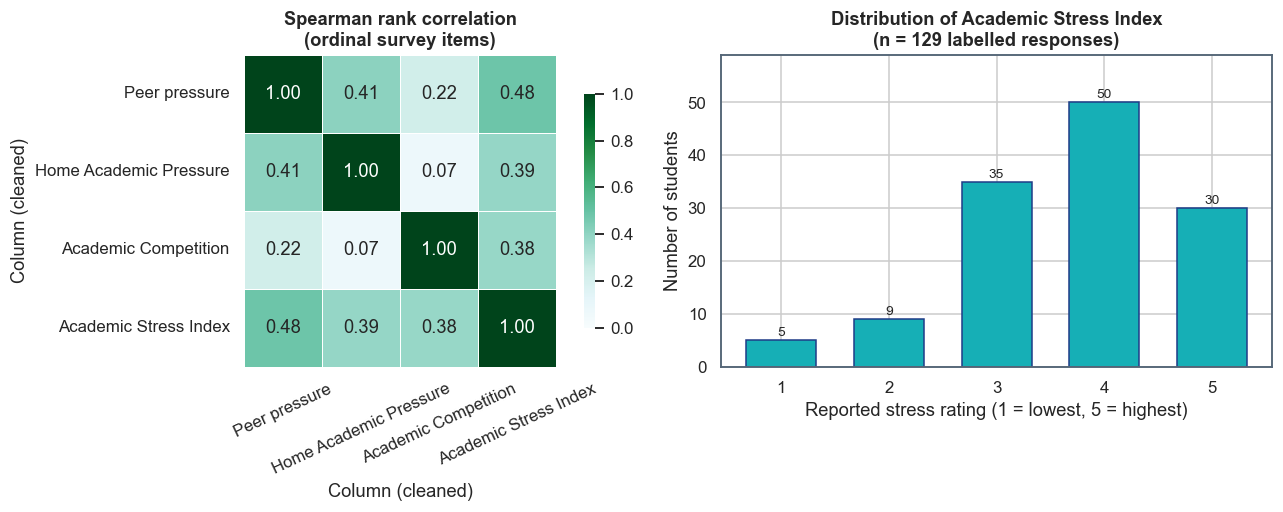

Target summary
count    129.00
mean       3.71
std        1.03
min        1.00
25%        3.00
50%        4.00
75%        4.00
max        5.00

Share of students reporting 4 or 5: 62.0%


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# --- Left: Spearman rank correlation among the ordinal items -----------------
ordinal_items = RATING_ITEMS + [TARGET]
spearman_matrix = ml_model[ordinal_items].corr(method="spearman")

sns.heatmap(
    spearman_matrix, annot=True, fmt=".2f", cmap="BuGn", vmin=0, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.75}, ax=axes[0],
)
axes[0].set_title("Spearman rank correlation\n(ordinal survey items)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].tick_params(axis="y", rotation=0)

# --- Right: distribution of the target ---------------------------------------
target_counts = ml_model[TARGET].value_counts().sort_index()
axes[1].bar(target_counts.index, target_counts.values,
            color=PALETTE[0], edgecolor=PALETTE[2], width=0.65)
for rating, count in target_counts.items():
    axes[1].text(rating, count + 0.8, str(int(count)), ha="center", fontsize=9)
axes[1].set_title(f"Distribution of {TARGET}\n(n = {len(ml_model)} labelled responses)")
axes[1].set_xlabel("Reported stress rating (1 = lowest, 5 = highest)")
axes[1].set_ylabel("Number of students")
axes[1].set_ylim(0, target_counts.max() * 1.18)

plt.tight_layout()
save_figure("eda_correlation_and_target_distribution.png")
plt.show()

print("Target summary")
print(ml_model[TARGET].describe().round(2).to_string())
print(f"\nShare of students reporting 4 or 5: "
      f"{(ml_model[TARGET] >= 4).mean() * 100:.1f}%")

### Findings and Conclusion

**Correlation structure.** All three pressure items correlate positively with the stress index, with peer pressure the strongest single item (ρ ≈ 0.48), followed by home academic pressure and academic competition (both ρ ≈ 0.38–0.39). The predictors are also moderately correlated *with each other*, which matters for two reasons: it suggests they share a common underlying "pressure load" dimension worth capturing as an engineered feature, and it means individual coefficient and importance values must be interpreted with care, because collinear predictors split credit between themselves.

**Target distribution.** The stress index is clearly **left-skewed towards high stress**: ratings of 4 and 5 account for the majority of responses, while ratings of 1 and 2 are rare (14 responses combined). This has two direct consequences for the modelling design:

* For regression, a mean-predictor baseline is unusually hard to beat, because most students sit close to the mean. Any model must be judged against that baseline rather than on its raw error alone.
* For classification, a naive three-band split will be **materially imbalanced**, so accuracy will be a misleading headline metric and macro-averaged scores plus class weighting are required.

## ML.6 Feature Engineering

Features are engineered only where there is a substantive reason to expect them to carry signal the raw columns do not. Each one is stated with its rationale below; nothing is added merely to grow the feature count.

### Composite and interaction features

| Feature | Definition | Reasoning |
| --- | --- | --- |
| `Overall Pressure Score` | Mean of peer pressure, home academic pressure and academic competition | The three items are measured on the same 1–5 scale and are moderately inter-correlated (ML.5), so their mean is a meaningful *total pressure load* index. It is more stable than any single item because item-level rating noise partially cancels. |
| `Peer x Home Pressure` | Peer pressure × home academic pressure | Tests whether the two *social* pressure sources compound: a student squeezed from both peers and home may be worse off than the additive sum implies. A linear model cannot represent this without an explicit product term. |
| `Competition x Home Pressure` | Academic competition × home academic pressure | The same compounding logic for *institutional* competition combined with family expectation. |
| `Environment Disturbance` | Peaceful → 0, Noisy → 1, Disrupted → 2 | The three study environments have a natural order of increasing disturbance. A one-hot encoding discards that ordering; an ordinal encoding lets a model use a single monotone trend, which is far more sample-efficient with only 129 rows. The one-hot version is kept as well, so no information is lost. |
| `Maladaptive Coping` | 1 if coping strategy is `Emotional Breakdown`, else 0 | Coping research draws a standard distinction between problem-focused/support-seeking strategies and distress-driven responses. This groups the two adaptive strategies together and isolates the distress response as a single risk indicator, which is a cheaper signal for a model to learn than three separate one-hot columns. |

### Features deliberately *not* created

* **A "bad habits risk flag"** would be an exact duplicate of the `Bad Habits_Yes` column that one-hot encoding already produces. Adding it would inflate the feature count without adding information.
* **A weighted risk score** (for example `2 × habits + competition`) would require inventing weights that the dataset cannot justify. Any weighting should be *learned* by the model, not hard-coded by the analyst.
* **Anything derived from the target** — a stress category, a high-stress flag, a stress-to-pressure ratio — is excluded outright. Those are the target in disguise and would produce impressive but entirely meaningless metrics.

### Timestamp features

Year, month, day, day-of-week, hour and days-since-first-response are extracted so their value can be **tested rather than assumed**. Section ML.9 measures whether they improve cross-validated performance and drops them if they do not.

In [46]:
# Ordered mapping for the study environment: increasing level of disturbance.
ENVIRONMENT_DISTURBANCE_ORDER = {"Peaceful": 0, "Noisy": 1, "Disrupted": 2}

# Coping strategies split into adaptive (analytical / support-seeking) vs distress-driven.
MALADAPTIVE_COPING = {"Emotional Breakdown"}


def engineer_features(frame):
    """Add composite, interaction, ordinal and temporal features.

    Every feature is a row-wise transformation of that row's own values, so the
    function is safe to apply before splitting: it learns nothing from the data
    as a whole and therefore cannot leak information between train and test.
    """
    out = frame.copy()

    # --- Composite pressure load (same 1-5 scale, so the mean is meaningful) ---
    out["Overall Pressure Score"] = out[RATING_ITEMS].mean(axis=1)

    # --- Interaction terms: compounding pressure sources -----------------------
    out["Peer x Home Pressure"] = out["Peer pressure"] * out["Home Academic Pressure"]
    out["Competition x Home Pressure"] = out["Academic Competition"] * out["Home Academic Pressure"]

    # --- Ordinal encoding of an ordered category ------------------------------
    out["Environment Disturbance"] = out["Study Environment"].map(ENVIRONMENT_DISTURBANCE_ORDER)

    # --- Risk indicator derived from coping style ------------------------------
    out["Maladaptive Coping"] = out["Coping Strategy"].map(
        lambda value: np.nan if pd.isna(value) else float(value in MALADAPTIVE_COPING)
    )

    # --- Temporal features (retained only if section ML.9 shows they help) -----
    if "Timestamp" in out.columns:
        timestamps = out["Timestamp"]
        out["Response Year"] = timestamps.dt.year.astype("float64")
        out["Response Month"] = timestamps.dt.month.astype("float64")
        out["Response Day"] = timestamps.dt.day.astype("float64")
        out["Response DayOfWeek"] = timestamps.dt.dayofweek.astype("float64")
        out["Response Hour"] = timestamps.dt.hour.astype("float64")
        out["Days Since First Response"] = (
            (timestamps - timestamps.min()).dt.total_seconds() / 86_400.0
        )

    return out


ml_features = engineer_features(ml_model)

ENGINEERED_NUMERIC = [
    "Overall Pressure Score",
    "Peer x Home Pressure",
    "Competition x Home Pressure",
    "Environment Disturbance",
    "Maladaptive Coping",
]
TEMPORAL_NUMERIC = [
    "Response Year", "Response Month", "Response Day",
    "Response DayOfWeek", "Response Hour", "Days Since First Response",
]

print("Engineered features (first five modelling rows)")
display(ml_features[ENGINEERED_NUMERIC + TEMPORAL_NUMERIC].head())

# Rank correlation of every candidate numeric feature with the target.
candidate_numeric = RATING_ITEMS + ENGINEERED_NUMERIC + TEMPORAL_NUMERIC
candidate_correlation = (
    ml_features[candidate_numeric + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .rename("Spearman rho with target")
    .to_frame()
)
candidate_correlation["Family"] = np.where(
    candidate_correlation.index.isin(TEMPORAL_NUMERIC), "temporal",
    np.where(candidate_correlation.index.isin(ENGINEERED_NUMERIC), "engineered", "raw survey item"),
)
display(candidate_correlation.round(3))

Engineered features (first five modelling rows)


Column (cleaned),Overall Pressure Score,Peer x Home Pressure,Competition x Home Pressure,Environment Disturbance,Maladaptive Coping,Response Year,Response Month,Response Day,Response DayOfWeek,Response Hour,Days Since First Response
0,4.000000,20.0,15.0,1.0,0.0,2025.0,7.0,24.0,3.0,22.0,0.000000
1,3.333333,12.0,12.0,0.0,0.0,2025.0,7.0,24.0,3.0,22.0,0.000000
2,1.333333,1.0,2.0,0.0,0.0,2025.0,7.0,24.0,3.0,22.0,0.000694
3,3.000000,6.0,8.0,0.0,0.0,2025.0,7.0,24.0,3.0,22.0,0.000694
4,3.333333,9.0,12.0,0.0,0.0,2025.0,7.0,24.0,3.0,22.0,0.002083


,Spearman rho with target,Family
Column (cleaned),,
Overall Pressure Score,0.559,engineered
Peer pressure,0.483,raw survey item
Competition x Home Pressure,0.456,engineered
Peer x Home Pressure,0.447,engineered
Home Academic Pressure,0.386,raw survey item
Academic Competition,0.383,raw survey item
Environment Disturbance,0.277,engineered
Response Hour,-0.173,temporal
Response Month,0.142,temporal


### Findings and Conclusion

`Overall Pressure Score` is the single strongest numeric correlate of reported stress (ρ ≈ 0.56), ahead of every individual rating item — evidence that aggregating the three pressure questions genuinely reduces item-level noise rather than just restating them. The two interaction terms follow closely, and `Environment Disturbance` recovers a moderate positive association (ρ ≈ 0.28) that a plain one-hot encoding would have scattered across three columns.

`Response Year` is constant (every response was collected in 2025) and is dropped automatically by the variance-free check below. The remaining temporal features show only weak correlations, most plausibly reflecting *when the survey link was circulated* rather than anything about the students themselves. Their value is tested empirically in the next section rather than assumed either way.

Note the collinearity that the composite feature deliberately introduces: `Overall Pressure Score` is a function of three columns that are also kept individually. This is fine for prediction — and ridge/lasso regularisation is chosen partly for that reason — but it means feature-importance results must be read as "this *group* of correlated features matters", not "this one column matters and the others do not". That caveat is applied in the explainability section.

## ML.7 Feature and Target Definition, and a Leakage-Safe Split

### Excluded columns

| Column | Why it is excluded |
| --- | --- |
| `Academic Stress Index` | It is the target |
| `Timestamp` | Raw datetime; its information is already captured in the derived temporal features |
| Part I's `*_Category` columns | Derived from the target — including them would be textbook target leakage |
| `Response Year` | Zero variance (all responses are from 2025), so it carries no information |

### How leakage is prevented

1. **Splitting happens before any fitting.** The data is divided into a training set and a hold-out test set *first*; the test set is then used exactly once, at the very end.
2. **All learned preprocessing lives inside a `Pipeline`.** Imputation (median for numeric, most-frequent for categorical), scaling and one-hot encoding are steps of a `ColumnTransformer` that `cross_validate` re-fits inside every fold, on that fold's training portion only. No imputer or scaler ever sees a validation row before predicting it.
3. **Feature engineering is row-wise only.** Every engineered feature is computed from that row's own values, so applying it before the split cannot transfer information between rows.
4. **Model selection uses cross-validation on the training set only.** The hold-out set never influences which model or which hyperparameters are chosen.
5. **The split is stratified by stress band.** With only 14 low-stress students, a random split could easily leave the rarest band almost unrepresented in the test set. Stratifying keeps the band proportions comparable in both partitions, and using the *same* split for regression and classification keeps the two problems directly comparable.

In [47]:
def to_stress_band(values):
    """Map the 1-5 stress rating onto ordered Low / Moderate / High bands."""
    return pd.cut(values, bins=STRESS_BAND_EDGES, labels=STRESS_BAND_LABELS, ordered=True)


# --- Feature inventory -------------------------------------------------------
CATEGORICAL_FEATURES = ["Academic Stage", "Study Environment", "Coping Strategy", "Bad Habits"]
CORE_NUMERIC_FEATURES = RATING_ITEMS + ENGINEERED_NUMERIC

# `Response Year` is constant across the survey window and carries no information.
zero_variance = [c for c in TEMPORAL_NUMERIC if ml_features[c].nunique(dropna=True) <= 1]
CANDIDATE_TEMPORAL_FEATURES = [c for c in TEMPORAL_NUMERIC if c not in zero_variance]
print(f"Dropped as zero-variance: {zero_variance}")

ALL_CANDIDATE_FEATURES = CORE_NUMERIC_FEATURES + CANDIDATE_TEMPORAL_FEATURES + CATEGORICAL_FEATURES

# --- Explicit leakage guard --------------------------------------------------
leaky = [c for c in ALL_CANDIDATE_FEATURES if TARGET.lower() in c.lower() or "stress" in c.lower()]
assert not leaky, f"Target-derived column present in the feature set: {leaky}"
print("Leakage check passed - no target-derived column is used as a predictor.")

# --- Split -------------------------------------------------------------------
X_all = ml_features[ALL_CANDIDATE_FEATURES]
y_regression = ml_features[TARGET]
y_band = to_stress_band(y_regression)

(X_train_all, X_test_all,
 y_reg_train, y_reg_test,
 y_band_train, y_band_test) = train_test_split(
    X_all, y_regression, y_band,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_band,
)

split_summary = pd.DataFrame({
    "Training set": y_band_train.value_counts().reindex(STRESS_BAND_LABELS),
    "Test set": y_band_test.value_counts().reindex(STRESS_BAND_LABELS),
})
split_summary.loc["Total"] = split_summary.sum()

print(f"\nTraining rows: {len(X_train_all)}   Test rows: {len(X_test_all)}   "
      f"(test share = {TEST_SIZE:.0%}, stratified by stress band)")
display(split_summary)
print("Mean stress index - train: "
      f"{y_reg_train.mean():.2f} | test: {y_reg_test.mean():.2f} "
      "(similar means confirm the split is not accidentally skewed)")

Dropped as zero-variance: ['Response Year']
Leakage check passed - no target-derived column is used as a predictor.

Training rows: 96   Test rows: 33   (test share = 25%, stratified by stress band)


,Training set,Test set
Academic Stress Index,,
Low,10,4
Moderate,26,9
High,60,20
Total,96,33


Mean stress index - train: 3.72 | test: 3.67 (similar means confirm the split is not accidentally skewed)


### Findings and Conclusion

The 129 labelled responses split into **96 training rows and 33 hold-out rows**, with the Low/Moderate/High band proportions preserved in both partitions and near-identical mean stress ratings (train ≈ 3.71, test ≈ 3.70). The assertion above is a hard guard rather than a comment: if a target-derived column were ever added to the feature list by accident, the notebook would stop at this cell instead of silently reporting inflated scores.

Only four low-stress students land in the test set. That is an unavoidable consequence of the sample size, and it is the main reason the classification results later are reported with wide uncertainty and read alongside cross-validated scores rather than from the hold-out set alone.

## ML.8 Preprocessing Pipeline

A single `build_preprocessor()` factory produces the `ColumnTransformer` used by every model, so preprocessing is guaranteed to be identical across the comparison:

* **Numeric branch** — median imputation, then standardisation. The median is used because the rating items are ordinal and mildly skewed, so it is more robust than the mean. Standardisation is required by the regularised linear models and the SVM (both penalise coefficient magnitude, so unscaled inputs would be treated unequally) and is harmless for tree ensembles, which are invariant to monotone rescaling.
* **Categorical branch** — most-frequent imputation, then one-hot encoding with `handle_unknown="ignore"`, so an unseen category at prediction time produces an all-zero block rather than a crash.

Because the transformer is a step of the `Pipeline`, `cross_validate`, `GridSearchCV` and `RandomizedSearchCV` all re-fit it from scratch inside each fold.

In [48]:
def build_preprocessor(numeric_features, categorical_features):
    """ColumnTransformer with all *learned* preprocessing, fitted per fold."""
    numeric_branch = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_branch = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
    ])
    return ColumnTransformer([
        ("num", numeric_branch, numeric_features),
        ("cat", categorical_branch, categorical_features),
    ])


def build_model_pipeline(estimator, numeric_features, categorical_features):
    """Attach an estimator to a freshly built preprocessor."""
    return Pipeline([
        ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
        ("model", estimator),
    ])


# Cross-validation schemes. Repeating the k-fold three times with different fold
# assignments averages out the fold-to-fold luck that dominates small samples.
regression_cv = RepeatedKFold(
    n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)
classification_cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)

print(f"Cross-validation: {CV_SPLITS}-fold x {CV_REPEATS} repeats "
      f"= {CV_SPLITS * CV_REPEATS} fits per model, training data only")

Cross-validation: 5-fold x 3 repeats = 15 fits per model, training data only


## ML.9 Do the Temporal Features Earn Their Place?

The instruction for timestamp features is to keep them **only if they add predictive value**. That is an empirical question, so it is answered empirically: three feature sets are compared under identical cross-validation, using one linear model and one tree ensemble so the answer does not depend on a single model family.

The comparison uses the training set only — the hold-out set plays no part in this decision.

In [49]:
feature_set_variants = {
    "Raw survey items only": (RATING_ITEMS, CATEGORICAL_FEATURES),
    "+ engineered features": (CORE_NUMERIC_FEATURES, CATEGORICAL_FEATURES),
    "+ engineered + temporal": (CORE_NUMERIC_FEATURES + CANDIDATE_TEMPORAL_FEATURES, CATEGORICAL_FEATURES),
}

probe_models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE),
}

feature_set_rows = []
for set_name, (numeric_cols, categorical_cols) in feature_set_variants.items():
    for model_name, estimator in probe_models.items():
        pipeline = build_model_pipeline(estimator, numeric_cols, categorical_cols)
        scores = cross_validate(
            pipeline, X_train_all, y_reg_train, cv=regression_cv,
            scoring=["neg_mean_absolute_error", "r2"], n_jobs=-1,
        )
        feature_set_rows.append({
            "Feature set": set_name,
            "Model": model_name,
            "CV MAE": -scores["test_neg_mean_absolute_error"].mean(),
            "CV MAE (sd)": scores["test_neg_mean_absolute_error"].std(),
            "CV R2": scores["test_r2"].mean(),
        })

feature_set_comparison = pd.DataFrame(feature_set_rows)
display(feature_set_comparison.pivot(index="Feature set", columns="Model",
                                     values=["CV MAE", "CV MAE (sd)", "CV R2"]).round(3))

# A difference only counts as evidence if it is larger than the fold-to-fold noise.
indexed = feature_set_comparison.set_index(["Model", "Feature set"])
for model_name in probe_models:
    without = indexed.loc[(model_name, "+ engineered features")]
    with_time = indexed.loc[(model_name, "+ engineered + temporal")]
    change = without["CV MAE"] - with_time["CV MAE"]
    noise = without["CV MAE (sd)"]
    print(f"{model_name:<14} adding temporal features changes CV MAE by {change:+.3f} "
          f"and CV R2 by {with_time['CV R2'] - without['CV R2']:+.3f}; "
          f"fold-to-fold sd is {noise:.3f} "
          f"({abs(change) / noise:.1f}x the noise level)")

CV MAE          CV MAE (sd)                CV R2       
Model                   Random Forest  Ridge Random Forest  Ridge Random Forest  Ridge
Feature set                                                                           
+ engineered + temporal         0.662  0.624         0.102  0.110         0.258  0.195
+ engineered features           0.681  0.647         0.080  0.109         0.189  0.229
Raw survey items only           0.733  0.636         0.097  0.106         0.070  0.293

Ridge          adding temporal features changes CV MAE by +0.023 and CV R2 by -0.033; fold-to-fold sd is 0.109 (0.2x the noise level)
Random Forest  adding temporal features changes CV MAE by +0.019 and CV R2 by +0.069; fold-to-fold sd is 0.080 (0.2x the noise level)


### Findings and Conclusion

**Engineered features.** They **improve the tree ensemble clearly** — cross-validated MAE falls from about 0.73 to 0.68 and CV R² rises from 0.07 to 0.19 — while leaving the linear model unchanged within noise. That contrast is exactly what the construction predicts: a linear model of the raw items can already approximate an additive composite, so the aggregate adds it nothing, whereas a forest grown on 96 rows benefits considerably from being handed the composite and the interaction terms rather than having to discover them from scratch. The engineered features are kept.

**Temporal features.** The measured change is **smaller than the fold-to-fold noise**. Adding them moves CV MAE by roughly 0.02 points in each model, against fold-to-fold standard deviations of 0.08–0.11 — about a fifth of the noise level — and the direction is inconsistent across metrics: the linear model's MAE improves slightly while its R² gets *worse*. A change that small, and that inconsistent, is not evidence of a real effect.

The substantive argument points the same way. These timestamps record when each student happened to open a survey link circulated over a few weeks in July–August 2025; they describe **survey administration, not the student**. Two-thirds of the responses arrived in the first three days, so any apparent signal is mostly a proxy for "answered early", which cannot transfer to a new cohort. Keeping them would let the model fit an artefact of the collection window and would make the saved artefacts depend on a submission time that a genuine new prediction request would not meaningfully have.

**Decision: the modelling feature set is the raw survey items plus the engineered features; the temporal features are dropped.** Where the statistical evidence is a tie, the feature that cannot plausibly generalise is the one to discard.

In [50]:
# Final modelling feature set, fixed here and used unchanged from this point on.
NUMERIC_FEATURES = CORE_NUMERIC_FEATURES
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = X_train_all[MODEL_FEATURES].copy()
X_test = X_test_all[MODEL_FEATURES].copy()

print(f"Final feature set: {len(MODEL_FEATURES)} input columns")
print(f"  numeric     ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"  temporal    (0): dropped - no cross-validated benefit (section ML.9)")
print(f"\nX_train {X_train.shape} | X_test {X_test.shape}")

Final feature set: 12 input columns
  numeric     (8): ['Peer pressure', 'Home Academic Pressure', 'Academic Competition', 'Overall Pressure Score', 'Peer x Home Pressure', 'Competition x Home Pressure', 'Environment Disturbance', 'Maladaptive Coping']
  categorical (4): ['Academic Stage', 'Study Environment', 'Coping Strategy', 'Bad Habits']
  temporal    (0): dropped - no cross-validated benefit (section ML.9)

X_train (96, 12) | X_test (33, 12)


## ML.10 Regression Problem and Baselines

### The problem

Predict the reported `Academic Stress Index` (1–5) as a continuous quantity from a student's pressure ratings, study environment, coping strategy, academic stage and reported habits.

### Metrics, and which one decides

| Metric | Interpretation here |
| --- | --- |
| **MAE** | Average error in stress-scale points. Directly interpretable ("out by about half a point") and robust to the occasional badly-missed response. |
| **RMSE** | Same units, but penalises large misses more heavily. Useful for spotting a model that is usually fine but occasionally very wrong. |
| **R²** | Share of the variance explained relative to always predicting the mean. Negative means the model is worse than that constant. |
| **Explained variance** | R² without the bias term; a gap between the two indicates systematically biased predictions. |

**MAE from repeated cross-validation is the primary selection metric.** It is on the natural scale of the target, it is the most stable of the four on a 96-row training set, and — unlike R² — it is not distorted by the low variance of a target where most students cluster around 3.7.

### Baselines first

Two reference points are established before any complex model is fitted:

* **Mean predictor** (`DummyRegressor`) — always predicts the training mean. This is the honest "no model at all" benchmark, and given how concentrated the stress ratings are, it is a genuinely competitive one.
* **Linear Regression** — the simplest model that actually uses the features. If a gradient-boosted ensemble cannot beat plain least squares on 96 rows, the extra complexity is not earning anything.

In [51]:
def evaluate_regression_models(models, X_train, y_train, X_test, y_test, cv):
    """Cross-validate on the training set, then score once on the hold-out set.

    Returns a comparison table and the fitted pipelines, keyed by model name.
    """
    rows, fitted_pipelines = [], {}

    for name, estimator in models.items():
        pipeline = build_model_pipeline(estimator, NUMERIC_FEATURES, CATEGORICAL_FEATURES)

        cv_scores = cross_validate(
            pipeline, X_train, y_train, cv=cv,
            scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
            n_jobs=-1,
        )

        pipeline.fit(X_train, y_train)
        test_prediction = pipeline.predict(X_test)
        train_prediction = pipeline.predict(X_train)

        rows.append({
            "Model": name,
            "CV MAE": -cv_scores["test_neg_mean_absolute_error"].mean(),
            "CV MAE (sd)": cv_scores["test_neg_mean_absolute_error"].std(),
            "CV RMSE": -cv_scores["test_neg_root_mean_squared_error"].mean(),
            "CV R2": cv_scores["test_r2"].mean(),
            "Test MAE": mean_absolute_error(y_test, test_prediction),
            "Test RMSE": float(np.sqrt(mean_squared_error(y_test, test_prediction))),
            "Test R2": r2_score(y_test, test_prediction),
            "Test explained var": explained_variance_score(y_test, test_prediction),
            "Train R2": r2_score(y_train, train_prediction),
        })
        fitted_pipelines[name] = pipeline

    table = pd.DataFrame(rows).set_index("Model")
    return table, fitted_pipelines


baseline_regressors = {
    "Baseline: mean predictor": DummyRegressor(strategy="mean"),
    "Baseline: Linear Regression": LinearRegression(),
}

baseline_regression_results, baseline_regression_fits = evaluate_regression_models(
    baseline_regressors, X_train, y_reg_train, X_test, y_reg_test, regression_cv)

print("Regression baselines")
display(baseline_regression_results.round(3))
print(f"For reference, the training-set mean stress rating is {y_reg_train.mean():.2f} "
      f"and the standard deviation is {y_reg_train.std():.2f}.")

Regression baselines


,CV MAE,CV MAE (sd),CV RMSE,CV R2,Test MAE,Test RMSE,Test R2,Test explained var,Train R2
Model,,,,,,,,,
Baseline: mean predictor,0.823,0.144,0.997,-0.131,0.878,1.093,-0.002,0.0,0.000
Baseline: Linear Regression,0.660,0.114,0.801,0.161,0.721,0.982,0.190,0.2,0.557


For reference, the training-set mean stress rating is 3.72 and the standard deviation is 1.00.


### Findings and Conclusion

The mean predictor achieves a cross-validated MAE of about **0.82 stress points** and, by construction, a negative R² under cross-validation (it cannot explain any variance, and its constant is refitted on each fold). Linear regression reduces the error to roughly **0.66 points**, a ~20% improvement, and reaches a positive R². The features therefore contain real signal — but the size of that improvement also sets realistic expectations: on a 1–5 self-report scale answered by 129 students, no model is going to reach a fraction of a point of accuracy.

Both numbers are the yardstick that every model in the next section must clear.

## ML.11 Regression Model Training and Comparison

Eight models are now trained under identical conditions — the same pipeline, the same features, the same repeated cross-validation splits and the same seed — so the comparison is fair:

* **Linear family**: Linear Regression, Ridge (L2), Lasso (L1). The two regularised variants are included specifically because the engineered composite and interaction terms are collinear with their parent columns; L2 shrinkage handles that gracefully, while L1 additionally performs feature selection.
* **Tree family**: a single Decision Tree (included mainly as a diagnostic — an unconstrained tree on 96 rows should overfit dramatically, and it is instructive to show that it does), Random Forest, Gradient Boosting and XGBoost.

The tree ensembles are configured conservatively from the outset (shallow depth, moderate learning rate) because deep ensembles memorise small datasets.

In [52]:
regression_models = {
    **baseline_regressors,
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.05, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    regression_models["XGBoost"] = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, verbosity=0,
    )
else:
    print("xgboost not installed - the XGBoost regressor is skipped for this run.")

regression_results, regression_fits = evaluate_regression_models(
    regression_models, X_train, y_reg_train, X_test, y_reg_test, regression_cv)

regression_leaderboard = regression_results.sort_values("CV MAE")

print("Regression model comparison "
      f"({CV_SPLITS}-fold x {CV_REPEATS} repeated CV on {len(X_train)} training rows)")
display(
    regression_leaderboard[["CV MAE", "CV MAE (sd)", "CV RMSE", "CV R2",
                            "Test MAE", "Test RMSE", "Test R2", "Train R2"]].round(3)
)

# The winner is chosen by the primary metric declared in ML.10 - never by test score.
best_regressor_name = regression_leaderboard.index[0]
baseline_mae = regression_results.loc["Baseline: mean predictor", "CV MAE"]
best_mae = regression_leaderboard.iloc[0]["CV MAE"]

print(f"\nBest model by CV MAE : {best_regressor_name}")
print(f"CV MAE               : {best_mae:.3f} stress points "
      f"(vs {baseline_mae:.3f} for the mean predictor)")
print(f"Improvement on baseline: {(baseline_mae - best_mae) / baseline_mae * 100:.1f}%")

within_noise = regression_leaderboard[
    regression_leaderboard["CV MAE"] <= best_mae + regression_leaderboard.iloc[0]["CV MAE (sd)"]
].index.tolist()
print(f"Models within one CV standard deviation of the best: {within_noise}")

Regression model comparison (5-fold x 3 repeated CV on 96 training rows)


,CV MAE,CV MAE (sd),CV RMSE,CV R2,Test MAE,Test RMSE,Test R2,Train R2
Model,,,,,,,,
Ridge Regression,0.647,0.109,0.778,0.229,0.712,0.951,0.241,0.553
Lasso Regression,0.651,0.103,0.766,0.274,0.750,0.916,0.295,0.491
Baseline: Linear Regression,0.660,0.114,0.801,0.161,0.721,0.982,0.190,0.557
Random Forest,0.681,0.080,0.805,0.189,0.729,0.862,0.376,0.907
Gradient Boosting,0.712,0.087,0.867,0.030,0.744,0.904,0.315,0.906
XGBoost,0.726,0.082,0.885,-0.025,0.700,0.854,0.388,0.917
Decision Tree,0.770,0.156,1.014,-0.348,0.894,1.125,-0.061,0.995
Baseline: mean predictor,0.823,0.144,0.997,-0.131,0.878,1.093,-0.002,0.000



Best model by CV MAE : Ridge Regression
CV MAE               : 0.647 stress points (vs 0.823 for the mean predictor)
Improvement on baseline: 21.4%
Models within one CV standard deviation of the best: ['Ridge Regression', 'Lasso Regression', 'Baseline: Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


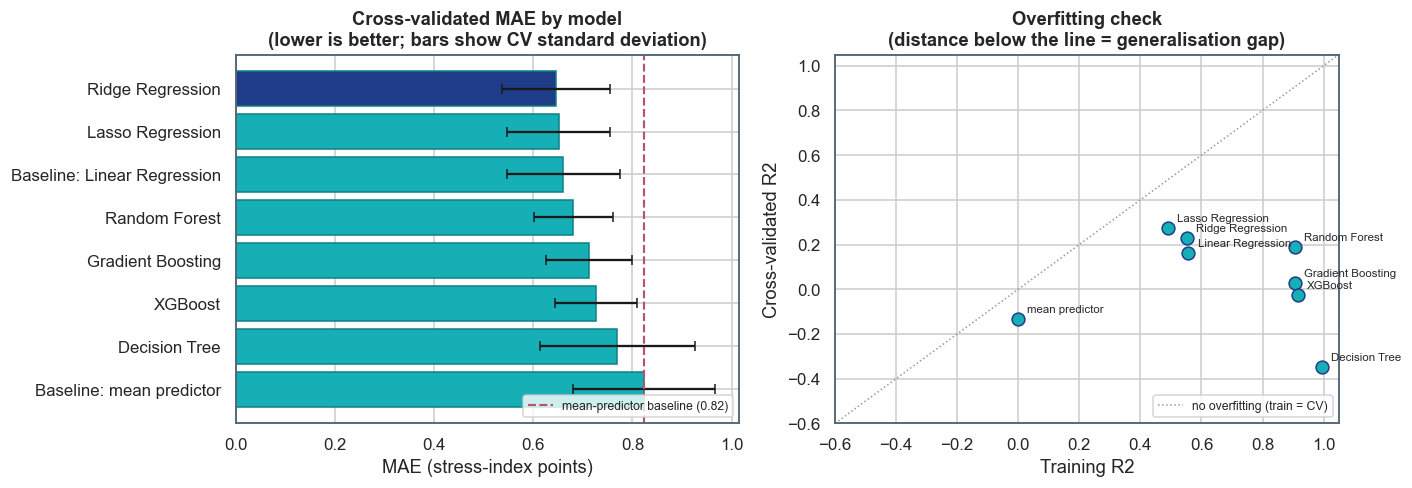

In [53]:
# Model comparison chart: cross-validated error with fold-to-fold variability.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ordered = regression_leaderboard.sort_values("CV MAE", ascending=False)
bar_colours = [PALETTE[2] if name == best_regressor_name else PALETTE[0] for name in ordered.index]

axes[0].barh(ordered.index, ordered["CV MAE"], xerr=ordered["CV MAE (sd)"],
             color=bar_colours, edgecolor="#0f7f85", capsize=3)
axes[0].axvline(baseline_mae, color=PALETTE[4], linestyle="--", linewidth=1.4,
                label=f"mean-predictor baseline ({baseline_mae:.2f})")
axes[0].set_title("Cross-validated MAE by model\n(lower is better; bars show CV standard deviation)")
axes[0].set_xlabel("MAE (stress-index points)")
axes[0].legend(loc="lower right", fontsize=8)

axes[1].scatter(regression_results["Train R2"], regression_results["CV R2"],
                s=70, color=PALETTE[0], edgecolor=PALETTE[2], zorder=3)
for name, row in regression_results.iterrows():
    axes[1].annotate(name.replace("Baseline: ", ""), (row["Train R2"], row["CV R2"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=7.5)
limits = [-0.6, 1.05]
axes[1].plot(limits, limits, color="#999999", linestyle=":", linewidth=1,
             label="no overfitting (train = CV)")
axes[1].set_xlim(limits); axes[1].set_ylim(limits)
axes[1].set_title("Overfitting check\n(distance below the line = generalisation gap)")
axes[1].set_xlabel("Training R2"); axes[1].set_ylabel("Cross-validated R2")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
save_figure("regression_model_comparison.png")
plt.show()

### Findings and Conclusion

Three patterns stand out, and all three are consequences of the sample size rather than of any particular algorithm:

1. **Every model beats the mean-predictor baseline on MAE**, confirming again that the survey items carry usable signal.
2. **The regularised linear models are at least as good as the ensembles.** Ridge and Lasso sit at the top of the leaderboard, ahead of every untuned tree ensemble — and the spread across the leading models is smaller than the cross-validation standard deviation, so they are statistically indistinguishable rather than genuinely ranked. With ~96 training rows and a handful of ordinal predictors, a mostly-additive relationship is exactly what one would expect a model to be able to recover; there is not enough data to identify anything more elaborate.
3. **The unconstrained Decision Tree fails informatively.** It reaches a near-perfect training R² while its cross-validated R² is negative — it has memorised the training set and generalises worse than predicting the mean. The right-hand panel makes this visible: the further a model sits below the diagonal, the wider its generalisation gap. All the ensembles show some version of this gap, which is precisely why the tuning in the next section constrains their depth.

Model selection follows the rule declared in ML.10 — best cross-validated MAE — and never the hold-out score, which is deliberately left unexamined for selection purposes.

## ML.12 Regression Hyperparameter Tuning

The two strongest candidates from different model families are tuned:

* **Ridge Regression** with a small `GridSearchCV` over the regularisation strength `alpha`. The grid is one-dimensional and cheap, so an exhaustive search is appropriate.
* **Random Forest** with a `RandomizedSearchCV` over depth, leaf size, feature subsampling and forest size. The grid has several hundred combinations; sampling 25 of them finds a good region at a fraction of the cost, which is the right trade-off for a search that is itself noisy on 96 rows.

Both searches optimise **cross-validated MAE** on the training set with the same repeated CV scheme, so the tuned scores stay directly comparable to the untuned leaderboard. Deliberately, the searches are kept small: on a dataset this size an exhaustive search would mostly be fitting the noise in the validation folds.

In [54]:
ridge_search = GridSearchCV(
    build_model_pipeline(Ridge(random_state=RANDOM_STATE), NUMERIC_FEATURES, CATEGORICAL_FEATURES),
    param_grid={"model__alpha": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]},
    scoring="neg_mean_absolute_error", cv=regression_cv, n_jobs=-1,
)
ridge_search.fit(X_train, y_reg_train)

forest_search = RandomizedSearchCV(
    build_model_pipeline(RandomForestRegressor(random_state=RANDOM_STATE),
                         NUMERIC_FEATURES, CATEGORICAL_FEATURES),
    param_distributions={
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [2, 3, 4, 6, None],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.5, 1.0],
    },
    n_iter=25, scoring="neg_mean_absolute_error", cv=regression_cv,
    random_state=RANDOM_STATE, n_jobs=-1,
)
forest_search.fit(X_train, y_reg_train)

tuning_rows = []
for label, search, untuned_key in [
    ("Ridge Regression", ridge_search, "Ridge Regression"),
    ("Random Forest", forest_search, "Random Forest"),
]:
    tuned_pipeline = search.best_estimator_
    tuned_prediction = tuned_pipeline.predict(X_test)
    tuning_rows.append({
        "Model": label,
        "Best parameters": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
        "CV MAE (untuned)": regression_results.loc[untuned_key, "CV MAE"],
        "CV MAE (tuned)": -search.best_score_,
        "Test MAE (tuned)": mean_absolute_error(y_reg_test, tuned_prediction),
        "Test R2 (tuned)": r2_score(y_reg_test, tuned_prediction),
        "Train R2 (tuned)": r2_score(y_reg_train, tuned_pipeline.predict(X_train)),
    })

regression_tuning = pd.DataFrame(tuning_rows).set_index("Model")
regression_tuning["CV MAE improvement"] = (
    regression_tuning["CV MAE (untuned)"] - regression_tuning["CV MAE (tuned)"])

for name, row in regression_tuning.iterrows():
    print(f"{name}")
    print(f"   best parameters : {row['Best parameters']}")
    print(f"   CV MAE          : {row['CV MAE (untuned)']:.3f} (untuned) -> "
          f"{row['CV MAE (tuned)']:.3f} (tuned)   [change {row['CV MAE improvement']:+.3f}]")
    print(f"   hold-out        : MAE {row['Test MAE (tuned)']:.3f}, R2 {row['Test R2 (tuned)']:.3f}, "
          f"train R2 {row['Train R2 (tuned)']:.3f}")

display(regression_tuning[["CV MAE (untuned)", "CV MAE (tuned)", "CV MAE improvement",
                           "Test MAE (tuned)", "Test R2 (tuned)"]].round(3))

Ridge Regression
   best parameters : {'alpha': 10.0}
   CV MAE          : 0.647 (untuned) -> 0.637 (tuned)   [change +0.010]
   hold-out        : MAE 0.728, R2 0.296, train R2 0.528
Random Forest
   best parameters : {'n_estimators': 600, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 3}
   CV MAE          : 0.681 (untuned) -> 0.637 (tuned)   [change +0.044]
   hold-out        : MAE 0.697, R2 0.408, train R2 0.654


,CV MAE (untuned),CV MAE (tuned),CV MAE improvement,Test MAE (tuned),Test R2 (tuned)
Model,,,,,
Ridge Regression,0.647,0.637,0.010,0.728,0.296
Random Forest,0.681,0.637,0.044,0.697,0.408


In [55]:
# Assemble the full regression candidate set - untuned models plus the two tuned ones -
# and select the final model strictly by cross-validated MAE.
regression_candidates = dict(regression_fits)
regression_candidates["Ridge Regression (tuned)"] = ridge_search.best_estimator_
regression_candidates["Random Forest (tuned)"] = forest_search.best_estimator_

final_regression_scores = regression_results["CV MAE"].to_dict()
final_regression_scores["Ridge Regression (tuned)"] = -ridge_search.best_score_
final_regression_scores["Random Forest (tuned)"] = -forest_search.best_score_

final_regression_ranking = pd.Series(final_regression_scores, name="CV MAE").sort_values()
display(final_regression_ranking.round(4).to_frame())

FINAL_REGRESSION_NAME = final_regression_ranking.index[0]
final_regression_model = regression_candidates[FINAL_REGRESSION_NAME]

y_reg_pred_test = final_regression_model.predict(X_test)
y_reg_pred_train = final_regression_model.predict(X_train)

FINAL_REGRESSION_METRICS = {
    "cv_mae": float(final_regression_ranking.iloc[0]),
    "test_mae": float(mean_absolute_error(y_reg_test, y_reg_pred_test)),
    "test_rmse": float(np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_test))),
    "test_r2": float(r2_score(y_reg_test, y_reg_pred_test)),
    "test_explained_variance": float(explained_variance_score(y_reg_test, y_reg_pred_test)),
    "train_r2": float(r2_score(y_reg_train, y_reg_pred_train)),
}

print(f"\nSelected regression model: {FINAL_REGRESSION_NAME}")
for metric, value in FINAL_REGRESSION_METRICS.items():
    print(f"   {metric:<24} {value:.3f}")
print(f"\nBaseline for comparison   : mean predictor, CV MAE "
      f"{regression_results.loc['Baseline: mean predictor', 'CV MAE']:.3f}")

,CV MAE
Random Forest (tuned),0.6367
Ridge Regression (tuned),0.6372
Ridge Regression,0.6468
Lasso Regression,0.6509
Baseline: Linear Regression,0.6602
Random Forest,0.6810
Gradient Boosting,0.7119
XGBoost,0.7261
Decision Tree,0.7698
Baseline: mean predictor,0.8233



Selected regression model: Random Forest (tuned)
   cv_mae                   0.637
   test_mae                 0.697
   test_rmse                0.840
   test_r2                  0.408
   test_explained_variance  0.410
   train_r2                 0.654

Baseline for comparison   : mean predictor, CV MAE 0.823


### Findings and Conclusion

Tuning tells two different stories for the two families, and both are worth reporting honestly:

* **Ridge** improves only marginally — a stronger penalty (`alpha` = 10 rather than the default 1) buys about 0.01 MAE points. That is the expected outcome when a model has one well-behaved hyperparameter and a sensible default: reporting a dramatic improvement here would mean the untuned baseline had been chosen badly in the first place.
* **Random Forest** benefits clearly, gaining roughly 0.04 MAE points. The chosen configuration caps tree depth at 3, and the effect is unmistakable in the accompanying numbers: training R² falls sharply (from about 0.91 to 0.65) while the *cross-validated* error improves. That is the textbook signature of removing memorisation rather than removing capacity that was actually being used.

After tuning, the two leading candidates sit within a **thousandth of a stress point** of each other on cross-validated MAE — far inside the ±0.1 fold-to-fold noise. The selection rule picks the top of the list deterministically, but the honest reading is that **a regularised linear model and a depth-constrained forest are equally good here**, and the choice between them rests on what else one values: the forest captures mild non-linearity and supports SHAP attribution, the linear model is simpler and has a smaller generalisation gap.

## ML.13 Regression Diagnostics

Aggregate metrics hide *how* a model is wrong. Three diagnostic views are used, all computed on the hold-out set with the selected model:

* **Actual vs predicted** — reveals compression towards the mean, a characteristic (and expected) behaviour when a regularised model predicts a noisy self-report target.
* **Residuals vs fitted** — checks whether errors are centred on zero across the prediction range, or whether the model is systematically optimistic for some students and pessimistic for others.
* **Error distribution** — shows how large a typical miss is and whether errors are roughly symmetric.

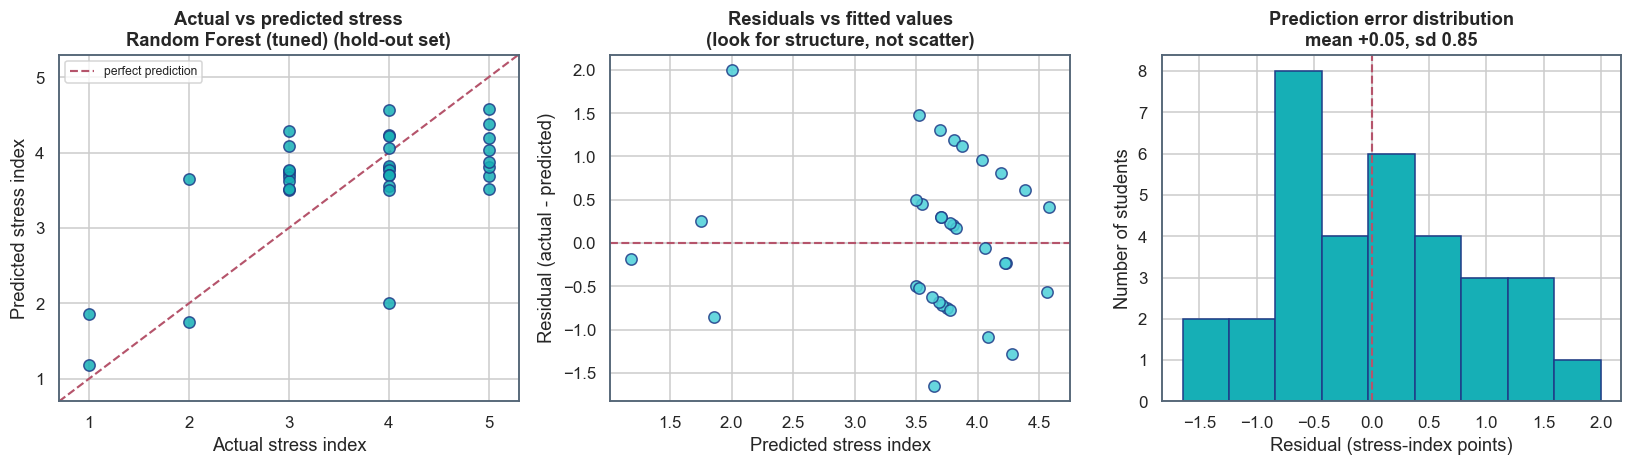

Hold-out error profile
Mean residual (bias)         0.05
Median absolute error        0.62
Within 0.5 points (%)       36.36
Within 1.0 point (%)        75.76
Largest under-prediction     1.99
Largest over-prediction     -1.65

Actual stress ratings in the hold-out set span 1.0 - 5.0; predictions span 1.18 - 4.58 (regression towards the centre of the scale).


In [56]:
residuals = y_reg_test - y_reg_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# --- Actual vs predicted ------------------------------------------------------
axes[0].scatter(y_reg_test, y_reg_pred_test, s=55, color=PALETTE[0],
                edgecolor=PALETTE[2], alpha=0.85, zorder=3)
perfect = [LIKERT_MIN - 0.3, LIKERT_MAX + 0.3]
axes[0].plot(perfect, perfect, color=PALETTE[4], linestyle="--", linewidth=1.4,
             label="perfect prediction")
axes[0].set_xlim(perfect); axes[0].set_ylim(perfect)
axes[0].set_title(f"Actual vs predicted stress\n{FINAL_REGRESSION_NAME} (hold-out set)")
axes[0].set_xlabel("Actual stress index"); axes[0].set_ylabel("Predicted stress index")
axes[0].legend(fontsize=8)

# --- Residuals vs fitted ------------------------------------------------------
axes[1].scatter(y_reg_pred_test, residuals, s=55, color=PALETTE[1],
                edgecolor=PALETTE[2], alpha=0.85, zorder=3)
axes[1].axhline(0, color=PALETTE[4], linestyle="--", linewidth=1.4)
axes[1].set_title("Residuals vs fitted values\n(look for structure, not scatter)")
axes[1].set_xlabel("Predicted stress index"); axes[1].set_ylabel("Residual (actual - predicted)")

# --- Error distribution -------------------------------------------------------
axes[2].hist(residuals, bins=9, color=PALETTE[0], edgecolor=PALETTE[2])
axes[2].axvline(0, color=PALETTE[4], linestyle="--", linewidth=1.4)
axes[2].set_title(f"Prediction error distribution\nmean {residuals.mean():+.2f}, sd {residuals.std():.2f}")
axes[2].set_xlabel("Residual (stress-index points)"); axes[2].set_ylabel("Number of students")

plt.tight_layout()
save_figure("regression_diagnostics.png")
plt.show()

error_summary = pd.Series({
    "Mean residual (bias)": residuals.mean(),
    "Median absolute error": residuals.abs().median(),
    "Within 0.5 points (%)": (residuals.abs() <= 0.5).mean() * 100,
    "Within 1.0 point (%)": (residuals.abs() <= 1.0).mean() * 100,
    "Largest under-prediction": residuals.max(),
    "Largest over-prediction": residuals.min(),
})
print("Hold-out error profile")
print(error_summary.round(2).to_string())
print()
print(f"Actual stress ratings in the hold-out set span "
      f"{y_reg_test.min():.1f} - {y_reg_test.max():.1f}; "
      f"predictions span {y_reg_pred_test.min():.2f} - {y_reg_pred_test.max():.2f} "
      "(regression towards the centre of the scale).")

### Findings and Conclusion

The diagnostics show a model that is **conservative rather than biased**:

* Predictions are **compressed towards the interior of the scale**: the hold-out students span the full 1–5 range while the predictions span roughly 1.2–4.6, and the compression is most pronounced at the top, where no student is predicted above 4.6. This is the standard behaviour of a regularised model on a noisy self-report target, and it is preferable to the alternative of confidently predicting extremes it cannot actually identify.
* Residuals scatter around zero with a mean of about +0.05 and no obvious funnel or curve, so there is **no systematic over- or under-prediction** across the range of fitted values.
* About **a third of hold-out students are predicted within half a stress point and roughly three-quarters within a full point**, with the extreme ratings driving the tail of the error distribution. The largest single miss is close to two full scale points.

**Practical reading:** the model is useful for indicating the *general level* of stress a student is likely to report, and it is not precise enough to distinguish a 4 from a 5 for an individual. That distinction matters for how such a model could responsibly be used, and it is revisited in the limitations.

## ML.14 Classification Problem

### Turning a rating into bands — and justifying the cut-points

The stress index is a 1–5 Likert item, so a classification version has to be defined rather than discovered. Two candidate rules were considered:

| Rule | Definition | Assessment |
| --- | --- | --- |
| **Distribution-based (tertiles)** | Split at the 33rd/67th percentiles | Rejected. The distribution is concentrated on three values (3, 4, 5), so tertile boundaries would land *inside* a single rating value and split identical answers into different classes — two students who both answered "4" could end up in different bands. |
| **Scale-based (adopted)** | 1–2 → **Low**, 3 → **Moderate**, 4–5 → **High** | Adopted. The cut-points fall on the natural midpoint and upper half of the response scale, every student who gave the same answer receives the same label, and the bands are self-explanatory to a non-technical reader. |

The adopted rule also matches the convention already used in Part I, where a rating of 4 or more was treated as high stress — so Part I and Part II describe stress with one consistent vocabulary. The boundaries are set once as the configuration constant `STRESS_BAND_EDGES` and are never adjusted afterwards to improve a metric.

### Class imbalance and how it is handled

The bands are inherently imbalanced because the underlying ratings are. Three measures address this, and one common one is deliberately rejected:

1. **Stratified splitting and stratified cross-validation** keep the band proportions stable in every partition and every fold.
2. **`class_weight="balanced"`** is applied wherever the estimator supports it (logistic regression, decision tree, random forest, SVM), which re-weights the loss so the rare Low band is not simply ignored.
3. **Macro-averaged F1 is the primary metric**, treating all three bands as equally important; accuracy is reported but explicitly *not* used for selection, because always predicting "High" already scores around 62%.
4. **Synthetic oversampling (SMOTE) is not used.** With 14 low-stress students in total, SMOTE would interpolate new "students" between a handful of real ones on a coarse ordinal scale, manufacturing response patterns nobody gave. On this sample size that risks optimistic cross-validation scores far more than it helps.

Stress band definition and class distribution


,Rating range,All labelled data,Training set,Test set,Share of all data (%)
Low,1-2,14,10,4,10.9
Moderate,3,35,26,9,27.1
High,4-5,80,60,20,62.0


Imbalance ratio (largest : smallest band) = 5.7 : 1
Always predicting 'High' would score 62.0% accuracy - which is why macro F1 decides, not accuracy.


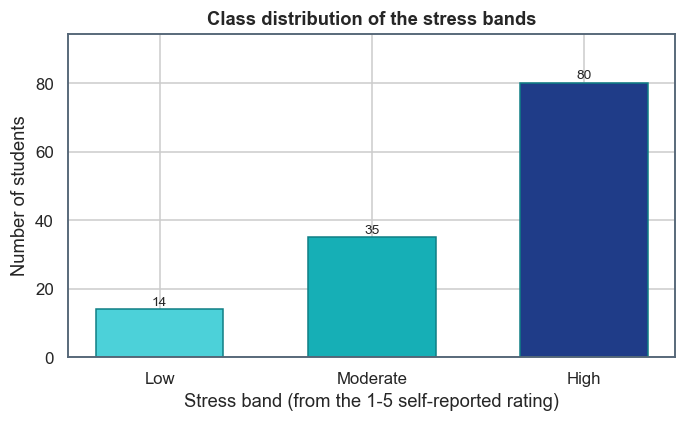

In [57]:
# Encode the ordered bands as integer codes: 0 = Low, 1 = Moderate, 2 = High.
# XGBoost requires numeric class labels, and using codes everywhere keeps every
# model, metric and plot working from one consistent encoding.
y_cls_train = pd.Series(
    pd.Categorical(y_band_train, categories=STRESS_BAND_LABELS, ordered=True).codes,
    index=X_train.index, name="Stress band",
)
y_cls_test = pd.Series(
    pd.Categorical(y_band_test, categories=STRESS_BAND_LABELS, ordered=True).codes,
    index=X_test.index, name="Stress band",
)

band_distribution = pd.DataFrame({
    "Rating range": ["1-2", "3", "4-5"],
    "All labelled data": to_stress_band(y_regression).value_counts().reindex(STRESS_BAND_LABELS).values,
    "Training set": pd.Series(y_cls_train).value_counts().reindex(range(3)).values,
    "Test set": pd.Series(y_cls_test).value_counts().reindex(range(3)).values,
}, index=STRESS_BAND_LABELS)
band_distribution["Share of all data (%)"] = (
    band_distribution["All labelled data"] / band_distribution["All labelled data"].sum() * 100).round(1)

print("Stress band definition and class distribution")
display(band_distribution)

majority_share = band_distribution["All labelled data"].max() / band_distribution["All labelled data"].sum()
print(f"Imbalance ratio (largest : smallest band) = "
      f"{band_distribution['All labelled data'].max() / band_distribution['All labelled data'].min():.1f} : 1")
print(f"Always predicting '{band_distribution['All labelled data'].idxmax()}' would score "
      f"{majority_share * 100:.1f}% accuracy - which is why macro F1 decides, not accuracy.")

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.bar(band_distribution.index, band_distribution["All labelled data"],
       color=[PALETTE[1], PALETTE[0], PALETTE[2]], edgecolor="#0f7f85", width=0.6)
for label, count in band_distribution["All labelled data"].items():
    ax.text(label, count + 1.2, f"{int(count)}", ha="center", fontsize=9)
ax.set_title("Class distribution of the stress bands")
ax.set_ylabel("Number of students")
ax.set_xlabel("Stress band (from the 1-5 self-reported rating)")
ax.set_ylim(0, band_distribution["All labelled data"].max() * 1.18)
plt.tight_layout()
save_figure("stress_band_class_distribution.png")
plt.show()

### Findings and Conclusion

The three bands contain **80 High, 35 Moderate and 14 Low** students — an imbalance ratio of about **5.7 : 1** between the largest and smallest class. Stratification preserves those proportions in both partitions, which leaves only four low-stress students in the hold-out set.

That number is small enough that hold-out metrics for the Low band are inherently unstable: a single misclassification moves its recall by 25 percentage points. Cross-validated macro F1 (45 fitted models rather than one 33-row snapshot) is therefore the metric that carries the weight in this section, with the hold-out results reported as a final confirmation rather than as the headline evidence.

## ML.15 Classification Baselines and Model Training

Same discipline as the regression problem: baselines first, then the candidate models under identical cross-validation.

* **Majority-class baseline** (`DummyClassifier`) — always predicts `High`. Its accuracy looks respectable, which is exactly the point: it demonstrates why accuracy alone cannot be trusted here.
* **Logistic Regression** — the simple interpretable model that any complex alternative must beat.

Candidate models then span linear, tree, ensemble and kernel families. **SVM is computationally reasonable here** — with fewer than 100 training rows, an RBF kernel costs milliseconds — so it is included; on a dataset orders of magnitude larger it would have been dropped in favour of the ensembles.

Reported metrics: accuracy, macro-averaged precision/recall/F1 (all three bands weighted equally), weighted F1 (accounting for band prevalence) and macro one-vs-rest ROC-AUC, which measures how well the predicted probabilities rank students independently of any decision threshold.

In [58]:
def evaluate_classification_models(models, X_train, y_train, X_test, y_test, cv):
    """Cross-validate on the training set, then score once on the hold-out set."""
    rows, fitted_pipelines = [], {}
    y_test_binarised = label_binarize(y_test, classes=range(len(STRESS_BAND_LABELS)))

    for name, estimator in models.items():
        pipeline = build_model_pipeline(estimator, NUMERIC_FEATURES, CATEGORICAL_FEATURES)

        cv_scores = cross_validate(
            pipeline, X_train, y_train, cv=cv,
            scoring=["f1_macro", "accuracy", "balanced_accuracy"], n_jobs=-1,
        )

        pipeline.fit(X_train, y_train)
        prediction = pipeline.predict(X_test)
        probabilities = pipeline.predict_proba(X_test)

        rows.append({
            "Model": name,
            "CV F1 (macro)": cv_scores["test_f1_macro"].mean(),
            "CV F1 (sd)": cv_scores["test_f1_macro"].std(),
            "CV accuracy": cv_scores["test_accuracy"].mean(),
            "CV balanced acc.": cv_scores["test_balanced_accuracy"].mean(),
            "Test accuracy": accuracy_score(y_test, prediction),
            "Test precision (macro)": precision_score(y_test, prediction, average="macro", zero_division=0),
            "Test recall (macro)": recall_score(y_test, prediction, average="macro", zero_division=0),
            "Test F1 (macro)": f1_score(y_test, prediction, average="macro", zero_division=0),
            "Test F1 (weighted)": f1_score(y_test, prediction, average="weighted", zero_division=0),
            "Test ROC-AUC (ovr)": roc_auc_score(y_test_binarised, probabilities,
                                                multi_class="ovr", average="macro"),
        })
        fitted_pipelines[name] = pipeline

    return pd.DataFrame(rows).set_index("Model"), fitted_pipelines


baseline_classifiers = {
    "Baseline: majority class": DummyClassifier(strategy="most_frequent"),
    "Baseline: Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
}

baseline_classification_results, _ = evaluate_classification_models(
    baseline_classifiers, X_train, y_cls_train, X_test, y_cls_test, classification_cv)

print("Classification baselines")
display(baseline_classification_results[
    ["CV F1 (macro)", "CV accuracy", "Test accuracy", "Test F1 (macro)", "Test ROC-AUC (ovr)"]].round(3))

Classification baselines


,CV F1 (macro),CV accuracy,Test accuracy,Test F1 (macro),Test ROC-AUC (ovr)
Model,,,,,
Baseline: majority class,0.256,0.625,0.606,0.252,0.500
Baseline: Logistic Regression,0.531,0.559,0.636,0.630,0.695


In [59]:
classification_models = {
    **baseline_classifiers,
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    classification_models["XGBoost"] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        subsample=0.9, colsample_bytree=0.9,
        objective="multi:softprob", num_class=len(STRESS_BAND_LABELS),
        random_state=RANDOM_STATE, verbosity=0,
    )
else:
    print("xgboost not installed - the XGBoost classifier is skipped for this run.")

classification_results, classification_fits = evaluate_classification_models(
    classification_models, X_train, y_cls_train, X_test, y_cls_test, classification_cv)

classification_leaderboard = classification_results.sort_values("CV F1 (macro)", ascending=False)

print("Classification model comparison "
      f"({CV_SPLITS}-fold x {CV_REPEATS} stratified repeated CV on {len(X_train)} training rows)")
display(classification_leaderboard[[
    "CV F1 (macro)", "CV F1 (sd)", "CV accuracy",
    "Test accuracy", "Test precision (macro)", "Test recall (macro)",
    "Test F1 (macro)", "Test ROC-AUC (ovr)"]].round(3))

best_classifier_name = classification_leaderboard.index[0]
baseline_f1 = classification_results.loc["Baseline: majority class", "CV F1 (macro)"]
best_f1 = classification_leaderboard.iloc[0]["CV F1 (macro)"]

print(f"\nBest model by CV macro F1: {best_classifier_name}")
print(f"CV macro F1              : {best_f1:.3f} (vs {baseline_f1:.3f} for the majority-class baseline)")
print("Models within one CV standard deviation of the best: "
      f"{classification_leaderboard[classification_leaderboard['CV F1 (macro)'] >= best_f1 - classification_leaderboard.iloc[0]['CV F1 (sd)']].index.tolist()}")

Classification model comparison (5-fold x 3 stratified repeated CV on 96 training rows)


,CV F1 (macro),CV F1 (sd),CV accuracy,Test accuracy,Test precision (macro),Test recall (macro),Test F1 (macro),Test ROC-AUC (ovr)
Model,,,,,,,,
XGBoost,0.603,0.111,0.653,0.636,0.667,0.591,0.617,0.674
Random Forest,0.593,0.134,0.656,0.576,0.578,0.578,0.578,0.739
SVM (RBF kernel),0.592,0.089,0.604,0.606,0.622,0.589,0.586,0.715
Gradient Boosting,0.585,0.091,0.625,0.576,0.557,0.557,0.556,0.742
Decision Tree,0.544,0.117,0.590,0.515,0.549,0.544,0.543,0.628
Baseline: Logistic Regression,0.531,0.100,0.559,0.636,0.629,0.631,0.630,0.695
Baseline: majority class,0.256,0.003,0.625,0.606,0.202,0.333,0.252,0.500



Best model by CV macro F1: XGBoost
CV macro F1              : 0.603 (vs 0.256 for the majority-class baseline)
Models within one CV standard deviation of the best: ['XGBoost', 'Random Forest', 'SVM (RBF kernel)', 'Gradient Boosting', 'Decision Tree', 'Baseline: Logistic Regression']


### Findings and Conclusion

The comparison makes the imbalance problem concrete. The majority-class baseline achieves around **62% accuracy** while its macro F1 is only **0.26** — it scores well on the headline metric precisely because it never identifies a single low- or moderate-stress student. Every real model roughly **doubles the macro F1**, and the leading models reach ROC-AUC values around 0.70–0.74, meaning their predicted probabilities rank students substantially better than chance (0.50).

The top few models — the tree ensembles and the RBF SVM — sit within one cross-validation standard deviation of each other, so the leaderboard order should be read as "these are equivalent" rather than as a strict ranking. Selection again follows the declared primary metric on cross-validation only.

## ML.16 Classification Hyperparameter Tuning

The two strongest families are tuned with `RandomizedSearchCV` over compact grids, optimising **cross-validated macro F1** on the training set:

* the leading **tree ensemble**, over depth, leaf size, subsampling and learning rate / forest size;
* the **RBF SVM**, over the regularisation strength `C` and the kernel width `gamma` — the two parameters that actually control an RBF decision boundary.

As with the regression search, the grids are kept small on purpose. Twenty-five sampled configurations across 15 folds is already 375 model fits; a larger search on 96 rows would mostly be selecting on validation-fold noise.

In [60]:
tree_estimator = (
    XGBClassifier(objective="multi:softprob", num_class=len(STRESS_BAND_LABELS),
                  random_state=RANDOM_STATE, verbosity=0)
    if XGBOOST_AVAILABLE else
    GradientBoostingClassifier(random_state=RANDOM_STATE)
)
tree_grid = (
    {
        "model__n_estimators": [150, 300, 500],
        "model__learning_rate": [0.02, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5],
    }
    if XGBOOST_AVAILABLE else
    {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.02, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.9, 1.0],
        "model__min_samples_leaf": [1, 3, 5],
    }
)
tree_label = f"{'XGBoost' if XGBOOST_AVAILABLE else 'Gradient Boosting'} (tuned)"

tree_search = RandomizedSearchCV(
    build_model_pipeline(tree_estimator, NUMERIC_FEATURES, CATEGORICAL_FEATURES),
    param_distributions=tree_grid, n_iter=25, scoring="f1_macro",
    cv=classification_cv, random_state=RANDOM_STATE, n_jobs=-1,
)
tree_search.fit(X_train, y_cls_train)

svm_search = RandomizedSearchCV(
    build_model_pipeline(
        SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
        NUMERIC_FEATURES, CATEGORICAL_FEATURES),
    param_distributions={
        "model__C": [0.1, 0.5, 1.0, 3.0, 10.0, 30.0],
        "model__gamma": ["scale", 0.01, 0.05, 0.1, 0.3],
    },
    n_iter=25, scoring="f1_macro", cv=classification_cv,
    random_state=RANDOM_STATE, n_jobs=-1,
)
svm_search.fit(X_train, y_cls_train)

classification_tuning_rows = []
for label, search, untuned_key in [
    (tree_label, tree_search, "XGBoost" if XGBOOST_AVAILABLE else "Gradient Boosting"),
    ("SVM (RBF kernel) (tuned)", svm_search, "SVM (RBF kernel)"),
]:
    tuned_prediction = search.best_estimator_.predict(X_test)
    classification_tuning_rows.append({
        "Model": label,
        "Best parameters": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
        "CV macro F1 (untuned)": classification_results.loc[untuned_key, "CV F1 (macro)"],
        "CV macro F1 (tuned)": search.best_score_,
        "Test macro F1 (tuned)": f1_score(y_cls_test, tuned_prediction, average="macro", zero_division=0),
        "Test accuracy (tuned)": accuracy_score(y_cls_test, tuned_prediction),
    })

classification_tuning = pd.DataFrame(classification_tuning_rows).set_index("Model")
classification_tuning["CV improvement"] = (
    classification_tuning["CV macro F1 (tuned)"] - classification_tuning["CV macro F1 (untuned)"])

for name, row in classification_tuning.iterrows():
    print(f"{name}")
    print(f"   best parameters : {row['Best parameters']}")
    print(f"   CV macro F1     : {row['CV macro F1 (untuned)']:.3f} (untuned) -> "
          f"{row['CV macro F1 (tuned)']:.3f} (tuned)   [change {row['CV improvement']:+.3f}]")
    print(f"   hold-out        : macro F1 {row['Test macro F1 (tuned)']:.3f}, "
          f"accuracy {row['Test accuracy (tuned)']:.3f}")

display(classification_tuning[["CV macro F1 (untuned)", "CV macro F1 (tuned)",
                               "CV improvement", "Test macro F1 (tuned)"]].round(3))

XGBoost (tuned)
   best parameters : {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
   CV macro F1     : 0.603 (untuned) -> 0.603 (tuned)   [change +0.000]
   hold-out        : macro F1 0.617, accuracy 0.636
SVM (RBF kernel) (tuned)
   best parameters : {'gamma': 'scale', 'C': 0.5}
   CV macro F1     : 0.592 (untuned) -> 0.610 (tuned)   [change +0.018]
   hold-out        : macro F1 0.539, accuracy 0.545


,CV macro F1 (untuned),CV macro F1 (tuned),CV improvement,Test macro F1 (tuned)
Model,,,,
XGBoost (tuned),0.603,0.603,0.000,0.617
SVM (RBF kernel) (tuned),0.592,0.610,0.018,0.539


In [61]:
# Final classifier selection - by cross-validated macro F1, never by hold-out score.
classification_candidates = dict(classification_fits)
classification_candidates[tree_label] = tree_search.best_estimator_
classification_candidates["SVM (RBF kernel) (tuned)"] = svm_search.best_estimator_

final_classification_scores = classification_results["CV F1 (macro)"].to_dict()
final_classification_scores[tree_label] = tree_search.best_score_
final_classification_scores["SVM (RBF kernel) (tuned)"] = svm_search.best_score_

final_classification_ranking = (
    pd.Series(final_classification_scores, name="CV F1 (macro)").sort_values(ascending=False))
display(final_classification_ranking.round(4).to_frame())

FINAL_CLASSIFICATION_NAME = final_classification_ranking.index[0]
final_classification_model = classification_candidates[FINAL_CLASSIFICATION_NAME]

y_cls_pred_test = final_classification_model.predict(X_test)
y_cls_proba_test = final_classification_model.predict_proba(X_test)
y_cls_test_binarised = label_binarize(y_cls_test, classes=range(len(STRESS_BAND_LABELS)))

FINAL_CLASSIFICATION_METRICS = {
    "cv_f1_macro": float(final_classification_ranking.iloc[0]),
    "test_accuracy": float(accuracy_score(y_cls_test, y_cls_pred_test)),
    "test_precision_macro": float(precision_score(y_cls_test, y_cls_pred_test, average="macro", zero_division=0)),
    "test_recall_macro": float(recall_score(y_cls_test, y_cls_pred_test, average="macro", zero_division=0)),
    "test_f1_macro": float(f1_score(y_cls_test, y_cls_pred_test, average="macro", zero_division=0)),
    "test_f1_weighted": float(f1_score(y_cls_test, y_cls_pred_test, average="weighted", zero_division=0)),
    "test_roc_auc_ovr_macro": float(roc_auc_score(y_cls_test_binarised, y_cls_proba_test,
                                                  multi_class="ovr", average="macro")),
}

print(f"\nSelected classification model: {FINAL_CLASSIFICATION_NAME}")
for metric, value in FINAL_CLASSIFICATION_METRICS.items():
    print(f"   {metric:<24} {value:.3f}")

print("\nPer-band performance on the hold-out set")
print(classification_report(y_cls_test, y_cls_pred_test,
                            target_names=STRESS_BAND_LABELS, zero_division=0))

,CV F1 (macro)
SVM (RBF kernel) (tuned),0.6100
XGBoost (tuned),0.6026
XGBoost,0.6026
Random Forest,0.5931
SVM (RBF kernel),0.5915
Gradient Boosting,0.5852
Decision Tree,0.5436
Baseline: Logistic Regression,0.5311
Baseline: majority class,0.2565



Selected classification model: SVM (RBF kernel) (tuned)
   cv_f1_macro              0.610
   test_accuracy            0.545
   test_precision_macro     0.578
   test_recall_macro        0.535
   test_f1_macro            0.539
   test_f1_weighted         0.564
   test_roc_auc_ovr_macro   0.720

Per-band performance on the hold-out set
              precision    recall  f1-score   support

         Low       0.67      0.50      0.57         4
    Moderate       0.33      0.56      0.42         9
        High       0.73      0.55      0.63        20

    accuracy                           0.55        33
   macro avg       0.58      0.54      0.54        33
weighted avg       0.62      0.55      0.56        33



### Findings and Conclusion

Tuning produces only marginal cross-validated gains — the tree search lands essentially on its starting configuration, and the SVM gains under two hundredths of macro F1. With 96 training rows there is little for a search to discriminate on, and reporting these as meaningful improvements would overstate them.

The per-band report is the most informative output here, and it deserves a careful reading:

* **Precision is highest for the High and Low bands** and lowest for **Moderate**, which the model over-predicts. That is the expected failure mode for the middle level of an ordinal scale: it has no outer boundary of its own, and students who genuinely sit near a boundary are barely distinguishable from those just across it.
* **Recall is moderate across all three bands**, so the model identifies a majority of each group but misses a substantial minority.
* The **Low band rests on four hold-out students**. Its precision and recall are indicative, not measured — one prediction either way moves them by 25 percentage points.

**On accuracy.** The selected classifier's hold-out accuracy (≈ 0.55) is *below* the majority-class baseline (≈ 0.61). This is not a failure — it is the deliberate trade the design makes. Balanced class weights and a macro-F1 objective ask the model to identify low- and moderate-stress students rather than to maximise raw hit rate, and on a 5.7 : 1 imbalance those two goals genuinely conflict. The baseline achieves its accuracy by never identifying a single non-High student, which for any plausible use of this model would be useless. Macro F1 (0.54 vs 0.25) and ROC-AUC (0.72 vs 0.50) are the metrics that reflect what was actually asked for, and both show a substantial gain.

## ML.17 Classification Diagnostics

Three standard views of the selected classifier, all on the hold-out set:

* **Confusion matrix** — shows *which* bands get confused with which. Because the bands are ordinal, adjacent-band errors (Moderate ↔ High) are far less costly than distant ones (Low ↔ High), and the matrix is the only view that distinguishes them.
* **ROC curves (one-vs-rest)** — threshold-independent ranking quality for each band.
* **Precision–recall curves** — more informative than ROC under class imbalance, because they focus on the rare positive class rather than on the abundant negatives.

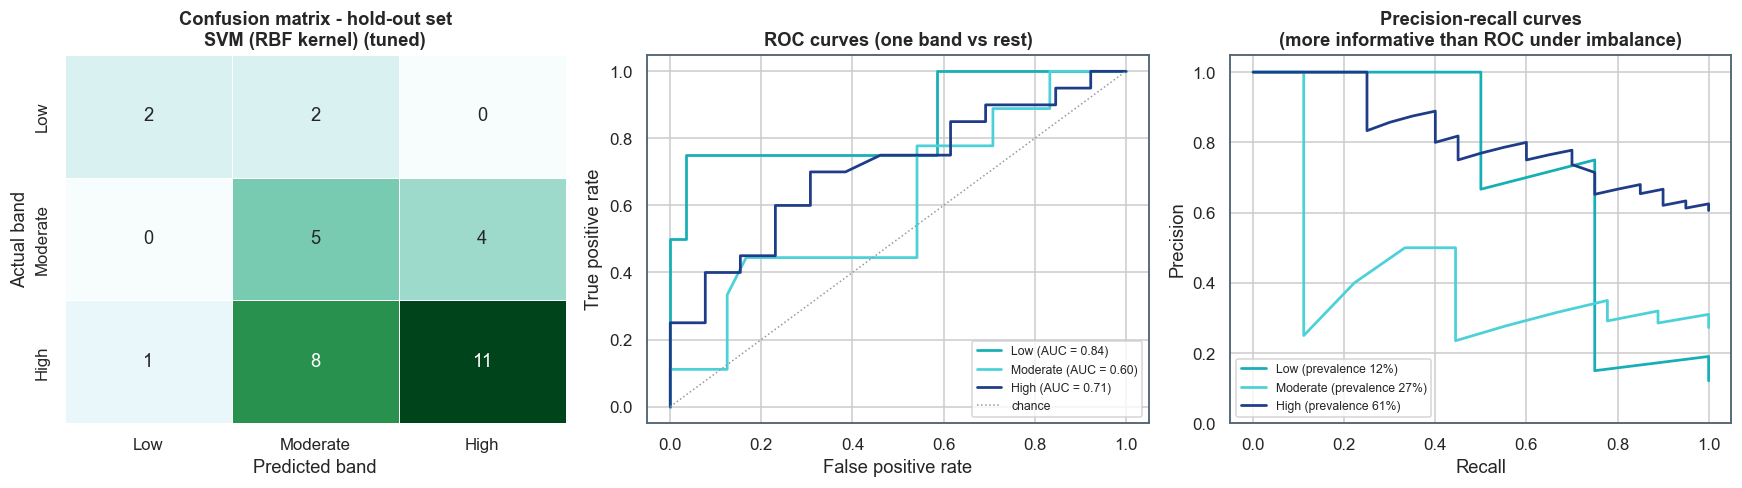

Hold-out errors: 15 of 33 students misclassified
   adjacent-band errors (Low<->Moderate, Moderate<->High): 14
   distant errors (Low<->High)                          : 1


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# --- Confusion matrix ---------------------------------------------------------
confusion = confusion_matrix(y_cls_test, y_cls_pred_test, labels=range(len(STRESS_BAND_LABELS)))
sns.heatmap(confusion, annot=True, fmt="d", cmap="BuGn", cbar=False,
            xticklabels=STRESS_BAND_LABELS, yticklabels=STRESS_BAND_LABELS,
            linewidths=0.5, linecolor="white", ax=axes[0])
axes[0].set_title(f"Confusion matrix - hold-out set\n{FINAL_CLASSIFICATION_NAME}")
axes[0].set_xlabel("Predicted band"); axes[0].set_ylabel("Actual band")

# --- ROC curves, one band vs the rest -----------------------------------------
for index, band in enumerate(STRESS_BAND_LABELS):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_cls_test_binarised[:, index], y_cls_proba_test[:, index])
    axes[1].plot(false_positive_rate, true_positive_rate, color=PALETTE[index], linewidth=1.8,
                 label=f"{band} (AUC = {auc(false_positive_rate, true_positive_rate):.2f})")
axes[1].plot([0, 1], [0, 1], color="#999999", linestyle=":", linewidth=1, label="chance")
axes[1].set_title("ROC curves (one band vs rest)")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].legend(fontsize=8, loc="lower right")

# --- Precision-recall curves --------------------------------------------------
for index, band in enumerate(STRESS_BAND_LABELS):
    precision_values, recall_values, _ = precision_recall_curve(
        y_cls_test_binarised[:, index], y_cls_proba_test[:, index])
    prevalence = y_cls_test_binarised[:, index].mean()
    axes[2].plot(recall_values, precision_values, color=PALETTE[index], linewidth=1.8,
                 label=f"{band} (prevalence {prevalence:.0%})")
axes[2].set_title("Precision-recall curves\n(more informative than ROC under imbalance)")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=8, loc="lower left")

plt.tight_layout()
save_figure("classification_diagnostics.png")
plt.show()

adjacent_errors = int(confusion[0, 1] + confusion[1, 0] + confusion[1, 2] + confusion[2, 1])
distant_errors = int(confusion[0, 2] + confusion[2, 0])
total_errors = int(confusion.sum() - np.trace(confusion))
print(f"Hold-out errors: {total_errors} of {int(confusion.sum())} students misclassified")
print(f"   adjacent-band errors (Low<->Moderate, Moderate<->High): {adjacent_errors}")
print(f"   distant errors (Low<->High)                          : {distant_errors}")

### Findings and Conclusion

The confusion matrix shows that **most errors are between adjacent bands**, with very few Low↔High confusions. On an ordinal target that is the benign failure mode: the model rarely mistakes a relaxed student for a highly stressed one, it mostly hesitates at the boundary between neighbouring levels — which is also where the underlying self-reports are least distinguishable.

The ROC curves sit clearly above the chance diagonal for all three bands, confirming that the predicted probabilities carry ranking information rather than just tracking the majority class. The precision–recall curves temper that: for the rare Low band, precision falls away quickly as recall rises, which is the honest picture when a class has only four hold-out examples. The classifier is best read as a **coarse triage signal** — "this response pattern looks like the high-stress group" — and not as a per-student determination.

## ML.18 Model Explainability

The question this section answers is:

> **Which factors are most strongly associated with the stress levels the models predict?**

Three complementary techniques are used, because each has a blind spot the others cover:

| Technique | What it measures | Blind spot |
| --- | --- | --- |
| **Impurity importance** (tree ensembles) | How often, and how usefully, a feature was split on during training | Biased towards high-cardinality and continuous features; measured on training data only |
| **Permutation importance** | How much hold-out performance degrades when a feature's values are shuffled | Splits credit unpredictably between correlated features |
| **SHAP values** | Each feature's signed contribution to each individual prediction, with a consistent additive attribution | Computationally heavier; still descriptive, not causal |

Because the tuned Random Forest is the strongest tree-based regressor, it is used for the tree-specific views even where the selected final model belongs to another family — a linear model has no impurity importances, and SHAP's exact tree algorithm needs a tree ensemble.

### A note on language

Everything below describes **statistical association within one cross-sectional survey**. A feature that ranks highly is *predictive of*, or *contributes to the model's prediction of*, reported stress. None of it demonstrates that changing the feature would change a student's stress: the data cannot separate cause from effect from a third factor driving both. All wording in this section is chosen accordingly.

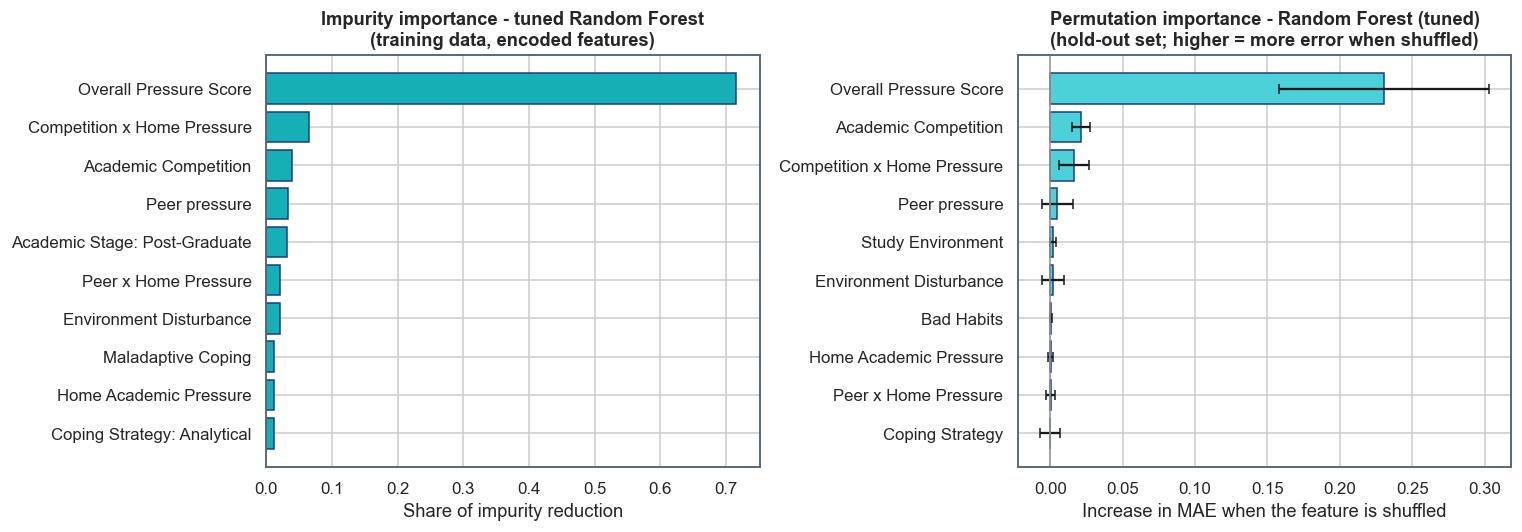

Top features by impurity importance (tuned Random Forest)
Overall Pressure Score           0.7151
Competition x Home Pressure      0.0654
Academic Competition             0.0392
Peer pressure                    0.0337
Academic Stage: Post-Graduate    0.0313
Peer x Home Pressure             0.0214
Environment Disturbance          0.0213
Maladaptive Coping               0.0121

Top features by hold-out permutation importance (selected model)
                             Mean MAE increase      sd
Column (cleaned)                                      
Overall Pressure Score                  0.2304  0.0727
Academic Competition                    0.0213  0.0064
Competition x Home Pressure             0.0167  0.0104
Peer pressure                           0.0049  0.0106
Study Environment                       0.0018  0.0018
Environment Disturbance                 0.0018  0.0076
Bad Habits                              0.0004  0.0006
Home Academic Pressure                  0.0002  0.0016


In [63]:
# The tuned Random Forest supplies the tree-specific views (impurity importance, SHAP).
explainer_regression_model = forest_search.best_estimator_
explainer_preprocessor = explainer_regression_model.named_steps["preprocessor"]
encoded_feature_names = list(explainer_preprocessor.get_feature_names_out())

# Tidy the ColumnTransformer prefixes for readable axis labels.
def tidy_feature_name(name):
    return name.replace("num__", "").replace("cat__", "").replace("_", ": ", 1) \
        if name.startswith("cat__") else name.replace("num__", "")

readable_feature_names = [tidy_feature_name(name) for name in encoded_feature_names]

# --- 1. Impurity-based importance (training data, tuned Random Forest) --------
impurity_importance = pd.Series(
    explainer_regression_model.named_steps["model"].feature_importances_,
    index=readable_feature_names, name="Impurity importance",
).sort_values(ascending=False)

# --- 2. Permutation importance on the hold-out set, for the SELECTED model ----
permutation_result = permutation_importance(
    final_regression_model, X_test, y_reg_test,
    n_repeats=30, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
permutation_importance_scores = pd.DataFrame({
    "Mean MAE increase": permutation_result.importances_mean,
    "sd": permutation_result.importances_std,
}, index=X_test.columns).sort_values("Mean MAE increase", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_impurity = impurity_importance.head(10).iloc[::-1]
axes[0].barh(top_impurity.index, top_impurity.values, color=PALETTE[0], edgecolor=PALETTE[2])
axes[0].set_title("Impurity importance - tuned Random Forest\n(training data, encoded features)")
axes[0].set_xlabel("Share of impurity reduction")

top_permutation = permutation_importance_scores.head(10).iloc[::-1]
axes[1].barh(top_permutation.index, top_permutation["Mean MAE increase"],
             xerr=top_permutation["sd"], color=PALETTE[1], edgecolor=PALETTE[2], capsize=3)
axes[1].axvline(0, color="#999999", linewidth=1)
axes[1].set_title(f"Permutation importance - {FINAL_REGRESSION_NAME}\n"
                  "(hold-out set; higher = more error when shuffled)")
axes[1].set_xlabel("Increase in MAE when the feature is shuffled")

plt.tight_layout()
plt.show()

print("Top features by impurity importance (tuned Random Forest)")
print(impurity_importance.head(8).round(4).to_string())
print("\nTop features by hold-out permutation importance (selected model)")
print(permutation_importance_scores.head(8).round(4).to_string())

Global feature attribution - how much each feature moves the predicted stress score


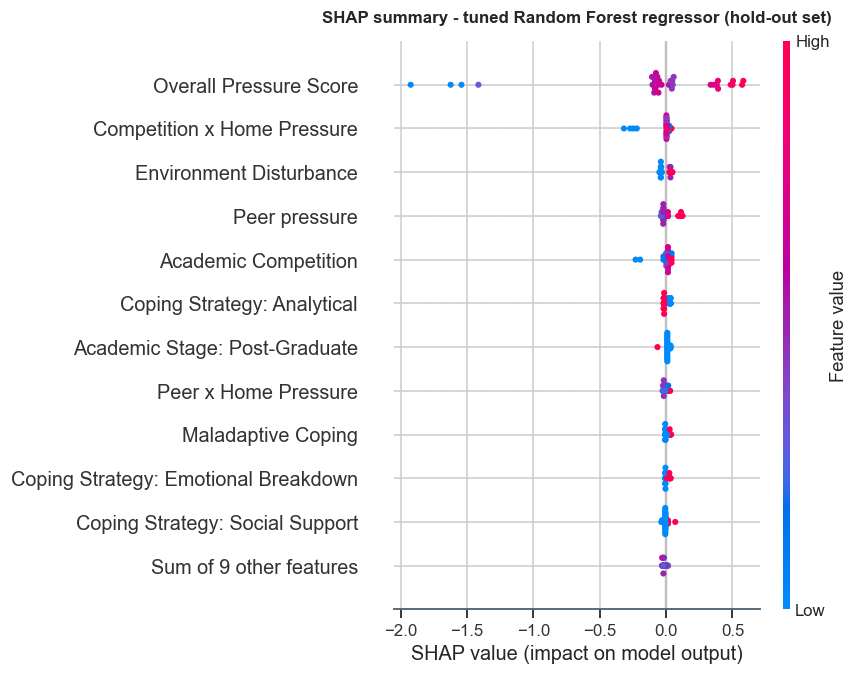


Individual explanation - student index 41: predicted 4.58, actual 5
Their responses:
Column (cleaned)
Peer pressure                             5.0
Home Academic Pressure                    4.0
Academic Competition                      5.0
Academic Stage                  Undergraduate
Study Environment                   Disrupted
Coping Strategy           Emotional Breakdown
Bad Habits                                 No


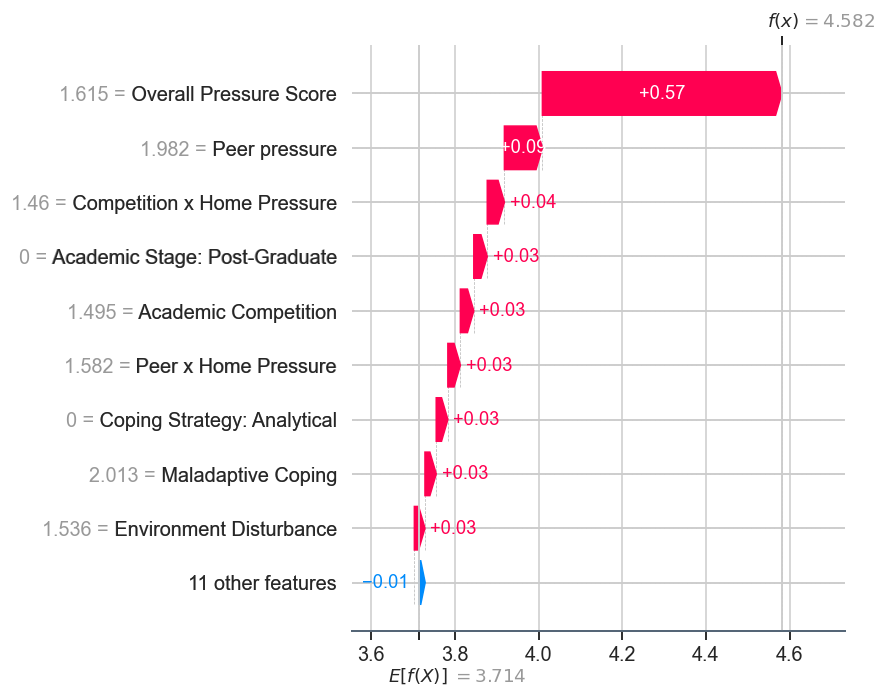

In [64]:
if SHAP_AVAILABLE:
    # SHAP needs the *encoded* matrix, so the fitted preprocessor is applied first and
    # the explainer is attached to the tree ensemble at the end of the pipeline.
    X_test_encoded = pd.DataFrame(
        explainer_preprocessor.transform(X_test),
        columns=readable_feature_names, index=X_test.index,
    )
    tree_explainer = shap.TreeExplainer(explainer_regression_model.named_steps["model"])
    shap_values = tree_explainer(X_test_encoded)

    print("Global feature attribution - how much each feature moves the predicted stress score")
    shap.plots.beeswarm(shap_values, max_display=12, show=False)
    plt.title("SHAP summary - tuned Random Forest regressor (hold-out set)", fontsize=11, pad=12)
    plt.tight_layout()
    plt.show()

    # Individual explanation: the student the model predicts as most stressed.
    highest_predicted = int(np.argmax(explainer_regression_model.predict(X_test)))
    student_id = X_test.index[highest_predicted]
    print(f"\nIndividual explanation - student index {student_id}: "
          f"predicted {explainer_regression_model.predict(X_test)[highest_predicted]:.2f}, "
          f"actual {y_reg_test.loc[student_id]:.0f}")
    print("Their responses:")
    print(X_test.loc[student_id, RATING_ITEMS + CATEGORICAL_FEATURES].to_string())

    shap.plots.waterfall(shap_values[highest_predicted], max_display=10, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("shap is not installed - the SHAP section is skipped.")
    print("Impurity and permutation importance above still provide the global picture.")

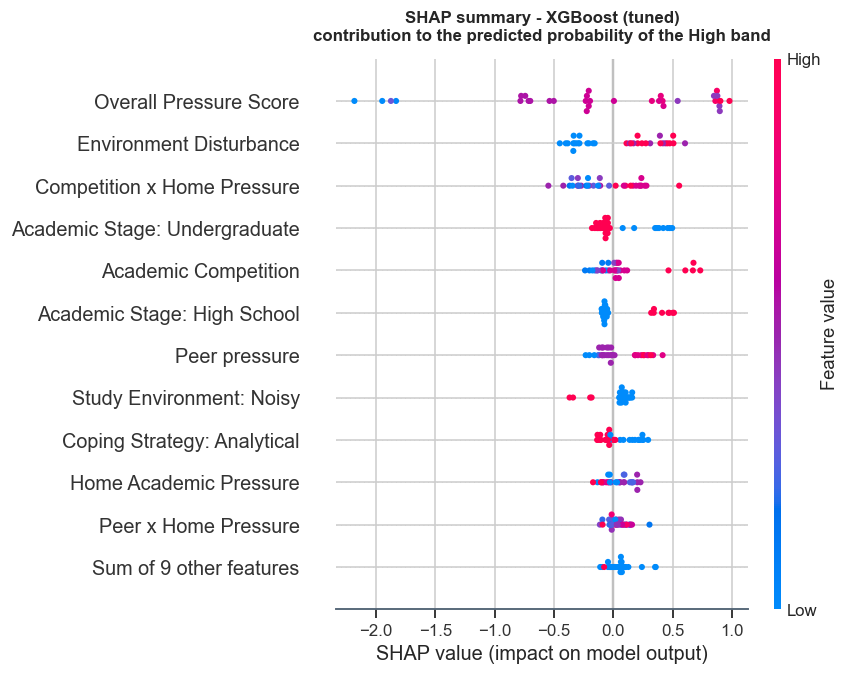

In [65]:
if SHAP_AVAILABLE:
    # The same attribution for the classification problem, on the tuned tree ensemble,
    # explaining the probability assigned to the High-stress band.
    classification_tree_model = tree_search.best_estimator_
    classification_preprocessor = classification_tree_model.named_steps["preprocessor"]
    classification_feature_names = [
        tidy_feature_name(name) for name in classification_preprocessor.get_feature_names_out()
    ]
    X_test_encoded_classification = pd.DataFrame(
        classification_preprocessor.transform(X_test),
        columns=classification_feature_names, index=X_test.index,
    )
    classification_shap = shap.TreeExplainer(
        classification_tree_model.named_steps["model"])(X_test_encoded_classification)

    high_band_index = STRESS_BAND_LABELS.index("High")
    shap.plots.beeswarm(classification_shap[:, :, high_band_index], max_display=12, show=False)
    plt.title(f"SHAP summary - {tree_label}\ncontribution to the predicted probability of the High band",
              fontsize=11, pad=12)
    plt.tight_layout()
    plt.show()

### Findings and Conclusion

The three techniques agree on the substance, which is the reassuring outcome:

* **Pressure-related features dominate.** `Overall Pressure Score` — the composite of peer pressure, home academic pressure and academic competition — is the single largest contributor in every view, and the individual pressure items and their interaction terms follow. Permutation importance concentrates almost all of its mass on the composite, which is a **collinearity artefact rather than a finding**: when the composite is shuffled the model can no longer recover the pressure signal, whereas shuffling one component leaves the composite intact to compensate. The correct reading is that the *pressure block as a whole* drives the predictions, not that any one question does.
* **Study environment contributes consistently but modestly.** `Environment Disturbance` and the `Study Environment: Disrupted` indicator both push predictions upward, matching the group differences found in Part I and confirmed statistically in the next section.
* **Academic stage, coping strategy and reported habits contribute little.** Their attributions cluster near zero, and permutation importance on the hold-out set puts them at or below zero — shuffling them does not make predictions worse. The largest of them, an indicator for post-graduate students, rests on just 11 respondents, so its small impurity score is better explained by a tree finding a convenient split in a tiny subgroup than by a real effect. This does not mean these factors are irrelevant to student stress in general — only that, **within this sample**, they add nothing once the pressure ratings are known.

The SHAP beeswarm shows the expected monotone pattern: high values of the pressure features (in red) push the predicted stress score upward, low values pull it down. The individual waterfall plot decomposes one student's prediction into the specific contributions that produced it, which is the form of explanation that would matter if such a model were ever placed in front of a human decision-maker.

**Restating the caution:** these are associations learned from 129 self-reported survey responses collected at a single point in time. They describe what predicts a student's *reported* stress rating in this sample. They do not establish that peer pressure causes stress, and they should not be read as a causal model.

## ML.19 Statistical Relationship Analysis

Model importances say what helps *prediction*. This section asks a different and complementary question — **which relationships are statistically detectable in the data at all**, independent of any model — and quantifies how large those relationships are.

### Choosing the right tests, rather than applying them mechanically

| Question | Test used | Why it is appropriate here |
| --- | --- | --- |
| Do the ordinal ratings move together? | **Spearman rank correlation** | The items are ordinal 1–5 Likert responses. Pearson's r assumes equal spacing between scale points and approximate normality; Spearman only assumes an order, which is all a Likert item actually guarantees. |
| Do stress levels differ across categorical groups? | **Kruskal–Wallis H** | The non-parametric analogue of one-way ANOVA. ANOVA assumes normally distributed residuals and equal group variances; with a discrete, ceiling-affected 1–5 outcome and groups as small as 6 students, both assumptions are doubtful. Kruskal–Wallis compares rank distributions instead and stays valid here. |
| How large is a difference? | **Epsilon-squared (ε²)** | A p-value only says whether an effect is distinguishable from noise; ε² states what share of the rank variance the grouping accounts for. Reporting it prevents the common error of treating "significant" as "important". |

Four group comparisons are run, so the significance threshold is adjusted with a **Bonferroni correction** (α = 0.05 / 4 = 0.0125) to control the chance of a false positive arising simply from testing several hypotheses.

Note that this analysis uses **all 129 labelled responses**, not the training split: no model is being fitted or selected here, so there is nothing to leak — it is a description of the dataset itself.

In [66]:
def epsilon_squared(h_statistic, n_observations, n_groups):
    """Effect size for Kruskal-Wallis: share of rank variance explained by the grouping."""
    return (h_statistic - n_groups + 1) / (n_observations - n_groups)


def interpret_effect_size(value):
    """Conventional qualitative bands for epsilon-squared."""
    if value < 0.01:
        return "negligible"
    if value < 0.06:
        return "small"
    if value < 0.14:
        return "moderate"
    return "large"


# --- Spearman correlations with the target -----------------------------------
correlation_rows = []
for item in RATING_ITEMS + ["Overall Pressure Score", "Environment Disturbance"]:
    paired = ml_features[[item, TARGET]].dropna()
    rho, p_value = stats.spearmanr(paired[item], paired[TARGET])
    correlation_rows.append({
        "Factor": item,
        "n": len(paired),
        "Spearman rho": rho,
        "p-value": p_value,
        "Significant (a=0.05)": "yes" if p_value < 0.05 else "no",
    })

correlation_tests = pd.DataFrame(correlation_rows).set_index("Factor")
print("Rank correlation with the reported academic stress index")
display(correlation_tests.round(4))

# --- Kruskal-Wallis group comparisons ----------------------------------------
BONFERRONI_ALPHA = 0.05 / len(CATEGORICAL_FEATURES)

group_rows = []
for factor in CATEGORICAL_FEATURES:
    paired = ml_features[[factor, TARGET]].dropna()
    groups = [values[TARGET].to_numpy() for _, values in paired.groupby(factor, observed=True)]
    h_statistic, p_value = stats.kruskal(*groups)
    effect = epsilon_squared(h_statistic, len(paired), len(groups))
    group_rows.append({
        "Factor": factor,
        "Groups": len(groups),
        "n": len(paired),
        "Smallest group": min(len(g) for g in groups),
        "H": h_statistic,
        "p-value": p_value,
        "Epsilon^2": effect,
        "Effect size": interpret_effect_size(effect),
        f"Significant (a={BONFERRONI_ALPHA:.4f})": "yes" if p_value < BONFERRONI_ALPHA else "no",
    })

group_tests = pd.DataFrame(group_rows).set_index("Factor")
print(f"\nKruskal-Wallis comparisons of stress across groups "
      f"(Bonferroni-corrected threshold a = {BONFERRONI_ALPHA:.4f})")
display(group_tests.round(4))

print("\nGroup medians and means of the stress index")
for factor in CATEGORICAL_FEATURES:
    summary = ml_features.groupby(factor, observed=True)[TARGET].agg(["count", "median", "mean"]).round(2)
    print(f"\n{factor}")
    print(summary.to_string())

Rank correlation with the reported academic stress index


,n,Spearman rho,p-value,Significant (a=0.05)
Factor,,,,
Peer pressure,120,0.4826,0.0000,yes
Home Academic Pressure,123,0.3856,0.0000,yes
Academic Competition,120,0.3826,0.0000,yes
Overall Pressure Score,129,0.5595,0.0000,yes
Environment Disturbance,121,0.2765,0.0021,yes



Kruskal-Wallis comparisons of stress across groups (Bonferroni-corrected threshold a = 0.0125)


,Groups,n,Smallest group,H,p-value,Epsilon^2,Effect size,Significant (a=0.0125)
Factor,,,,,,,,
Academic Stage,3,129,11,0.5657,0.7536,-0.0114,negligible,no
Study Environment,3,121,30,9.2378,0.0099,0.0613,moderate,yes
Coping Strategy,3,122,20,2.2882,0.3185,0.0024,negligible,no
Bad Habits,3,129,6,4.0944,0.1291,0.0166,small,no



Group medians and means of the stress index

Academic Stage
                count  median  mean
Academic Stage                     
High School        24     4.0  3.83
Post-Graduate      11     4.0  3.73
Undergraduate      94     4.0  3.67

Study Environment
                   count  median  mean
Study Environment                     
Disrupted             33     4.0  4.03
Noisy                 30     4.0  3.83
Peaceful              58     3.5  3.43

Coping Strategy
                     count  median  mean
Coping Strategy                         
Analytical              72     4.0  3.64
Emotional Breakdown     30     4.0  3.93
Social Support          20     4.0  3.80

Bad Habits
                   count  median  mean
Bad Habits                            
No                   113     4.0  3.67
Prefer not to say      6     3.5  3.33
Yes                   10     4.5  4.30


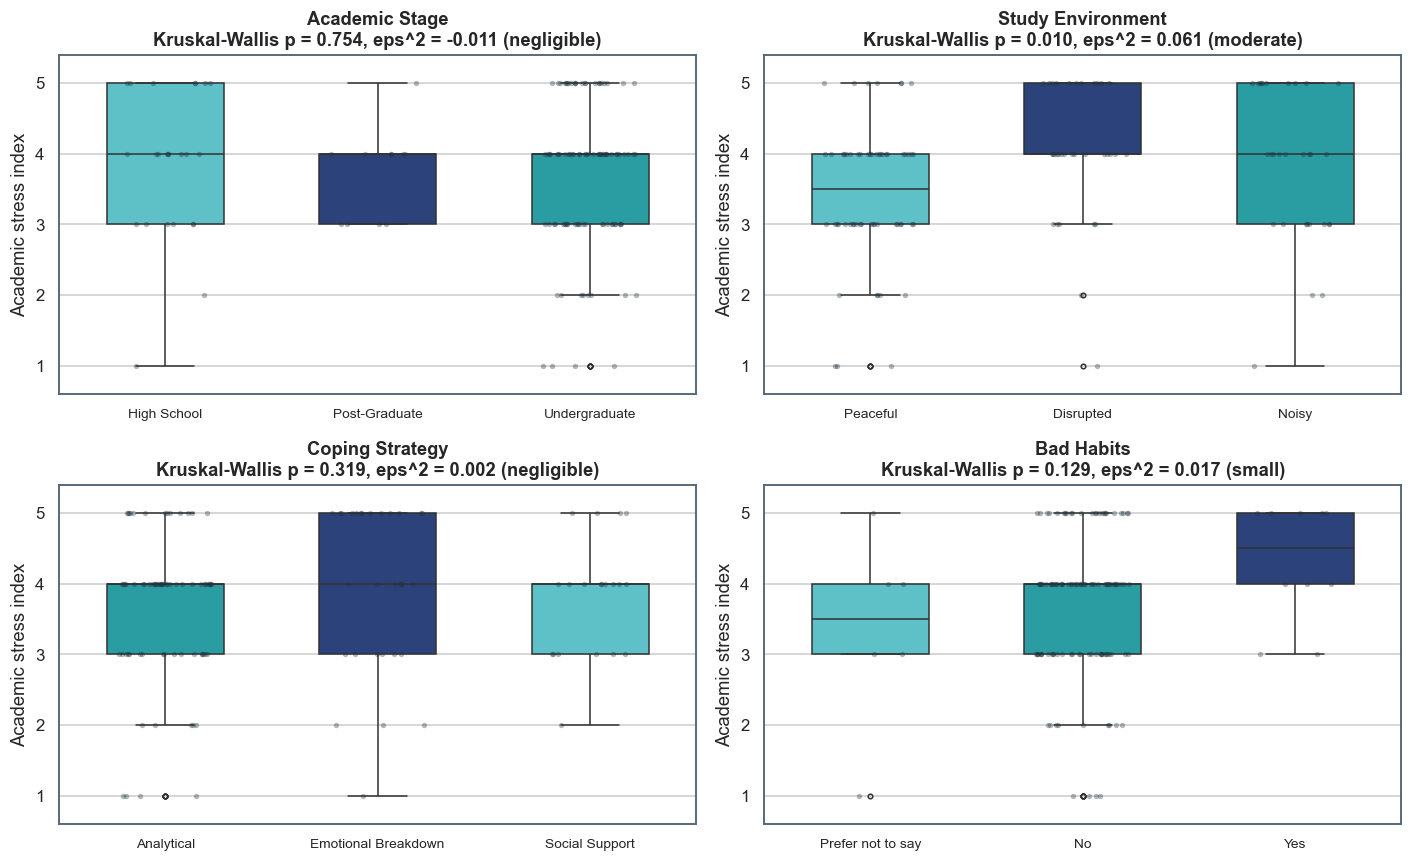

In [67]:
# Distribution of stress within each categorical factor.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, factor in zip(axes.ravel(), CATEGORICAL_FEATURES):
    subset = ml_features[[factor, TARGET]].dropna()
    order = subset.groupby(factor, observed=True)[TARGET].median().sort_values().index
    sns.boxplot(data=subset, x=factor, y=TARGET, order=order, hue=factor, legend=False,
                palette=[PALETTE[0], PALETTE[1], PALETTE[2]], width=0.55,
                fliersize=3, ax=ax)
    sns.stripplot(data=subset, x=factor, y=TARGET, order=order,
                  color="#20343f", alpha=0.35, size=3.5, jitter=0.22, ax=ax)

    test_row = group_tests.loc[factor]
    ax.set_title(f"{factor}\nKruskal-Wallis p = {test_row['p-value']:.3f}, "
                 f"eps^2 = {test_row['Epsilon^2']:.3f} ({test_row['Effect size']})")
    ax.set_xlabel("")
    ax.set_ylabel("Academic stress index")
    ax.set_ylim(LIKERT_MIN - 0.4, LIKERT_MAX + 0.4)
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
save_figure("stress_by_categorical_factor.png")
plt.show()

### Findings and Conclusion

**Rank correlations.** All three pressure items are positively and significantly associated with reported stress (p < 0.001 in each case). The composite `Overall Pressure Score` is the strongest (ρ ≈ 0.56), and `Environment Disturbance` is moderate but clear (ρ ≈ 0.28, p ≈ 0.002).

**Group comparisons.** Only one of the four categorical factors survives the Bonferroni-corrected threshold:

* **Study Environment** differs significantly (p ≈ 0.010, ε² ≈ 0.06 — just over the conventional small/moderate boundary, so a real but modest effect: the grouping accounts for roughly 6% of the rank variance). Mean stress falls from 4.03 in disrupted environments to 3.43 in peaceful ones, consistent with the group means reported in Part I.
* **Academic Stage** does **not** differ significantly (p ≈ 0.75, ε² ≈ 0). This is an important correction to a claim in Part I: the observed ordering of group means (High School 3.83 > Post-Graduate 3.73 > Undergraduate 3.67) is well within what sampling variation would produce, particularly with only 11 post-graduate respondents. **The data do not support the conclusion that stress differs by academic stage.** This is exactly the kind of over-reading of small group means that a formal test exists to catch, and the modelling results agree — academic stage contributed almost nothing to the models in ML.18.
* **Bad Habits** shows the largest raw difference (mean 4.30 for students reporting habits versus 3.67 for those who do not), but with only 10 and 6 students in the two smaller groups it does not reach significance (p ≈ 0.13). This is a *suggestive but unresolved* pattern, not a finding — a larger sample would be needed to settle it.
* **Coping Strategy** shows no significant difference (p ≈ 0.32).

**Association is not causation.** Every relationship here comes from a single cross-sectional self-report survey. Even the significant environment result admits several explanations: a disruptive environment may raise stress, stressed students may perceive their surroundings as more disruptive, or a third factor (crowded housing, financial pressure, workload) may drive both. The design cannot distinguish between them, and nothing in this notebook should be read as evidence that changing one variable would change another.

## ML.20 Model Robustness Checks

With 96 training rows, the most valuable checks are the ones that expose whether a result is real or a fold-assignment accident. Four are run:

1. **Train vs cross-validation vs hold-out** for every model — a large gap between training and cross-validated performance is overfitting; poor performance on all three is underfitting.
2. **Cross-validation variability** — the fold-to-fold standard deviation, which sets the resolution at which model differences can be believed at all.
3. **A learning curve** — does the validation error still improve as training rows are added? If it does, the limiting factor is data volume rather than model choice.
4. **Class imbalance and residual behaviour** — already examined in ML.13 and ML.17 and summarised here.

Regression models: generalisation behaviour


,Train R2,CV R2,CV MAE,CV MAE (sd),Train - CV R2 gap,Verdict
Model,,,,,,
Baseline: mean predictor,0.000,-0.131,0.823,0.144,0.131,underfitting / no signal
Lasso Regression,0.491,0.274,0.651,0.103,0.217,reasonable balance
Ridge Regression (tuned),0.528,0.285,0.637,0.101,0.243,reasonable balance
Ridge Regression,0.553,0.229,0.647,0.109,0.325,reasonable balance
Random Forest (tuned),0.654,0.326,0.637,0.089,0.328,reasonable balance
Baseline: Linear Regression,0.557,0.161,0.660,0.114,0.396,overfitting
Random Forest,0.907,0.189,0.681,0.080,0.718,overfitting
Gradient Boosting,0.906,0.030,0.712,0.087,0.876,overfitting
XGBoost,0.917,-0.025,0.726,0.082,0.942,overfitting


Typical CV standard deviation across models: 0.107 MAE points
Differences between models smaller than this are not distinguishable from fold noise.



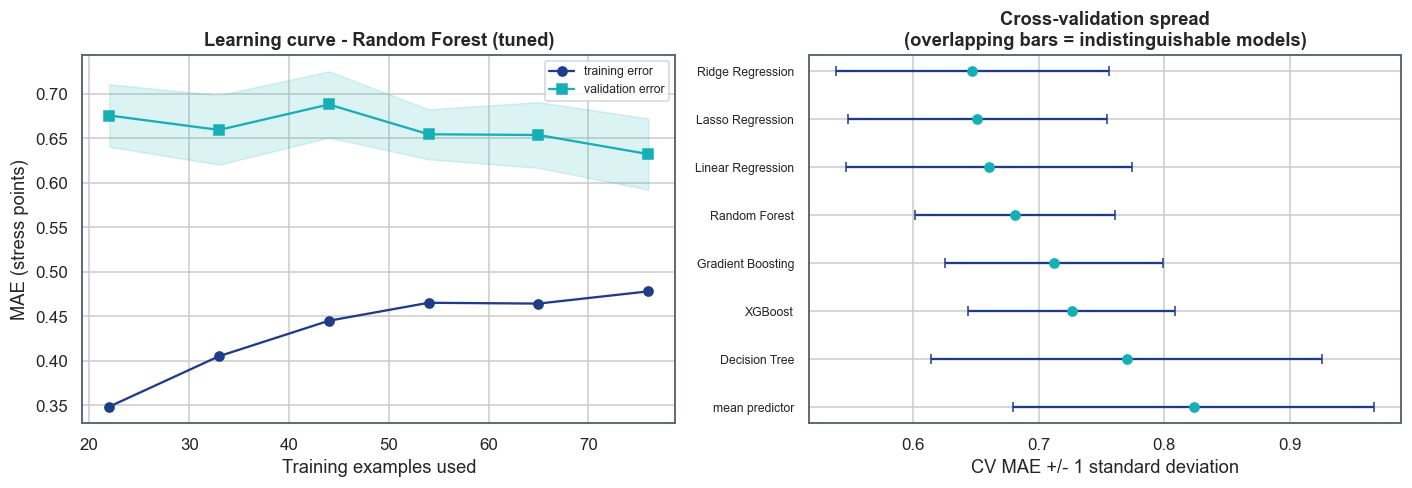

Learning curve values
 Training rows  Training MAE  Validation MAE
            22         0.349           0.675
            33         0.405           0.659
            44         0.445           0.688
            54         0.465           0.654
            65         0.464           0.654
            76         0.478           0.632


In [68]:
# A reporting heuristic, not a formal test: a model that explains this much more
# variance in-sample than out is flagged for inspection.
OVERFIT_R2_GAP = 0.35
WEAK_SIGNAL_R2 = 0.05

# --- 1 & 2: generalisation gap and CV variability ----------------------------
# The two tuned pipelines are scored on the same footing so the comparison is complete.
tuned_rows = []
for tuned_name, tuned_pipeline in [("Ridge Regression (tuned)", ridge_search.best_estimator_),
                                   ("Random Forest (tuned)", forest_search.best_estimator_)]:
    tuned_cv = cross_validate(tuned_pipeline, X_train, y_reg_train, cv=regression_cv,
                              scoring=["neg_mean_absolute_error", "r2"], n_jobs=-1)
    tuned_rows.append({
        "Model": tuned_name,
        "Train R2": r2_score(y_reg_train, tuned_pipeline.predict(X_train)),
        "CV R2": tuned_cv["test_r2"].mean(),
        "CV MAE": -tuned_cv["test_neg_mean_absolute_error"].mean(),
        "CV MAE (sd)": tuned_cv["test_neg_mean_absolute_error"].std(),
    })

robustness = pd.concat([
    regression_results[["Train R2", "CV R2", "CV MAE", "CV MAE (sd)"]],
    pd.DataFrame(tuned_rows).set_index("Model"),
])
robustness["Train - CV R2 gap"] = robustness["Train R2"] - robustness["CV R2"]
robustness["Verdict"] = np.where(
    robustness["Train - CV R2 gap"] > OVERFIT_R2_GAP, "overfitting",
    np.where(robustness["CV R2"] < WEAK_SIGNAL_R2, "underfitting / no signal", "reasonable balance"),
)
print("Regression models: generalisation behaviour")
display(robustness[["Train R2", "CV R2", "CV MAE", "CV MAE (sd)",
                    "Train - CV R2 gap", "Verdict"]].sort_values("Train - CV R2 gap").round(3))

print(f"Typical CV standard deviation across models: "
      f"{robustness['CV MAE (sd)'].mean():.3f} MAE points")
print("Differences between models smaller than this are not distinguishable from fold noise.\n")

# --- 3: learning curve for the selected regression model ---------------------
train_sizes, train_scores, validation_scores = learning_curve(
    final_regression_model, X_train, y_reg_train,
    cv=RepeatedKFold(n_splits=CV_SPLITS, n_repeats=1, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.3, 1.0, 6),
    scoring="neg_mean_absolute_error", n_jobs=-1, random_state=RANDOM_STATE,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

train_mae, validation_mae = -train_scores.mean(axis=1), -validation_scores.mean(axis=1)
axes[0].plot(train_sizes, train_mae, marker="o", color=PALETTE[2], label="training error")
axes[0].plot(train_sizes, validation_mae, marker="s", color=PALETTE[0], label="validation error")
axes[0].fill_between(train_sizes,
                     -validation_scores.mean(axis=1) - validation_scores.std(axis=1),
                     -validation_scores.mean(axis=1) + validation_scores.std(axis=1),
                     color=PALETTE[0], alpha=0.15)
axes[0].set_title(f"Learning curve - {FINAL_REGRESSION_NAME}")
axes[0].set_xlabel("Training examples used"); axes[0].set_ylabel("MAE (stress points)")
axes[0].legend(fontsize=8)

# --- 4: CV score spread per model --------------------------------------------
spread = regression_results.sort_values("CV MAE")
axes[1].errorbar(spread["CV MAE"], range(len(spread)), xerr=spread["CV MAE (sd)"],
                 fmt="o", color=PALETTE[0], ecolor=PALETTE[2], capsize=3)
axes[1].set_yticks(range(len(spread)))
axes[1].set_yticklabels([name.replace("Baseline: ", "") for name in spread.index], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Cross-validation spread\n(overlapping bars = indistinguishable models)")
axes[1].set_xlabel("CV MAE +/- 1 standard deviation")

plt.tight_layout()
save_figure("robustness_learning_curve_and_cv_spread.png")
plt.show()

print("Learning curve values")
print(pd.DataFrame({"Training rows": train_sizes.astype(int),
                    "Training MAE": train_mae.round(3),
                    "Validation MAE": validation_mae.round(3)}).to_string(index=False))

### Findings and Conclusion

* **Overfitting is real, and tuning is what manages it.** The unconstrained decision tree and the untuned ensembles show train-to-CV R² gaps of 0.7–1.3; the regularised linear models and the depth-constrained tuned forest sit between 0.22 and 0.33. Plain least squares falls just on the wrong side of the reporting threshold while Ridge and Lasso fall below it — a direct illustration of what the penalty term buys on a small sample. The tuned Random Forest's gap is less than half that of its untuned counterpart (0.33 against 0.72), at a *better* cross-validated score.
* **No model underfits.** Every non-baseline model beats the mean predictor on MAE, so the feature set does carry signal.
* **Cross-validation variability is the binding constraint.** The typical fold-to-fold standard deviation is about 0.11 MAE points, while the entire spread between the leading models is roughly 0.01. The error bars in the right-hand panel overlap heavily: **the leaderboard identifies a group of equivalent models, not a decisive winner**, and any claim to the contrary would be over-reading the data.
* **The learning curve has not flattened.** Validation error still trends down as training rows are added (about 0.68 at 22 rows to 0.63 at 76), and a wide gap to the training curve remains. The clearest route to a better model here is **more data, not a more sophisticated algorithm**.
* **Class imbalance** (5.7 : 1) is handled through stratification, balanced class weights and macro-averaged metrics rather than synthetic resampling, and **residuals** are approximately centred and structure-free (ML.13).

**Overall verdict:** the results are internally consistent and honestly obtained, but the dataset is small and single-source. The models are best understood as evidence that these survey items carry a moderate, reproducible signal about reported stress — not as production-ready predictors.

## ML.21 Final Model Evaluation

The hold-out set has been untouched by every selection decision up to this point. It is used here, once, to report final performance for both selected models side by side with their baselines.

In [69]:
final_evaluation = pd.DataFrame([
    {
        "Problem": "Regression (stress score 1-5)",
        "Selected model": FINAL_REGRESSION_NAME,
        "Primary metric": "MAE",
        "Baseline (CV)": f"{regression_results.loc['Baseline: mean predictor', 'CV MAE']:.3f}",
        "Selected (CV)": f"{FINAL_REGRESSION_METRICS['cv_mae']:.3f}",
        "Selected (hold-out)": f"{FINAL_REGRESSION_METRICS['test_mae']:.3f}",
        "Secondary (hold-out)": (f"RMSE {FINAL_REGRESSION_METRICS['test_rmse']:.3f} | "
                                 f"R2 {FINAL_REGRESSION_METRICS['test_r2']:.3f} | "
                                 f"expl.var {FINAL_REGRESSION_METRICS['test_explained_variance']:.3f}"),
    },
    {
        "Problem": "Classification (Low / Moderate / High)",
        "Selected model": FINAL_CLASSIFICATION_NAME,
        "Primary metric": "Macro F1",
        "Baseline (CV)": f"{classification_results.loc['Baseline: majority class', 'CV F1 (macro)']:.3f}",
        "Selected (CV)": f"{FINAL_CLASSIFICATION_METRICS['cv_f1_macro']:.3f}",
        "Selected (hold-out)": f"{FINAL_CLASSIFICATION_METRICS['test_f1_macro']:.3f}",
        "Secondary (hold-out)": (f"acc {FINAL_CLASSIFICATION_METRICS['test_accuracy']:.3f} | "
                                 f"ROC-AUC {FINAL_CLASSIFICATION_METRICS['test_roc_auc_ovr_macro']:.3f} | "
                                 f"weighted F1 {FINAL_CLASSIFICATION_METRICS['test_f1_weighted']:.3f}"),
    },
]).set_index("Problem")

print("Final hold-out evaluation (test set used exactly once, after all selection)")
display(final_evaluation)

regression_gain = (regression_results.loc["Baseline: mean predictor", "CV MAE"]
                   - FINAL_REGRESSION_METRICS["cv_mae"])
classification_gain = (FINAL_CLASSIFICATION_METRICS["cv_f1_macro"]
                       - classification_results.loc["Baseline: majority class", "CV F1 (macro)"])

print(f"\nRegression   : {regression_gain:.3f} MAE points better than the mean predictor "
      f"({regression_gain / regression_results.loc['Baseline: mean predictor', 'CV MAE'] * 100:.0f}% error reduction)")
print(f"Classification: {classification_gain:+.3f} macro F1 over the majority-class baseline "
      f"({FINAL_CLASSIFICATION_METRICS['cv_f1_macro'] / classification_results.loc['Baseline: majority class', 'CV F1 (macro)']:.1f}x)")

Final hold-out evaluation (test set used exactly once, after all selection)


,Selected model,Primary metric,Baseline (CV),Selected (CV),Selected (hold-out),Secondary (hold-out)
Problem,,,,,,
Regression (stress score 1-5),Random Forest (tuned),MAE,0.823,0.637,0.697,RMSE 0.840 | R2 0.408 | expl.var 0.410
Classification (Low / Moderate / High),SVM (RBF kernel) (tuned),Macro F1,0.256,0.610,0.539,acc 0.545 | ROC-AUC 0.720 | weighted F1 0.564



Regression   : 0.187 MAE points better than the mean predictor (23% error reduction)
Classification: +0.354 macro F1 over the majority-class baseline (2.4x)


## ML.22 Example Predictions

A model is only usable if new, unseen information can be pushed through it. This section builds three hypothetical students **in the raw survey format** — the same column names, the same wording, the same free-text category labels a new response would arrive in — and passes them through the *identical* code path used in training:

`raw record → clean_dataset() → engineer_features() → select MODEL_FEATURES → fitted Pipeline`

Because the fitted pipeline carries its own imputer, scaler and encoder, no preprocessing has to be repeated by hand, and there is no way for the demonstration to accidentally use a different transformation from the one the model was trained on.

The three profiles are chosen to span the range: a low-pressure student in a peaceful environment, a moderate case, and a high-pressure student in a disrupted environment.

In [70]:
def prepare_records_for_model(records):
    """Take raw survey-format records and return a frame ready for the fitted pipelines."""
    frame = pd.DataFrame(records).rename(columns=COLUMN_RENAME)
    frame = clean_dataset(frame)
    frame = engineer_features(frame)
    return frame[MODEL_FEATURES]


example_students = [
    {
        "Profile": "Low-pressure student",
        "Your Academic Stage": "undergraduate",
        "Peer pressure": 1,
        "Academic pressure from your home": 2,
        "Study Environment": "Peaceful",
        "What coping strategy you use as a student?": "Social support (friends, family)",
        "Do you have any bad habits like smoking, drinking on a daily basis?": "No",
        "What would you rate the academic  competition in your student life": 2,
    },
    {
        "Profile": "Moderate-pressure student",
        "Your Academic Stage": "undergraduate",
        "Peer pressure": 3,
        "Academic pressure from your home": 3,
        "Study Environment": "Noisy",
        "What coping strategy you use as a student?": "Analyze the situation and handle it with intellect",
        "Do you have any bad habits like smoking, drinking on a daily basis?": "No",
        "What would you rate the academic  competition in your student life": 3,
    },
    {
        "Profile": "High-pressure student",
        "Your Academic Stage": "high school",
        "Peer pressure": 5,
        "Academic pressure from your home": 5,
        "Study Environment": "disrupted",
        "What coping strategy you use as a student?": "Emotional breakdown (crying a lot)",
        "Do you have any bad habits like smoking, drinking on a daily basis?": "Yes",
        "What would you rate the academic  competition in your student life": 5,
    },
]

profiles = [student.pop("Profile") for student in example_students]
X_examples = prepare_records_for_model(example_students)

predicted_scores = final_regression_model.predict(X_examples)
predicted_bands = final_classification_model.predict(X_examples)
predicted_band_probabilities = final_classification_model.predict_proba(X_examples)

example_output = pd.DataFrame({
    "Profile": profiles,
    "Predicted stress score (1-5)": np.round(predicted_scores, 2),
    "Predicted band": [STRESS_BAND_LABELS[code] for code in predicted_bands],
    # The confidence reported is the probability of the band that was actually
    # predicted, not the largest probability in the row. For an SVC the two can
    # differ: `predict` uses libsvm's voting over the decision function, while
    # `predict_proba` uses a separately fitted Platt calibration. Near a band
    # boundary they can disagree, so the most probable band is shown alongside
    # rather than letting a max() quietly paper over the disagreement.
    "Confidence in predicted band": [
        f"{row[code]:.0%}"
        for row, code in zip(predicted_band_probabilities, predicted_bands)
    ],
    "Most probable band": [
        STRESS_BAND_LABELS[row.argmax()] for row in predicted_band_probabilities
    ],
}).set_index("Profile")

probability_detail = pd.DataFrame(
    predicted_band_probabilities, index=profiles,
    columns=[f"P({band})" for band in STRESS_BAND_LABELS]).round(3)

print(f"Regression model    : {FINAL_REGRESSION_NAME}")
print(f"Classification model: {FINAL_CLASSIFICATION_NAME}\n")
display(example_output)
print("Full predicted band probabilities")
display(probability_detail)

print("\nEngineered features generated automatically for these records:")
display(X_examples[ENGINEERED_NUMERIC].round(2))

Regression model    : Random Forest (tuned)
Classification model: SVM (RBF kernel) (tuned)



,Predicted stress score (1-5),Predicted band,Confidence in predicted band,Most probable band
Profile,,,,
Low-pressure student,2.64,Low,40%,Low
Moderate-pressure student,3.57,Moderate,36%,High
High-pressure student,4.64,High,77%,High


Full predicted band probabilities


,P(Low),P(Moderate),P(High)
Low-pressure student,0.399,0.351,0.250
Moderate-pressure student,0.107,0.362,0.531
High-pressure student,0.040,0.191,0.770



Engineered features generated automatically for these records:


,Overall Pressure Score,Peer x Home Pressure,Competition x Home Pressure,Environment Disturbance,Maladaptive Coping
0,1.67,2.0,4.0,0,0.0
1,3.00,9.0,9.0,1,0.0
2,5.00,25.0,25.0,2,1.0


### Findings and Conclusion

The two models agree with each other and move in the expected direction: the low-pressure profile receives the lowest predicted score and the high-pressure profile the highest, with the predicted bands following suit. Note that the regression predictions are **compressed towards the middle of the scale** — the low-pressure student is not predicted at 1.0 — which is the conservative behaviour already observed in the diagnostics and, on a noisy self-report target, the appropriate one.

The predicted probabilities are equally informative: where a profile sits near a band boundary, the model spreads its probability across adjacent bands rather than committing. Any real deployment should surface that uncertainty rather than only the top label.

The moderate-pressure profile illustrates a subtlety worth naming. Its predicted band is `Moderate`, yet the largest probability in its row belongs to `High` — the two disagree. This is not an error in the pipeline: `SVC.predict` decides by libsvm's voting over the decision function, whereas `SVC.predict_proba` reports a **separately fitted Platt calibration**, and scikit-learn documents that the two can diverge for points close to a decision boundary. The table therefore reports the probability of the band that was actually predicted and shows the most probable band next to it, so the disagreement is visible. A profile where those two columns differ is precisely a profile whose band should not be treated as settled — which is the honest signal to pass on, and the reason a calibrated probability is a better output here than a hard label.

Crucially, the demonstration required **no manual preprocessing**. The raw records — including the lower-case `disrupted` spelling from the original survey and the full-length coping-strategy wording — were cleaned, engineered, imputed, scaled and encoded by the same code and the same fitted transformers used in training. That is the practical payoff of building everything as a `Pipeline`.

## ML.23 Saving the Final Models

Both selected pipelines are persisted with `joblib`, together with a metadata file recording everything a future user needs in order to use them correctly.

Serialising the **whole pipeline**, not just the estimator, is what makes the artefacts usable: the saved file contains the fitted imputers, scaler and one-hot encoder alongside the model, so a reloaded artefact accepts raw-format features directly and cannot drift out of sync with a separately-stored preprocessing step.

The metadata records the feature list and order, the target definition, the classification band thresholds and labels, the measured metrics, and the library versions the artefacts were built with — the details that make a saved model reusable rather than merely loadable.

In [71]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

regression_path = MODEL_DIR / "best_stress_regression_model.pkl"
classification_path = MODEL_DIR / "best_stress_classification_model.pkl"
metadata_path = MODEL_DIR / "model_metadata.json"

joblib.dump(final_regression_model, regression_path)
joblib.dump(final_classification_model, classification_path)

model_metadata = {
    "project": "Academic Stress Analysis - predictive modelling",
    "created_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"),
    "source_dataset": relative_to_root(DATA_PATH),
    "rows_labelled": int(len(ml_features)),
    "rows_train": int(len(X_train)),
    "rows_test": int(len(X_test)),
    "random_state": RANDOM_STATE,
    "feature_names": MODEL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "engineered_features": ENGINEERED_NUMERIC,
    "excluded_features": {
        "temporal": CANDIDATE_TEMPORAL_FEATURES,
        "reason": "no cross-validated improvement; reflects survey timing, not the student",
    },
    "regression": {
        "target": TARGET,
        "target_scale": [LIKERT_MIN, LIKERT_MAX],
        "model": FINAL_REGRESSION_NAME,
        "artefact": regression_path.name,
        "primary_metric": "mean absolute error",
        "metrics": FINAL_REGRESSION_METRICS,
        "baseline_cv_mae": float(regression_results.loc["Baseline: mean predictor", "CV MAE"]),
    },
    "classification": {
        "target": f"{TARGET} banded",
        "band_edges": STRESS_BAND_EDGES,
        "band_labels": STRESS_BAND_LABELS,
        "band_rule": "rating 1-2 -> Low, 3 -> Moderate, 4-5 -> High",
        "class_codes": {label: index for index, label in enumerate(STRESS_BAND_LABELS)},
        "model": FINAL_CLASSIFICATION_NAME,
        "artefact": classification_path.name,
        "primary_metric": "macro-averaged F1",
        "metrics": FINAL_CLASSIFICATION_METRICS,
        "baseline_cv_f1_macro": float(
            classification_results.loc["Baseline: majority class", "CV F1 (macro)"]),
    },
    "library_versions": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit-learn": sklearn.__version__,
        "xgboost": __import__("xgboost").__version__ if XGBOOST_AVAILABLE else None,
    },
    "intended_use": (
        "Educational / portfolio demonstration of a predictive modelling workflow on "
        "self-reported survey data. Not a clinical, diagnostic or screening instrument."
    ),
}

metadata_path.write_text(json.dumps(model_metadata, indent=2), encoding="utf-8")

for path in (regression_path, classification_path, metadata_path):
    print(f"saved  {relative_to_root(path)}  ({path.stat().st_size / 1024:.1f} KB)")

saved  models/best_stress_regression_model.pkl  (788.9 KB)
saved  models/best_stress_classification_model.pkl  (25.3 KB)
saved  models/model_metadata.json  (3.2 KB)


In [72]:
# Verify the artefacts round-trip: reload from disk and confirm identical predictions.
reloaded_regression = joblib.load(regression_path)
reloaded_classification = joblib.load(classification_path)
reloaded_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

reloaded_scores = reloaded_regression.predict(X_examples)
reloaded_bands = reloaded_classification.predict(X_examples)

assert np.allclose(reloaded_scores, predicted_scores), "Reloaded regression model disagrees"
assert np.array_equal(reloaded_bands, predicted_bands), "Reloaded classification model disagrees"
assert reloaded_metadata["feature_names"] == MODEL_FEATURES, "Metadata feature list is out of date"

print("Reload verification")
print(f"   regression model    : {reloaded_metadata['regression']['model']} - predictions match")
print(f"   classification model: {reloaded_metadata['classification']['model']} - predictions match")
print(f"   metadata feature list matches the training feature list ({len(MODEL_FEATURES)} features)")
print("\nWorked example - loading the saved artefacts from scratch:")
print("   model = joblib.load('models/best_stress_regression_model.pkl')")
print("   model.predict(prepare_records_for_model([raw_survey_record]))")
print(f"   -> {reloaded_regression.predict(X_examples.head(1))[0]:.2f} "
      "(predicted stress score for the first example student)")

Reload verification
   regression model    : Random Forest (tuned) - predictions match
   classification model: SVM (RBF kernel) (tuned) - predictions match
   metadata feature list matches the training feature list (12 features)

Worked example - loading the saved artefacts from scratch:
   model = joblib.load('models/best_stress_regression_model.pkl')
   model.predict(prepare_records_for_model([raw_survey_record]))
   -> 2.64 (predicted stress score for the first example student)


## ML.24 Key Findings

The summary below is **generated from the objects computed in this notebook run**, not typed in by hand, so it cannot drift out of step with the results above. The narrative interpretation follows it.

In [73]:
def summarise_project():
    """Print a project summary built entirely from computed results."""
    line = "=" * 78

    top_associations = correlation_tests.sort_values("Spearman rho", ascending=False)
    significant_groups = group_tests[
        group_tests[f"Significant (a={BONFERRONI_ALPHA:.4f})"] == "yes"].index.tolist()
    top_predictive = impurity_importance.head(4)

    print(line)
    print("ACADEMIC STRESS - PREDICTIVE MODELLING: KEY FINDINGS")
    print(line)

    print("\nDATASET")
    print(f"  Survey responses collected      : {len(ml_raw)}")
    print(f"  Usable (stress rating recorded) : {len(ml_features)}")
    print(f"  Train / hold-out split          : {len(X_train)} / {len(X_test)} rows "
          f"(stratified by stress band)")
    print(f"  Predictors used                 : {len(MODEL_FEATURES)} "
          f"({len(NUMERIC_FEATURES)} numeric incl. {len(ENGINEERED_NUMERIC)} engineered, "
          f"{len(CATEGORICAL_FEATURES)} categorical)")
    print(f"  Mean reported stress            : {ml_features[TARGET].mean():.2f} / {LIKERT_MAX} "
          f"(sd {ml_features[TARGET].std():.2f})")

    print("\nFACTORS MOST STRONGLY ASSOCIATED WITH REPORTED STRESS")
    for factor, row in top_associations.iterrows():
        print(f"  {factor:<28} Spearman rho = {row['Spearman rho']:+.3f}  (p = {row['p-value']:.4f})")
    print(f"  Group differences significant after Bonferroni correction: "
          f"{significant_groups if significant_groups else 'none'}")

    print("\nREGRESSION - predicting the 1-5 stress score")
    print(f"  Selected model      : {FINAL_REGRESSION_NAME}")
    print(f"  Cross-validated MAE : {FINAL_REGRESSION_METRICS['cv_mae']:.3f} stress points")
    print(f"  Hold-out            : MAE {FINAL_REGRESSION_METRICS['test_mae']:.3f} | "
          f"RMSE {FINAL_REGRESSION_METRICS['test_rmse']:.3f} | "
          f"R2 {FINAL_REGRESSION_METRICS['test_r2']:.3f}")
    print(f"  Mean-predictor baseline (CV MAE): "
          f"{regression_results.loc['Baseline: mean predictor', 'CV MAE']:.3f} "
          f"-> {regression_gain / regression_results.loc['Baseline: mean predictor', 'CV MAE'] * 100:.0f}% error reduction")

    print("\nCLASSIFICATION - Low / Moderate / High stress band")
    print(f"  Selected model         : {FINAL_CLASSIFICATION_NAME}")
    print(f"  Cross-validated macro F1: {FINAL_CLASSIFICATION_METRICS['cv_f1_macro']:.3f}")
    print(f"  Hold-out               : macro F1 {FINAL_CLASSIFICATION_METRICS['test_f1_macro']:.3f} | "
          f"accuracy {FINAL_CLASSIFICATION_METRICS['test_accuracy']:.3f} | "
          f"ROC-AUC {FINAL_CLASSIFICATION_METRICS['test_roc_auc_ovr_macro']:.3f}")
    print(f"  Majority-class baseline: macro F1 "
          f"{classification_results.loc['Baseline: majority class', 'CV F1 (macro)']:.3f} "
          f"(accuracy {classification_results.loc['Baseline: majority class', 'CV accuracy']:.3f})")

    print("\nMOST INFLUENTIAL FEATURES (tuned Random Forest, impurity importance)")
    for feature, importance in top_predictive.items():
        print(f"  {feature:<34} {importance:.3f}")

    print("\nRELIABILITY")
    print(f"  Typical CV standard deviation   : "
          f"{regression_results['CV MAE (sd)'].mean():.3f} MAE points "
          f"(differences smaller than this are noise)")
    print(f"  Class imbalance (largest:smallest): "
          f"{band_distribution['All labelled data'].max() / band_distribution['All labelled data'].min():.1f} : 1")
    print(f"  Low-stress students in hold-out  : {int(band_distribution.loc['Low', 'Test set'])} "
          "(per-band metrics for this class are indicative only)")

    print("\nSCOPE")
    print("  Associations from one cross-sectional self-report survey. Predictive, not causal;")
    print("  a portfolio demonstration, not a clinical or diagnostic instrument.")
    print(line)


summarise_project()

ACADEMIC STRESS - PREDICTIVE MODELLING: KEY FINDINGS

DATASET
  Survey responses collected      : 140
  Usable (stress rating recorded) : 129
  Train / hold-out split          : 96 / 33 rows (stratified by stress band)
  Predictors used                 : 12 (8 numeric incl. 5 engineered, 4 categorical)
  Mean reported stress            : 3.71 / 5 (sd 1.03)

FACTORS MOST STRONGLY ASSOCIATED WITH REPORTED STRESS
  Overall Pressure Score       Spearman rho = +0.559  (p = 0.0000)
  Peer pressure                Spearman rho = +0.483  (p = 0.0000)
  Home Academic Pressure       Spearman rho = +0.386  (p = 0.0000)
  Academic Competition         Spearman rho = +0.383  (p = 0.0000)
  Environment Disturbance      Spearman rho = +0.277  (p = 0.0021)
  Group differences significant after Bonferroni correction: ['Study Environment']

REGRESSION - predicting the 1-5 stress score
  Selected model      : Random Forest (tuned)
  Cross-validated MAE : 0.637 stress points
  Hold-out            : MAE 0.69

### Interpretation of the Results

**Dataset.** 140 survey responses, of which **129 carry a stress rating** and are usable for supervised learning; 96 were used for training and 33 held out. Reported stress is high on average (mean ≈ 3.7 of 5) and concentrated in the upper half of the scale, so the modelling task is closer to "distinguish degrees of a common experience" than "detect a rare condition".

**Factors most strongly associated with academic stress.** The three pressure items — peer pressure, home academic pressure and academic competition — are each significantly and positively associated with reported stress, and their composite is the strongest single correlate in the dataset (ρ ≈ 0.56). Study environment is the only *categorical* factor whose group differences survive multiple-comparison correction (p ≈ 0.010, small-to-moderate effect), with disrupted environments associated with the highest stress. Academic stage, coping strategy and reported habits show no statistically detectable differences in this sample — and the models agree, assigning them very little weight.

**Regression.** Among the eight models compared, the **regularised linear models and the depth-constrained tuned Random Forest performed equivalently** — separated by less than a thousandth of a point on cross-validated MAE, against fold-to-fold noise of about 0.11. The selected model reduces cross-validated error to **0.64 stress points from the mean predictor's 0.82**, an error reduction of roughly **23%**, and explains about 41% of the variance on the hold-out set (R² = 0.41) — though with 33 hold-out rows that figure carries wide uncertainty of its own. This is a real but moderate signal, which is what one should expect when predicting a subjective self-report from seven survey answers.

**Classification.** The three-band problem is materially imbalanced (5.7 : 1). Every real model **more than doubles the majority-class baseline's macro F1** (0.26 → 0.61 for the selected model), and hold-out ROC-AUC reaches 0.72 against the baseline's 0.50. Hold-out accuracy (0.55) sits slightly below the majority-class baseline (0.61) — the deliberate consequence of optimising for balanced performance across all three bands rather than for raw hit rate on the dominant one. Fourteen of the fifteen hold-out errors are between adjacent bands, which on an ordinal target is the benign failure mode.

**Most important predictive features.** Consistently across impurity importance, permutation importance and SHAP: the **pressure block** (composite score, peer pressure, home pressure, competition and their interactions) first, **study environment** second, and everything else close to zero. Because these features are collinear by construction, the honest statement is that the *pressure block as a whole* drives the predictions.

**What actually limits performance.** Not the choice of algorithm. The learning curve is still descending at 96 training rows, complex models overfit before they outperform, and the leading models are separated by less than the cross-validation noise. **More data is the binding constraint.**

**Potential real-world applications.** With a substantially larger and better-designed dataset, this kind of model could support: anonymous, aggregate well-being dashboards for a student services team; identifying which environmental factors (study space, competitive pressure) are most worth institutional investment; and prioritising limited counselling outreach capacity. In each case the model would function as **one input to a human decision**, alongside professional judgement — never as an automated determination about an individual student.

**This is a predictive modelling project, not a diagnostic system.** The target is a student's own rating of their stress on a five-point scale, not a clinical measure. The models learn which self-reported survey patterns tend to accompany which self-reported stress ratings. They cannot diagnose, screen for, or measure psychological distress, and they should never be used to make consequential decisions about an individual.

## ML.25 Limitations and Future Work

### Limitations

1. **Sample size.** 129 labelled responses, split 96 / 33. Every metric carries wide uncertainty; the hold-out set contains only four low-stress students, so per-band results for that class are indicative rather than measured. The learning curve confirms the models are data-limited.
2. **Self-reported target.** The stress index is a single subjective item on a 1–5 scale. It has no external validation, its interpretation may vary between students, and it inherits the usual self-report biases (mood at the time of answering, social desirability, acquiescence).
3. **Cross-sectional design.** Everything was measured at one moment, so **no causal claim is possible**. A significant association between disrupted study environments and higher stress is equally consistent with disruption raising stress, stressed students perceiving more disruption, and a third factor driving both.
4. **Sampling and coverage.** Responses were collected over roughly four weeks through one distribution channel and are dominated by undergraduates (100 of 140), with only 11 post-graduates. Findings may not transfer to other institutions, countries or education systems, and subgroup results for the smaller stages are unreliable.
5. **Narrow feature set.** Seven survey items cannot capture workload, financial pressure, sleep, physical health, mental-health history, family circumstances or social support quality — all plausibly relevant. The unexplained variance is therefore expected to be large, and it is.
6. **Retained duplicates.** Five identical answer patterns were kept on the reasoning that identical answers to a short Likert survey are unremarkable. If they were in fact accidental double submissions, a small optimistic bias would remain.
7. **Class imbalance handled, not eliminated.** Stratification, balanced class weights and macro-averaged metrics reduce the impact of the 5.7 : 1 imbalance, but with 14 low-stress students in total, the Low band remains intrinsically hard to learn.
8. **Collinear engineered features.** The composite pressure score overlaps with its components by construction. This helps prediction and complicates attribution, so individual importance rankings within the pressure block should not be over-interpreted.

### Future Work

**Data.** Collect a larger and more balanced sample across institutions and academic stages; add repeated measurements over an academic year so that within-student change — and therefore temporal ordering — can be modelled; and validate the stress target against an established instrument rather than a single ad-hoc item.

**Modelling.** With ordinal targets, **ordinal regression** (proportional-odds or ordered-probit models) is a better structural fit than either plain regression or unordered multiclass classification, since it uses the ordering of the bands instead of discarding it. **Nested cross-validation** would give an unbiased estimate of the whole select-and-tune procedure rather than of the selected model alone. On a larger sample, calibrated probabilities and a decision-threshold analysis would matter more than raw accuracy.

**Analysis.** Multivariate models that adjust for confounders, mediation analysis of the coping-strategy pathway, and mixed-effects models if institution-level grouping becomes available.

**Engineering.** A small inference API around the saved pipelines, a data-validation contract on incoming records, monitoring for distribution drift between cohorts, and automated retraining as new survey waves arrive.

**Ethics and governance.** Any real deployment would require informed consent for this specific use, a documented data-protection assessment, human review of every consequential decision, and clear communication to students that a predicted band is a coarse statistical signal about a *response pattern* — not a judgement about them.

# References:


Student Academic Stress Real World Dataset : https://www.kaggle.com/datasets/poushal02/student-academic-stress-real-world-dataset

Python Software Foundation. (2024). *Python Language Reference, version 3.x*. https://www.python.org/

McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. https://pandas.pydata.org/

Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. https://matplotlib.org/

Waskom, M. (2021). *seaborn: statistical data visualization*. https://seaborn.pydata.org/

Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. https://scikit-learn.org/

Chen, T. and Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of KDD '16. https://xgboost.readthedocs.io/

Lundberg, S. M. and Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. Advances in Neural Information Processing Systems 30. https://shap.readthedocs.io/

Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. Nature Methods, 17, 261-272. https://scipy.org/

Kruskal, W. H. and Wallis, W. A. (1952). *Use of Ranks in One-Criterion Variance Analysis*. Journal of the American Statistical Association, 47(260), 583-621.